# **Viewer Engagement and Content Dynamics Analysis**


**Author**: Alisa Lamina  
**Student ID**: 321961

---

## Introduction
This notebook analyzes viewer engagement patterns and content dynamics in a movie rating platform. Using exploratory data analysis, clustering techniques, and recommendation system design, we identify insights to improve user experience and platform performance.



## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
   - Import Libraries and Setup
   - Load and Explore Database Structure
   - Data Quality Checks and Column Renaming
   - Standardizing Date Column Types

2. [Data Quality and Preprocessing](#2-data-quality-and-preprocessing)
   - Duplicate Detection and Handling
   - Missing Values Analysis and Handling
   - Data Cleaning and Preparation

3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
   - Overall Rating Distribution
   - User Analysis (Activity, Behavior, Engagement)
   - Content Analysis (Movies, Popularity, Quality)
   - Platform Analysis (Temporal Patterns, Growth)
   - User and Content Portraits

4. [Clustering and Segmentation](#4-clustering-and-segmentation)
   - User Feature Engineering
   - User Clustering (K-Means, GMM, BIRCH, Agglomerative)
   - User Cluster Analysis and Interpretation
   - Movie Feature Engineering
   - Movie Clustering and Analysis

5. [Genre Proxy Analysis](#5-genre-proxy-analysis)
   - Creating Implicit Genres from Co-Rating Patterns
   - User-Genre Interaction Analysis
   - Genre Preference Evolution Over Time

6. [Hybrid Recommendation System](#6-hybrid-recommendation-system)
   - Data Preparation for Recommendations
   - Collaborative Filtering (User-based, Item-based)
   - Matrix Factorization (SVD)
   - Content-Based Filtering
   - Clustering-Based Recommendations
   - Popularity-Based Fallback
   - Enhanced Hybrid System with Improvements
   - System Testing and Evaluation

7. [Strategic Insights and Conclusions](#7-strategic-insights-and-conclusions)
   - Integrated Insights
   - Future Analysis Opportunities

# IMPORT LIBRARIES AND SETUP


In [1]:
# Standard libraries
import sqlite3
import warnings
warnings.filterwarnings('ignore')
# Data manipulation
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import style
style.use('seaborn-v0_8-darkgrid')
# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import SimpleImputer
# Statistical analysis
from scipy import stats
from scipy.stats import zscore

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch
from sklearn.cluster import AgglomerativeClustering

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 1.26.4


# DATABASE STRUCTURE 


In [2]:
# Connect to the database
db_path = 'viewer_interactions.db'
conn = sqlite3.connect(db_path)
# Explore database structure
print("DATABASE STRUCTURE EXPLORATION")
# Get all table names
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"\nTables in database: {[t[0] for t in tables]}")
# Get schemas
print("TABLE SCHEMAS")
for table in tables:
    table_name = table[0]
    cursor.execute(f"SELECT sql FROM sqlite_master WHERE type='table' AND name='{table_name}';")
    schema = cursor.fetchone()
    print(f"\n{table_name}:")
    print(schema[0] if schema else "No schema found")
# Load data dictionary
print("DATA DICTIONARY")
data_dict = pd.read_sql_query("SELECT * FROM data_dictionary", conn)
print(data_dict.to_string())


DATABASE STRUCTURE EXPLORATION

Tables in database: ['viewer_ratings', 'movies', 'user_statistics', 'movie_statistics', 'data_dictionary']
TABLE SCHEMAS

viewer_ratings:
CREATE TABLE "viewer_ratings" (
"movie_id" INTEGER,
  "customer_id" INTEGER,
  "rating" REAL,
  "date" TEXT,
  "anomalous_date" INTEGER
)

movies:
CREATE TABLE "movies" (
"movie_id" INTEGER,
  "year_of_release" REAL,
  "title" TEXT
)

user_statistics:
CREATE TABLE "user_statistics" (
"customer_id" INTEGER,
  "total_ratings" REAL,
  "avg_rating" REAL,
  "std_rating" REAL,
  "min_rating" REAL,
  "max_rating" REAL,
  "unique_movies" REAL,
  "first_rating_date" TEXT,
  "last_rating_date" TEXT,
  "activity_days" REAL
)

movie_statistics:
CREATE TABLE "movie_statistics" (
"movie_id" INTEGER,
  "total_ratings" REAL,
  "avg_rating" REAL,
  "std_rating" REAL,
  "min_rating" REAL,
  "max_rating" REAL,
  "unique_users" REAL,
  "first_rating_date" TEXT,
  "last_rating_date" TEXT,
  "year_of_release" REAL,
  "title" TEXT
)

data_di

In [3]:
# Load viewer ratings (main interaction data)
viewer_ratings = pd.read_sql_query("SELECT * FROM viewer_ratings", conn)
print(f"\nviewer_ratings shape: {viewer_ratings.shape}")
# Load movies
movies = pd.read_sql_query("SELECT * FROM movies", conn)
print(f"movies shape: {movies.shape}")
# Load user statistics
user_stats = pd.read_sql_query("SELECT * FROM user_statistics", conn)
print(f"user_statistics shape: {user_stats.shape}")
# Load movie statistics
movie_stats = pd.read_sql_query("SELECT * FROM movie_statistics", conn)
print(f"movie_statistics shape: {movie_stats.shape}")
# Display first few rows
print("SAMPLE DATA - viewer_ratings")
display(viewer_ratings.head(10))
print("SAMPLE DATA - movies")
display(movies.head(10))
print("SAMPLE DATA - user_stats")
display(user_stats.head(10))
print("SAMPLE DATA - movie_stats")
display(movie_stats.head(10))



viewer_ratings shape: (4025000, 5)
movies shape: (18008, 3)
user_statistics shape: (438780, 10)
movie_statistics shape: (16015, 11)
SAMPLE DATA - viewer_ratings


,movie_id,customer_id,rating,date,anomalous_date
0,17,1481737,3.0,2005-10-09,NaN
1,9236,1448424,5.0,2005-11-15,NaN
2,4640,2308980,NaN,2005-08-06,NaN
3,9330,674346,3.0,2005-04-29,NaN
4,4570,1304045,4.0,2005-09-19,NaN
5,9320,1036533,5.0,2004-08-05,NaN
6,191,2066911,NaN,2003-12-24,NaN
7,4590,670110,5.0,2005-05-17,NaN
8,44,707611,5.0,2005-03-13,NaN
9,4590,2389674,3.0,2005-09-06,NaN


SAMPLE DATA - movies


,movie_id,year_of_release,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
6,7,1992.0,8 Man
7,8,2004.0,What the #$*! Do We Know!?
8,9,1991.0,Class of Nuke 'Em High 2
9,10,2001.0,Fighter


SAMPLE DATA - user_stats


,customer_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_movies,first_rating_date,last_rating_date,activity_days
0,1965326,8.0,3.250000,0.886405,2.0,5.0,8.0,2004-08-11,2005-06-06,299.0
1,506434,1.0,4.000000,NaN,4.0,4.0,1.0,2005-08-02,2005-08-02,0.0
2,1365167,3.0,4.666667,0.577350,4.0,5.0,3.0,2004-11-16,2005-01-19,64.0
3,396632,2.0,NaN,0.000000,4.0,4.0,2.0,2004-07-07,2004-07-07,0.0
4,260614,3.0,4.333333,0.577350,4.0,5.0,3.0,2004-03-02,2004-10-13,NaN
5,2261444,34.0,3.205882,0.946426,2.0,5.0,34.0,2004-08-07,2005-04-16,252.0
6,926582,11.0,3.454545,NaN,2.0,5.0,11.0,2004-05-26,2005-09-27,489.0
7,2606642,5.0,3.800000,1.643168,1.0,5.0,5.0,2004-02-23,2005-03-02,373.0
8,2460888,5.0,4.400000,0.547723,4.0,NaN,5.0,2005-10-19,2005-11-09,21.0
9,413350,4.0,3.000000,1.414214,1.0,4.0,4.0,2005-05-15,2005-08-29,106.0


SAMPLE DATA - movie_stats


,movie_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_users,first_rating_date,last_rating_date,year_of_release,title
0,1,548.0,3.744526,1.073389,1.0,5.0,548.0,2003-07-12,2005-12-30,2003.0,Dinosaur Planet
1,2,146.0,3.547945,1.281606,1.0,5.0,146.0,2004-10-16,2005-12-20,2004.0,Isle of Man TT 2004 Review
2,3,2013.0,3.639841,0.978873,1.0,5.0,2013.0,2000-10-19,2005-12-30,1997.0,Character
3,4,142.0,2.739437,1.302913,1.0,5.0,142.0,2003-12-06,2005-12-27,1994.0,Paula Abdul's Get Up & Dance
4,5,1140.0,3.919298,1.292436,1.0,5.0,1140.0,2004-11-02,2005-12-29,2004.0,The Rise and Fall of ECW
5,6,1020.0,3.083333,1.290076,1.0,5.0,1020.0,1999-02-16,2005-12-29,1997.0,Sick
6,7,95.0,2.147368,1.110572,1.0,5.0,95.0,1999-02-22,2005-12-22,1992.0,8 Man
7,8,14912.0,3.189646,1.314521,1.0,5.0,14912.0,2004-09-13,2005-12-31,2004.0,What the #$*! Do We Know!?
8,9,96.0,2.645833,1.264738,1.0,5.0,96.0,2002-02-10,2005-12-13,1991.0,Class of Nuke 'Em High 2
9,10,250.0,3.176000,1.134094,1.0,5.0,250.0,2002-11-23,2005-12-21,2001.0,Fighter


> After examining the data dictionary, I've identified several data quality issues:
> 
> 1. **`anomalous_date` variable is missing from the dictionary**: The `viewer_ratings` table has an `anomalous_date` column (INTEGER flag) that exists in the schema but is not documented in the `data_dictionary` table. This field appears to flag dates that are anomalous or potentially data quality issues. Later in subsection 2.2, I explore what this variable means and how many records it affects.
> 
> 2. **`activity_days` is redundant**: The `user_statistics` table contains an `activity_days` column that can be computed from `first_rating_date` and `last_rating_date` (e.g., `(last_rating_date - first_rating_date).days + 1`). While this pre-computed field doesn't cause harm, it's redundant. Since I'm not using the pre-computed statistics tables in the modeling (to avoid data leakage), this primarily affects data documentation quality.
> 
> 3. **Overlapping column names between `user_statistics` and `movie_statistics`**: Both tables share several column names (`total_ratings`, `avg_rating`, `std_rating`, `min_rating`, `max_rating`, `first_rating_date`, `last_rating_date`), which is confusing when working with both tables. I rename them later in subsection 2.2.

# BASIC DATASETS INFORMATION

## 1. Basic information
---

In [4]:
# Basic information about the datasets
print("BASIC DATA INFORMATION")
print("\nviewer_ratings Info:")
print(viewer_ratings.info())
print("\nviewer_ratings Description:")
display(viewer_ratings.describe())
print("\nmovies Info:")
print(movies.info())
print("\nmovies Description:")
display(movies.describe())
print("\nData Types:")
print(viewer_ratings.dtypes)

BASIC DATA INFORMATION

viewer_ratings Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4025000 entries, 0 to 4024999
Data columns (total 5 columns):
 #   Column          Dtype  
---  ------          -----  
 0   movie_id        int64  
 1   customer_id     int64  
 2   rating          float64
 3   date            object 
 4   anomalous_date  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 153.5+ MB
None

viewer_ratings Description:


,movie_id,customer_id,rating,anomalous_date
count,4.025000e+06,4.025000e+06,3.622500e+06,1209.0
mean,6.909771e+03,1.321713e+06,3.608666e+00,1.0
std,5.033220e+03,7.645457e+05,1.078211e+00,0.0
min,1.000000e+00,6.000000e+00,0.000000e+00,1.0
25%,4.503000e+03,6.599900e+05,3.000000e+00,1.0
50%,9.217000e+03,1.317589e+06,4.000000e+00,1.0
75%,1.337500e+04,1.983819e+06,4.000000e+00,1.0
max,2.500000e+04,2.649429e+06,6.000000e+00,1.0



movies Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18008 entries, 0 to 18007
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         18008 non-null  int64  
 1   year_of_release  18001 non-null  float64
 2   title            18008 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 422.2+ KB
None

movies Description:


,movie_id,year_of_release
count,18008.000000,18001.000000
mean,9048.736562,1990.232543
std,5293.394384,16.445821
min,1.000000,1896.000000
25%,4502.750000,1985.000000
50%,9004.500000,1997.000000
75%,13506.250000,2002.000000
max,24974.000000,2005.000000



Data Types:
movie_id            int64
customer_id         int64
rating            float64
date               object
anomalous_date    float64
dtype: object


## 2 Data Quality Checks and Column Renaming
---

Exploring data quality issues identified earlier:
1. Understanding the `anomalous_date` variable
2. Renaming overlapping columns between `user_statistics` and `movie_statistics`


In [5]:
print("EXPLORING anomalous_date VARIABLE")
# Check distribution
print("\nDistribution of anomalous_date:")
anomalous_counts = viewer_ratings['anomalous_date'].value_counts(dropna=False).sort_index()
print(anomalous_counts)
print(f"\nPercentage: {((anomalous_counts / len(viewer_ratings)) * 100).round(2)}")
# Check dates where anomalous_date = 1
print("Dates flagged as anomalous (anomalous_date = 1):")
anomalous_dates = viewer_ratings[viewer_ratings['anomalous_date'] == 1].copy()
print(f"Total records with anomalous_date = 1: {len(anomalous_dates)}")
print(f"Percentage: {len(anomalous_dates) / len(viewer_ratings) * 100:.4f}%")
if len(anomalous_dates) > 0:
    anomalous_dates['date'] = pd.to_datetime(anomalous_dates['date'])
    print(f"\nDate range for anomalous dates:")
    print(f"  Min date: {anomalous_dates['date'].min()}")
    print(f"  Max date: {anomalous_dates['date'].max()}")
    # Check if all anomalous dates are outside expected range
    expected_max_date = pd.to_datetime('2005-12-31')
    print(f"\nExpected max date (from dictionary): {expected_max_date.date()}")
    print(f"Anomalous dates after expected max: {(anomalous_dates['date'] > expected_max_date).sum()}")
    # Sample of anomalous dates
    print("\nSample of dates flagged as anomalous:")
    date_counts = anomalous_dates.groupby(anomalous_dates['date'].dt.date).size().sort_values(ascending=False).head(20)
    print(date_counts)

EXPLORING anomalous_date VARIABLE

Distribution of anomalous_date:
anomalous_date
1.0       1209
NaN    4023791
Name: count, dtype: int64

Percentage: anomalous_date
1.0     0.03
NaN    99.97
Name: count, dtype: float64
Dates flagged as anomalous (anomalous_date = 1):
Total records with anomalous_date = 1: 1209
Percentage: 0.0300%

Date range for anomalous dates:
  Min date: 1995-01-01 00:00:00
  Max date: 2006-03-28 00:00:00

Expected max date (from dictionary): 2005-12-31
Anomalous dates after expected max: 411

Sample of dates flagged as anomalous:
date
2006-01-16    11
2006-03-28    10
2006-01-15    10
2006-02-26    10
2006-03-04    10
2006-03-13     9
2006-02-20     8
2006-02-23     8
2006-03-24     8
2006-02-19     8
2006-02-25     8
2006-03-19     7
2006-02-08     7
2006-02-05     7
2006-01-22     7
2006-03-17     7
2006-01-04     7
2006-03-27     7
2006-01-03     7
2006-02-01     6
dtype: int64


> **Note on Anomalous Dates**: 

The `anomalous_date` variable flags dates that fall outside the expected range (pre-1998-01-01 and post-2005-12-31). These are valid data points (1209 records, 0.03% of data) from 2006. Since I'm doing general behavioral analysis and modeling and not only the 1998-2005 window, I decide to keep 'anomalous_date' - they represent only 0.03% of data and provide additional information. However, I'll include sensitivity analysis (run models with/without them) to check robustness in the end.

In [6]:
# Identify overlapping columns between user_statistics and movie_statistics
print("IDENTIFYING OVERLAPPING COLUMNS")
user_cols = set(user_stats.columns)
movie_cols = set(movie_stats.columns)
overlapping_cols = user_cols & movie_cols
user_only_cols = user_cols - movie_cols
movie_only_cols = movie_cols - user_cols
print(f"\nOverlapping columns ({len(overlapping_cols)}):")
print(sorted(overlapping_cols))
print(f"\nUser_statistics only columns ({len(user_only_cols)}):")
print(sorted(user_only_cols))
print(f"\nMovie_statistics only columns ({len(movie_only_cols)}):")
print(sorted(movie_only_cols))


IDENTIFYING OVERLAPPING COLUMNS

Overlapping columns (7):
['avg_rating', 'first_rating_date', 'last_rating_date', 'max_rating', 'min_rating', 'std_rating', 'total_ratings']

User_statistics only columns (3):
['activity_days', 'customer_id', 'unique_movies']

Movie_statistics only columns (4):
['movie_id', 'title', 'unique_users', 'year_of_release']


In [7]:
# Rename overlapping columns to avoid confusion
print(f"\nRENAMING OVERLAPPING COLUMNS")
# Columns to rename with prefixes
cols_to_rename_user = {
    'total_ratings': 'user_total_ratings',
    'avg_rating': 'user_avg_rating',
    'std_rating': 'user_std_rating',
    'min_rating': 'user_min_rating',
    'max_rating': 'user_max_rating',
    'first_rating_date': 'user_first_rating_date',
    'last_rating_date': 'user_last_rating_date'
}
cols_to_rename_movie = {
    'total_ratings': 'movie_total_ratings',
    'avg_rating': 'movie_avg_rating',
    'std_rating': 'movie_std_rating',
    'min_rating': 'movie_min_rating',
    'max_rating': 'movie_max_rating',
    'first_rating_date': 'movie_first_rating_date',
    'last_rating_date': 'movie_last_rating_date'
}
# Create renamed versions
user_stats_renamed = user_stats.rename(columns=cols_to_rename_user)
movie_stats_renamed = movie_stats.rename(columns=cols_to_rename_movie)
print("\nRenamed user_statistics columns:")
print(f"  Original: {sorted(user_stats.columns.tolist())}")
print(f"  Renamed:  {sorted(user_stats_renamed.columns.tolist())}")
print("\nRenamed movie_statistics columns:")
print(f"  Original: {sorted(movie_stats.columns.tolist())}")
print(f"  Renamed:  {sorted(movie_stats_renamed.columns.tolist())}")
# Update the original dataframes
user_stats = user_stats_renamed.copy()
movie_stats = movie_stats_renamed.copy()


RENAMING OVERLAPPING COLUMNS

Renamed user_statistics columns:
  Original: ['activity_days', 'avg_rating', 'customer_id', 'first_rating_date', 'last_rating_date', 'max_rating', 'min_rating', 'std_rating', 'total_ratings', 'unique_movies']
  Renamed:  ['activity_days', 'customer_id', 'unique_movies', 'user_avg_rating', 'user_first_rating_date', 'user_last_rating_date', 'user_max_rating', 'user_min_rating', 'user_std_rating', 'user_total_ratings']

Renamed movie_statistics columns:
  Original: ['avg_rating', 'first_rating_date', 'last_rating_date', 'max_rating', 'min_rating', 'movie_id', 'std_rating', 'title', 'total_ratings', 'unique_users', 'year_of_release']
  Renamed:  ['movie_avg_rating', 'movie_first_rating_date', 'movie_id', 'movie_last_rating_date', 'movie_max_rating', 'movie_min_rating', 'movie_std_rating', 'movie_total_ratings', 'title', 'unique_users', 'year_of_release']


# DATE COLUMNS

Checking and standardizing all date columns to datetime64[ns] type for consistent date operations, comparisons, and temporal analysis.

In [8]:
# Check  date column types
print("STANDARDIZING DATE COLUMN TYPES")
# Check current date column types
print("\nCurrent date column types:")
print(f"  viewer_ratings['date']: {viewer_ratings['date'].dtype}")
if 'first_rating_date' in user_stats.columns:
    print(f"  user_stats['first_rating_date']: {user_stats['first_rating_date'].dtype}")
    print(f"  user_stats['last_rating_date']: {user_stats['last_rating_date'].dtype}")
if 'first_rating_date' in movie_stats.columns:
    print(f"  movie_stats['first_rating_date']: {movie_stats['first_rating_date'].dtype}")
    print(f"  movie_stats['last_rating_date']: {movie_stats['last_rating_date'].dtype}")

STANDARDIZING DATE COLUMN TYPES

Current date column types:
  viewer_ratings['date']: object


In [9]:
# Convert all date columns to datetime type
print("CONVERTING DATE COLUMNS TO DATETIME TYPE")
# viewer_ratings date column
print(f"\nConverting viewer_ratings['date'] from {viewer_ratings['date'].dtype} to datetime64")
viewer_ratings['date'] = pd.to_datetime(viewer_ratings['date'], errors='coerce')
print(f"  Converted. New type: {viewer_ratings['date'].dtype}")
# user_statistics date columns
date_cols_user = ['first_rating_date', 'last_rating_date']
for col in date_cols_user:
    if col in user_stats.columns:
        print(f"\nConverting user_stats['{col}'] from {user_stats[col].dtype} to datetime64")
        user_stats[col] = pd.to_datetime(user_stats[col], errors='coerce')
        print(f"  Converted. New type: {user_stats[col].dtype}")
# movie_statistics date columns
date_cols_movie = ['first_rating_date', 'last_rating_date']
for col in date_cols_movie:
    if col in movie_stats.columns:
        print(f"\nConverting movie_stats['{col}'] from {movie_stats[col].dtype} to datetime64")
        movie_stats[col] = pd.to_datetime(movie_stats[col], errors='coerce')
        print(f"  Converted. New type: {movie_stats[col].dtype}")

CONVERTING DATE COLUMNS TO DATETIME TYPE

Converting viewer_ratings['date'] from object to datetime64
  Converted. New type: datetime64[ns]


In [10]:
# Verify all date columns are now datetime
print("VERIFICATION - Final date column types:")
print(f"  viewer_ratings['date']: {viewer_ratings['date'].dtype}")
if 'first_rating_date' in user_stats.columns:
    print(f"  user_stats['first_rating_date']: {user_stats['first_rating_date'].dtype}")
    print(f"  user_stats['last_rating_date']: {user_stats['last_rating_date'].dtype}")
if 'first_rating_date' in movie_stats.columns:
    print(f"  movie_stats['first_rating_date']: {movie_stats['first_rating_date'].dtype}")
    print(f"  movie_stats['last_rating_date']: {movie_stats['last_rating_date'].dtype}")

VERIFICATION - Final date column types:
  viewer_ratings['date']: datetime64[ns]


# DUPLICATES


In [11]:
# Check for row duplicates
print("ROW DUPLICATE DETECTION")

duplicate_rows = viewer_ratings.duplicated().sum()
print(f"\nTotal rows: {len(viewer_ratings):,}")
print(f"Duplicate rows (exact duplicates): {duplicate_rows}")

ROW DUPLICATE DETECTION

Total rows: 4,025,000
Duplicate rows (exact duplicates): 0


In [12]:
# Check for duplicate (movie_id, customer_id) pairs
print("MOVIE ID/CUSTOMER ID DUPLICATE DETECTION")

duplicate_pairs = viewer_ratings.duplicated(subset=['movie_id', 'customer_id'], keep=False).sum()
print(f"\nDuplicate (movie_id, customer_id) pairs: {duplicate_pairs}")

MOVIE ID/CUSTOMER ID DUPLICATE DETECTION

Duplicate (movie_id, customer_id) pairs: 4


In [13]:
# Investigate duplicate pairs 
duplicate_data = viewer_ratings[viewer_ratings.duplicated(subset=['movie_id', 'customer_id'], keep=False)]
duplicate_data_sorted = duplicate_data.sort_values(['movie_id', 'customer_id', 'date'])
    
print(f"\nFound {len(duplicate_data)} rows with duplicate (movie_id, customer_id) pairs:")
print(duplicate_data_sorted[['movie_id', 'customer_id', 'rating', 'date', 'anomalous_date']].to_string(index=False))


Found 4 rows with duplicate (movie_id, customer_id) pairs:
 movie_id  customer_id  rating       date  anomalous_date
     4545      1754814     5.0 2003-07-02             NaN
     4545      1754814     5.0 2005-03-29             NaN
     4577      1338115     5.0 2004-11-03             NaN
     4577      1338115     5.0 2005-03-24             NaN


In [14]:
# Analyze the duplicates
print("\nANALYSIS:")

for (movie_id, customer_id), group in duplicate_data_sorted.groupby(['movie_id', 'customer_id']):
    ratings = group['rating'].tolist()
    dates = group['date'].tolist()
    print(f"\nMovie {movie_id}, Customer {customer_id}:")
    print(f"  Ratings: {ratings}")
    print(f"  Dates: {dates}")
    if len(set(ratings)) == 1:
        print(f"  → Same rating given multiple times (re-rating)")
    else:
        print(f"  → Different ratings (rating changed over time)")


ANALYSIS:

Movie 4545, Customer 1754814:
  Ratings: [5.0, 5.0]
  Dates: [Timestamp('2003-07-02 00:00:00'), Timestamp('2005-03-29 00:00:00')]
  → Same rating given multiple times (re-rating)

Movie 4577, Customer 1338115:
  Ratings: [5.0, 5.0]
  Dates: [Timestamp('2004-11-03 00:00:00'), Timestamp('2005-03-24 00:00:00')]
  → Same rating given multiple times (re-rating)


> **Conclusion**: Keep all duplicate pairs. These represent legitimate re-ratings over time. For modeling, I will use the most recent rating.

# MISSING AND INVALID VALUES CHECK


In [15]:
# Check missing values in all main tables
missing_data = {
    'viewer_ratings': viewer_ratings.isnull().sum(),
    'movies': movies.isnull().sum(),
    'user_stats': user_stats.isnull().sum(),
    'movie_stats': movie_stats.isnull().sum()
}


In [16]:
# Create comprehensive missing values summary
missing_summary = []
for table_name, missing_series in missing_data.items():
    for col, count in missing_series.items():
        if count > 0:
            total_rows = len(viewer_ratings) if table_name == 'viewer_ratings' else len(eval(table_name))
            pct = (count / total_rows) * 100
            missing_summary.append({
                'Table': table_name,
                'Column': col,
                'Missing Count': count,
                'Missing %': pct,
                'Total Rows': total_rows
            })
missing_df = pd.DataFrame(missing_summary)

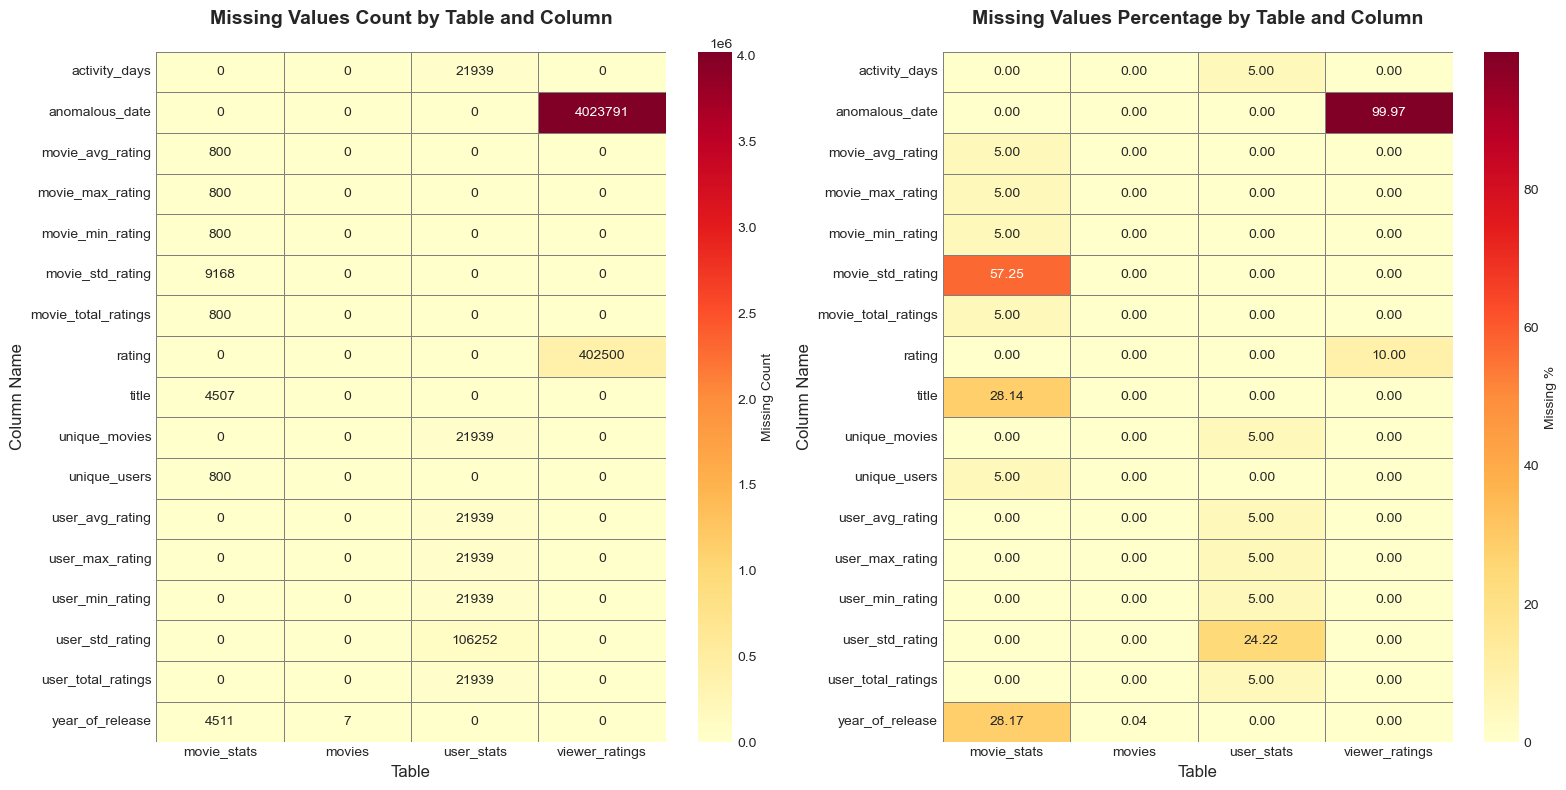

In [17]:
if len(missing_df) > 0:
    # Create informative heatmap
    # Pivot for heatmap visualization
    pivot_count = missing_df.pivot_table(
        index='Column', 
        columns='Table', 
        values='Missing Count', 
        fill_value=0
    )
    pivot_pct = missing_df.pivot_table(
        index='Column', 
        columns='Table', 
        values='Missing %', 
        fill_value=0
    )
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(pivot_count) * 0.4)))
    # Heatmap of missing values count
    sns.heatmap(pivot_count, annot=True, fmt='.0f', cmap='YlOrRd', 
                cbar_kws={'label': 'Missing Count'}, ax=axes[0], 
                linewidths=0.5, linecolor='gray')
    axes[0].set_title('Missing Values Count by Table and Column', fontsize=14, fontweight='bold', pad=20)
    axes[0].set_ylabel('Column Name', fontsize=12)
    axes[0].set_xlabel('Table', fontsize=12)
    # Heatmap of missing values percentage
    sns.heatmap(pivot_pct, annot=True, fmt='.2f', cmap='YlOrRd',
                cbar_kws={'label': 'Missing %'}, ax=axes[1],
                linewidths=0.5, linecolor='gray')
    axes[1].set_title('Missing Values Percentage by Table and Column', fontsize=14, fontweight='bold', pad=20)
    axes[1].set_ylabel('Column Name', fontsize=12)
    axes[1].set_xlabel('Table', fontsize=12)
    plt.tight_layout()
    plt.savefig('images/missing_values_heatmap.png', dpi=300, bbox_inches='tight')

We have a lot of missing values in movie_stats and viewer_ratings. 

In [18]:
# Summary by table
print("SUMMARY BY TABLE")

for table in missing_df['Table'].unique():
    table_missing = missing_df[missing_df['Table'] == table]
    total_missing = table_missing['Missing Count'].sum()
    print(f"\n{table}:")
    print(f"  Total missing values: {total_missing:,}")
    print(f"  Columns with missing values: {len(table_missing)}")
    for _, row in table_missing.iterrows():
        print(f"    - {row['Column']}: {row['Missing Count']:,} ({row['Missing %']:.2f}%)")

SUMMARY BY TABLE

viewer_ratings:
  Total missing values: 4,426,291
  Columns with missing values: 2
    - rating: 402,500 (10.00%)
    - anomalous_date: 4,023,791 (99.97%)

movies:
  Total missing values: 7
  Columns with missing values: 1
    - year_of_release: 7 (0.04%)

user_stats:
  Total missing values: 237,886
  Columns with missing values: 7
    - user_total_ratings: 21,939 (5.00%)
    - user_avg_rating: 21,939 (5.00%)
    - user_std_rating: 106,252 (24.22%)
    - user_min_rating: 21,939 (5.00%)
    - user_max_rating: 21,939 (5.00%)
    - unique_movies: 21,939 (5.00%)
    - activity_days: 21,939 (5.00%)

movie_stats:
  Total missing values: 22,186
  Columns with missing values: 8
    - movie_total_ratings: 800 (5.00%)
    - movie_avg_rating: 800 (5.00%)
    - movie_std_rating: 9,168 (57.25%)
    - movie_min_rating: 800 (5.00%)
    - movie_max_rating: 800 (5.00%)
    - unique_users: 800 (5.00%)
    - year_of_release: 4,511 (28.17%)
    - title: 4,507 (28.14%)


In [19]:
# Check unique counts
print("UNIQUE COUNTS")
print(f"Unique customers: {viewer_ratings['customer_id'].nunique()}")
print(f"Unique movies: {viewer_ratings['movie_id'].nunique()}")
print(f"Unique ratings: {viewer_ratings['rating'].nunique()}")
print(f"Rating range: {viewer_ratings['rating'].min()} - {viewer_ratings['rating'].max()}")

UNIQUE COUNTS
Unique customers: 438570
Unique movies: 16013
Unique ratings: 7
Rating range: 0.0 - 6.0


In [20]:
# Check date range
viewer_ratings['date'] = pd.to_datetime(viewer_ratings['date'], errors='coerce')
print(f"\nDate range: {viewer_ratings['date'].min()} to {viewer_ratings['date'].max()}")
print(f"Total days span: {(viewer_ratings['date'].max() - viewer_ratings['date'].min()).days} days")


Date range: 1995-01-01 00:00:00 to 2006-03-28 00:00:00
Total days span: 4104 days


# PREPROCESSING

Here I prepare clean datasets for clustering (using user_stats and movie_stats) and EDA.

**Strategy:**
- Clean viewer_ratings: Handle invalid ratings, duplicates
- Restore missing stats: Compute missing values from ratings_sorted
- Clean user_stats: Handle remaining missing values for user clustering
- Clean movie_stats: Handle remaining missing values for movie clustering
- Create final datasets: Ready-to-use features for clustering

#### 1. Clean viewer_ratings

In [21]:
viewer_ratings_all = viewer_ratings.copy()
print(f"Original viewer_ratings: {len(viewer_ratings_all):,} rows")

Original viewer_ratings: 4,025,000 rows


1.1 Convert Invalid Ratings to NaN

In [22]:
invalid_0 = (viewer_ratings['rating'] == 0).sum()
invalid_6 = (viewer_ratings['rating'] == 6).sum()
print(f"Invalid ratings (0): {invalid_0:,}")
print(f"Invalid ratings (6): {invalid_6:,}")

viewer_ratings.loc[viewer_ratings['rating'] == 0, 'rating'] = np.nan
viewer_ratings.loc[viewer_ratings['rating'] == 6, 'rating'] = np.nan
print(f"Converted invalid ratings to NaN")

Invalid ratings (0): 385
Invalid ratings (6): 376
Converted invalid ratings to NaN


1.2 Create Clean Ratings Dataset

In [23]:
viewer_ratings_clean = viewer_ratings.dropna(subset=['rating']).copy()
print(f"Clean ratings: {len(viewer_ratings_clean):,} rows")
print(f"Excluded: {len(viewer_ratings) - len(viewer_ratings_clean):,} rows")
print(f"Rating range: {viewer_ratings_clean['rating'].min():.0f} - {viewer_ratings_clean['rating'].max():.0f}")

Clean ratings: 3,621,739 rows
Excluded: 403,261 rows
Rating range: 1 - 5


1.3 Handle Duplicates

In [24]:
duplicate_count = viewer_ratings_clean.duplicated(subset=['movie_id', 'customer_id'], keep=False).sum()
print(f"Duplicate (movie_id, customer_id) pairs: {duplicate_count:,}")

if duplicate_count > 0:
    viewer_ratings_clean = viewer_ratings_clean.sort_values(['movie_id', 'customer_id', 'date'], ascending=[True, True, False])
    viewer_ratings_clean = viewer_ratings_clean.drop_duplicates(subset=['movie_id', 'customer_id'], keep='first')
    print(f"After keeping most recent: {len(viewer_ratings_clean):,} rows")

Duplicate (movie_id, customer_id) pairs: 4
After keeping most recent: 3,621,737 rows


1.4 Handle anomalous_date

In [25]:
viewer_ratings_clean['anomalous_date'] = viewer_ratings_clean['anomalous_date'].fillna(0)
print(f"Filled anomalous_date NaN with 0")
print(f"anomalous_date values: {viewer_ratings_clean['anomalous_date'].value_counts().to_dict()}")

Filled anomalous_date NaN with 0
anomalous_date values: {0.0: 3620634, 1.0: 1103}


1.5 Create ratings_sorted (Final Clean Ratings)

In [26]:
ratings_sorted = viewer_ratings_clean.copy()
print(f"ratings_sorted: {len(ratings_sorted):,} rows")
print(f"Unique users: {ratings_sorted['customer_id'].nunique():,}")
print(f"Unique movies: {ratings_sorted['movie_id'].nunique():,}")

ratings_sorted: 3,621,737 rows
Unique users: 428,452
Unique movies: 14,777


#### 2. Clean user_stats for User Clustering

2.1 Check Missing Values in user_stats

In [27]:
print("Missing values in user_stats:")
missing_user = user_stats.isnull().sum()
missing_user = missing_user[missing_user > 0]
print(missing_user)
print(f"\nTotal users: {len(user_stats):,}")
print(f"Users with any missing values: {user_stats.isnull().any(axis=1).sum():,}")

Missing values in user_stats:
user_total_ratings     21939
user_avg_rating        21939
user_std_rating       106252
user_min_rating        21939
user_max_rating        21939
unique_movies          21939
activity_days          21939
dtype: int64

Total users: 438,780
Users with any missing values: 194,509


2.2 Restore Missing user_stats from ratings_sorted

In [28]:
users_with_missing = user_stats[user_stats.isnull().any(axis=1)]['customer_id'].unique()
print(f"Users with missing stats: {len(users_with_missing):,}")

if len(users_with_missing) > 0:
    user_ratings = ratings_sorted[ratings_sorted['customer_id'].isin(users_with_missing)]
    
    if len(user_ratings) > 0:
        user_stats_computed = user_ratings.groupby('customer_id').agg({
            'rating': ['count', 'mean', 'std', 'min', 'max'],
            'movie_id': 'nunique',
            'date': ['min', 'max']
        }).reset_index()
        
        user_stats_computed.columns = ['customer_id', 'user_total_ratings', 'user_avg_rating', 
                                        'user_std_rating', 'user_min_rating', 'user_max_rating',
                                        'unique_movies', 'user_first_rating_date', 'user_last_rating_date']
        
        user_stats_computed['user_std_rating'] = user_stats_computed['user_std_rating'].fillna(0)
        user_stats_computed['activity_days'] = (pd.to_datetime(user_stats_computed['user_last_rating_date']) - 
                                                 pd.to_datetime(user_stats_computed['user_first_rating_date'])).dt.days + 1
        
        for col in user_stats_computed.columns:
            if col in user_stats.columns and col != 'customer_id':
                mask = (user_stats['customer_id'].isin(users_with_missing)) & (user_stats[col].isnull())
                user_stats.loc[mask, col] = user_stats.loc[mask, 'customer_id'].map(
                    dict(zip(user_stats_computed['customer_id'], user_stats_computed[col]))
                )
        
        print(f"Restored missing stats for {len(users_with_missing):,} users")
    else:
        print("No ratings found for users with missing stats")
    
print(f"Remaining missing values: {user_stats.isnull().sum().sum()}")

Users with missing stats: 194,509
Restored missing stats for 194,509 users
Remaining missing values: 12589


2.3 Exclude Users with Missing Critical Features

In [29]:
users_with_missing_total = user_stats['user_total_ratings'].isnull().sum()
print(f"Users with missing user_total_ratings: {users_with_missing_total:,}")

user_features = user_stats[user_stats['user_total_ratings'].notna()].copy()
print(f"Users after excluding missing total_ratings: {len(user_features):,}")
print(f"Excluded: {len(user_stats) - len(user_features):,} users")

Users with missing user_total_ratings: 499
Users after excluding missing total_ratings: 438,281
Excluded: 499 users


2.4 Handle user_std_rating (Fill with 0)

In [30]:
missing_std = user_features['user_std_rating'].isnull().sum()
print(f"Missing user_std_rating: {missing_std:,} ({100*missing_std/len(user_features):.2f}%)")

user_features['user_std_rating'] = user_features['user_std_rating'].fillna(0)
print(f"Filled user_std_rating NaN with 0 (expected for single-rating users)")

Missing user_std_rating: 9,081 (2.07%)
Filled user_std_rating NaN with 0 (expected for single-rating users)


2.5 Handle Other Missing Numeric Features

In [31]:
numeric_cols = ['user_avg_rating', 'user_min_rating', 'user_max_rating', 'unique_movies', 'activity_days']
for col in numeric_cols:
    if col in user_features.columns:
        missing = user_features[col].isnull().sum()
        if missing > 0:
            median_val = user_features[col].median()
            user_features[col] = user_features[col].fillna(median_val)
            print(f"Filled {col} NaN ({missing:,} values) with median: {median_val:.2f}")

print(f"\nRemaining missing values: {user_features.isnull().sum().sum()}")

Filled user_avg_rating NaN (524 values) with median: 3.69
Filled user_min_rating NaN (500 values) with median: 3.00
Filled user_max_rating NaN (483 values) with median: 5.00
Filled unique_movies NaN (468 values) with median: 4.00
Filled activity_days NaN (448 values) with median: 102.00

Remaining missing values: 0


2.6 Verify user_features

In [32]:
print(f"user_features shape: {user_features.shape}")
print(f"Missing values: {user_features.isnull().sum().sum()}")
print(f"Columns: {list(user_features.columns)}")

user_features shape: (438281, 10)
Missing values: 0
Columns: ['customer_id', 'user_total_ratings', 'user_avg_rating', 'user_std_rating', 'user_min_rating', 'user_max_rating', 'unique_movies', 'user_first_rating_date', 'user_last_rating_date', 'activity_days']


#### 3. Clean movie_stats for Movie Clustering

3.1 Check Missing Values in movie_stats

In [33]:
print("Missing values in movie_stats:")
missing_movie = movie_stats.isnull().sum()
missing_movie = missing_movie[missing_movie > 0]
print(missing_movie)
print(f"\nTotal movies: {len(movie_stats):,}")
print(f"Movies with any missing values: {movie_stats.isnull().any(axis=1).sum():,}")

Missing values in movie_stats:
movie_total_ratings     800
movie_avg_rating        800
movie_std_rating       9168
movie_min_rating        800
movie_max_rating        800
unique_users            800
year_of_release        4511
title                  4507
dtype: int64

Total movies: 16,015
Movies with any missing values: 12,107


3.2 Restore Missing movie_stats from ratings_sorted

In [34]:
print("Restoring missing movie_stats from ratings_sorted...")

movies_with_missing = movie_stats[movie_stats.isnull().any(axis=1)]['movie_id'].unique()
print(f"Movies with missing stats: {len(movies_with_missing):,}")

if len(movies_with_missing) > 0:
    movie_ratings = ratings_sorted[ratings_sorted['movie_id'].isin(movies_with_missing)]
    
    if len(movie_ratings) > 0:
        movie_stats_computed = movie_ratings.groupby('movie_id').agg({
            'rating': ['count', 'mean', 'std', 'min', 'max'],
            'customer_id': 'nunique'
        }).reset_index()
        
        movie_stats_computed.columns = ['movie_id', 'movie_total_ratings', 'movie_avg_rating',
                                         'movie_std_rating', 'movie_min_rating', 'movie_max_rating',
                                         'unique_users']
        
        movie_stats_computed['movie_std_rating'] = movie_stats_computed['movie_std_rating'].fillna(0)
        
        for col in movie_stats_computed.columns:
            if col in movie_stats.columns and col != 'movie_id':
                mask = (movie_stats['movie_id'].isin(movies_with_missing)) & (movie_stats[col].isnull())
                movie_stats.loc[mask, col] = movie_stats.loc[mask, 'movie_id'].map(
                    dict(zip(movie_stats_computed['movie_id'], movie_stats_computed[col]))
                )
        
        print(f"Restored missing stats for {len(movies_with_missing):,} movies")
    else:
        print("No ratings found for movies with missing stats")
    
    # Restore year_of_release from movies table using merge (handles duplicates)
    if 'year_of_release' in movie_stats.columns:
        missing_year = movie_stats[movie_stats['movie_id'].isin(movies_with_missing)]['year_of_release'].isnull().sum()
        if missing_year > 0:
            # Drop duplicates and take first value if there are duplicates
            movies_year = movies[['movie_id', 'year_of_release']].drop_duplicates(subset='movie_id', keep='first')
            year_map = dict(zip(movies_year['movie_id'], movies_year['year_of_release']))
            
            mask = (movie_stats['movie_id'].isin(movies_with_missing)) & (movie_stats['year_of_release'].isnull())
            movie_stats.loc[mask, 'year_of_release'] = movie_stats.loc[mask, 'movie_id'].map(year_map)
            print(f"Restored year_of_release from movies table for {missing_year:,} movies")
    
print(f"Remaining missing values: {movie_stats.isnull().sum().sum()}")

Restoring missing movie_stats from ratings_sorted...
Movies with missing stats: 12,105
Restored missing stats for 12,105 movies
Restored year_of_release from movies table for 4,511 movies
Remaining missing values: 10501


3.3 Exclude Movies with Missing Critical Features

In [35]:
movies_with_missing_total = movie_stats['movie_total_ratings'].isnull().sum()
print(f"Movies with missing movie_total_ratings: {movies_with_missing_total:,}")

movie_features = movie_stats[movie_stats['movie_total_ratings'].notna()].copy()
print(f"Movies after excluding missing total_ratings: {len(movie_features):,}")
print(f"Excluded: {len(movie_stats) - len(movie_features):,} movies")

Movies with missing movie_total_ratings: 53
Movies after excluding missing total_ratings: 15,962
Excluded: 53 movies


3.4 Handle movie_std_rating (Fill with 0)

In [36]:
missing_std = movie_features['movie_std_rating'].isnull().sum()
print(f"Missing movie_std_rating: {missing_std:,} ({100*missing_std/len(movie_features):.2f}%)")

movie_features['movie_std_rating'] = movie_features['movie_std_rating'].fillna(0)
print(f"Filled movie_std_rating NaN with 0 (expected for single-rating movies)")

Missing movie_std_rating: 1,124 (7.04%)
Filled movie_std_rating NaN with 0 (expected for single-rating movies)


3.5 Handle Other Missing Numeric Features

In [37]:
numeric_cols = ['movie_avg_rating', 'movie_min_rating', 'movie_max_rating', 'unique_users']
for col in numeric_cols:
    if col in movie_features.columns:
        missing = movie_features[col].isnull().sum()
        if missing > 0:
            median_val = movie_features[col].median()
            movie_features[col] = movie_features[col].fillna(median_val)
            print(f"Filled {col} NaN ({missing:,} values) with median: {median_val:.2f}")

print(f"\nRemaining missing values (before year_of_release): {movie_features.isnull().sum().sum()}")

Filled movie_avg_rating NaN (67 values) with median: 3.00
Filled movie_min_rating NaN (60 values) with median: 2.00
Filled movie_max_rating NaN (58 values) with median: 4.00
Filled unique_users NaN (64 values) with median: 1.00

Remaining missing values (before year_of_release): 8984


3.6 Handle year_of_release

In [38]:
missing_year = movie_features['year_of_release'].isnull().sum()
print(f"Missing year_of_release: {missing_year:,} ({100*missing_year/len(movie_features):.2f}%)")

if missing_year > 0:
    # Calculate median from non-null values
    median_year = movie_features['year_of_release'].median()
    print(f"Median year_of_release (for imputation): {median_year:.0f}")
    
    # Actually impute the missing values
    movie_features['year_of_release'].fillna(median_year, inplace=True)
    
    # Verify imputation
    remaining_missing = movie_features['year_of_release'].isnull().sum()
    print(f"After imputation: {remaining_missing:,} missing values remaining")

Missing year_of_release: 4,494 (28.15%)
Median year_of_release (for imputation): 1997
After imputation: 0 missing values remaining


3.7 Handle title (Not needed for clustering)

In [39]:
if 'title' in movie_features.columns:
    missing_title = movie_features['title'].isnull().sum()
    print(f"Missing title: {missing_title:,} (not needed for clustering, keeping for EDA)")

Missing title: 4,490 (not needed for clustering, keeping for EDA)


3.8 Verify movie_features

In [40]:
print(f"movie_features shape: {movie_features.shape}")
print(f"Missing values: {movie_features.isnull().sum().sum()}")
print(f"Columns: {list(movie_features.columns)}")

movie_features shape: (15962, 11)
Missing values: 4490
Columns: ['movie_id', 'movie_total_ratings', 'movie_avg_rating', 'movie_std_rating', 'movie_min_rating', 'movie_max_rating', 'unique_users', 'movie_first_rating_date', 'movie_last_rating_date', 'year_of_release', 'title']


#### 4.Create EDA Dataset 

4.1 Merge ratings with movies for EDA

In [41]:
ratings_with_movies = ratings_sorted.merge(movies, on='movie_id', how='left')

print(f"Before dropping missing year_of_release: {len(ratings_with_movies):,} rows")
print(f"Movies with missing year_of_release: {ratings_with_movies['year_of_release'].isnull().sum():,} rows")

ratings_with_movies = ratings_with_movies[ratings_with_movies['year_of_release'].notna()].copy()

print(f"After dropping missing year_of_release: {len(ratings_with_movies):,} rows")
print(f"Excluded: {ratings_sorted.shape[0] - len(ratings_with_movies):,} rows")
print(f"\n✓ ratings_with_movies ready for EDA (all rows have year_of_release)")
print(f"Note: movie_features (for clustering) has imputed values, but EDA uses original movies table")

Before dropping missing year_of_release: 3,621,740 rows
Movies with missing year_of_release: 6,336 rows
After dropping missing year_of_release: 3,615,404 rows
Excluded: 6,333 rows

✓ ratings_with_movies ready for EDA (all rows have year_of_release)
Note: movie_features (for clustering) has imputed values, but EDA uses original movies table


#### 5. Final Summary

In [42]:

print("PREPROCESSING SUMMARY")


print(f"\n1. viewer_ratings_all: {len(viewer_ratings_all):,} rows (original data)")
print(f"2. ratings_sorted: {len(ratings_sorted):,} rows (clean ratings for recommendations)")
print(f"3. ratings_with_movies: {len(ratings_with_movies):,} rows (for EDA with movie metadata)")

print(f"\n4. user_features: {len(user_features):,} users (ready for clustering)")
print(f"   Missing values: {user_features.isnull().sum().sum()}")

print(f"\n5. movie_features: {len(movie_features):,} movies (ready for clustering)")
print(f"   Missing values: {movie_features.isnull().sum().sum()}")

PREPROCESSING SUMMARY

1. viewer_ratings_all: 4,025,000 rows (original data)
2. ratings_sorted: 3,621,737 rows (clean ratings for recommendations)
3. ratings_with_movies: 3,615,404 rows (for EDA with movie metadata)

4. user_features: 438,281 users (ready for clustering)
   Missing values: 0

5. movie_features: 15,962 movies (ready for clustering)
   Missing values: 4490


# EDA


**Data Source**: `ratings_with_movies` (ratings merged with movie metadata)


## 1. Overall Rating Distribution
---

**Question**: What is the overall rating distribution on the platform?

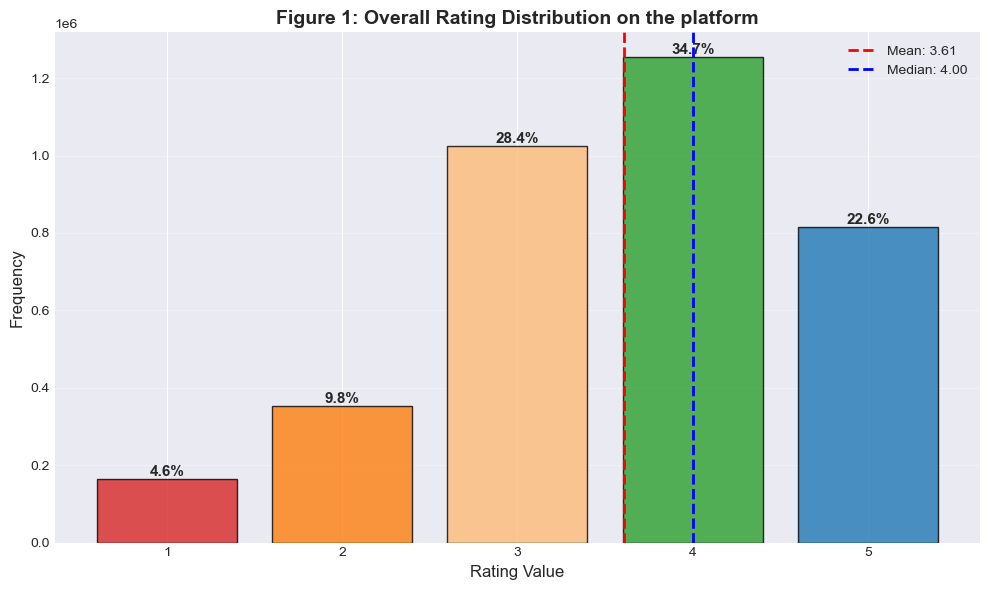

In [43]:
# 5.1.1 Overall Rating Distribution

import matplotlib.pyplot as plt
import seaborn as sns

rating_counts = ratings_with_movies['rating'].value_counts().sort_index()
total_ratings = len(ratings_with_movies)

for rating, count in rating_counts.items():
    pct = 100 * count / total_ratings

mean_rating = ratings_with_movies['rating'].mean()
median_rating = ratings_with_movies['rating'].median()

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

colors_ratings = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c', '#1f77b4']
bars = ax.bar(rating_counts.index, rating_counts.values, alpha=0.8, edgecolor='black', color=colors_ratings)
ax.set_title('Figure 1: Overall Rating Distribution on the platform', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xticks(rating_counts.index)
ax.grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (rating, count) in enumerate(rating_counts.items()):
    pct = 100 * count / total_ratings
    ax.text(rating, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add mean and median lines
ax.axvline(mean_rating, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_rating:.2f}')
ax.axvline(median_rating, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_rating:.2f}')
ax.legend()

plt.tight_layout()
plt.savefig('images/eda_5_1_1_rating_distribution.png', dpi=300, bbox_inches='tight')


**Figure 1**: Most ratings (34.7%) are 4 stars. Rating 3 is second most popular, more popular than 5. Ratings 2 and 1 are least popular.

**What it says about CONTENT:**

| Observation | Interpretation |
|-------------|----------------|
| Few 1–2 star ratings | Content quality is decent |
| Few 5-star ratings | Content is not exceptional |
| Most ratings are 3–4 stars | Users find content satisfactory but not outstanding |

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Prefer middle ratings (3–4) over extremes | Users are moderate raters |
| Few 1–2 star ratings | Users are not very critical |
| Few 5-star ratings | Users are not overly enthusiastic |
| Moderate rating distribution | Users are likely average (not niche) |

## 2. User Analysis (Foundation)

---

#### 2.1 User Activity Segmentation

In [44]:
# Use user_features instead of recomputing from ratings_with_movies
customer_stats = user_features.copy()

# Rename columns to match expected names
customer_stats = customer_stats.rename(columns={
    'user_total_ratings': 'total_ratings',
    'user_avg_rating': 'avg_rating_given',
    'user_std_rating': 'rating_std',
    'user_first_rating_date': 'first_rating_date',
    'user_last_rating_date': 'last_rating_date'
})

# Ensure dates are datetime (they should already be, but double-check)
customer_stats['first_rating_date'] = pd.to_datetime(customer_stats['first_rating_date'])
customer_stats['last_rating_date'] = pd.to_datetime(customer_stats['last_rating_date'])

if 'activity_days' in customer_stats.columns:
    pass
else:
    # Compute if somehow missing
    customer_stats['activity_days'] = (customer_stats['last_rating_date'] - 
                                      customer_stats['first_rating_date']).dt.days + 1

# Segment users by activity level
customer_stats['activity_level'] = pd.cut(customer_stats['total_ratings'],
                                         bins=[0, 10, 50, 200, float('inf')],
                                         labels=['Low (1-10)', 'Medium (11-50)', 'High (51-200)', 'Very High (200+)'])

activity_dist = customer_stats['activity_level'].value_counts().sort_index()
for level, count in activity_dist.items():
    pct = 100 * count / len(customer_stats)
  

In [45]:
# Data preparation for visualizations
# Check for missing values
if customer_stats['avg_rating_given'].isnull().sum() > 0:
    print(f"Warning: {customer_stats['avg_rating_given'].isnull().sum()} missing avg_rating_given values")
    # Handle missing values if needed (shouldn't happen if user_features is clean)
    customer_stats = customer_stats[customer_stats['avg_rating_given'].notna()].copy()

activity_ratings = customer_stats.groupby('activity_level')['avg_rating_given'].apply(list)
activity_colors = ['#aec7e8', '#98df8a', '#ffbb78', '#ff9896']

avg_by_activity = customer_stats.groupby('activity_level')['avg_rating_given'].agg(['mean', 'std', 'count'])
avg_by_activity['ci'] = 1.96 * avg_by_activity['std'] / np.sqrt(avg_by_activity['count'])  # 95% confidence interval

activity_dist = customer_stats['activity_level'].value_counts()


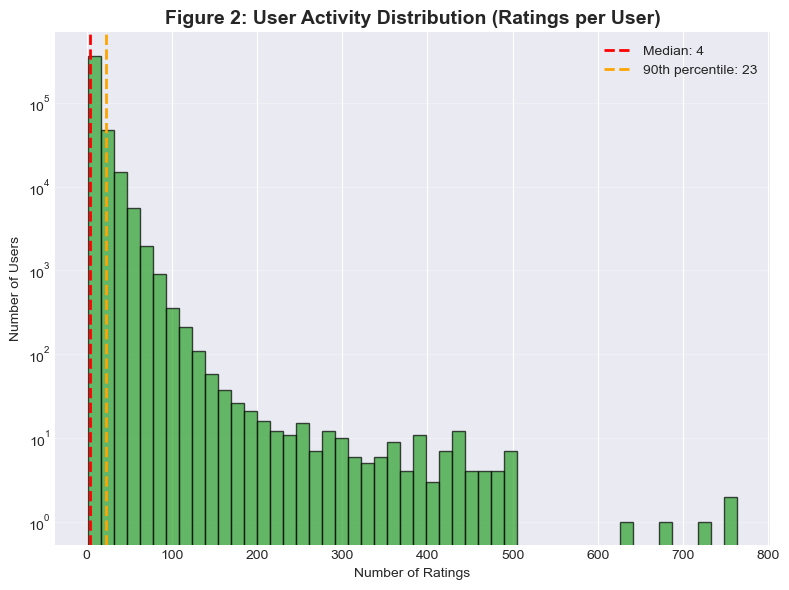

In [46]:
# Figure 2: User Activity Distribution (Histogram)
plt.figure(figsize=(8, 6))
plt.hist(customer_stats['total_ratings'], bins=50, edgecolor='black', alpha=0.7, color='#2ca02c')
plt.title('Figure 2: User Activity Distribution (Ratings per User)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')

# Adding percentiles
p25 = customer_stats['total_ratings'].quantile(0.25)
p50 = customer_stats['total_ratings'].quantile(0.50)
p75 = customer_stats['total_ratings'].quantile(0.75)
p90 = customer_stats['total_ratings'].quantile(0.90)

plt.axvline(p50, color='r', linestyle='--', linewidth=2, label=f'Median: {p50:.0f}')
plt.axvline(p90, color='orange', linestyle='--', linewidth=2, label=f'90th percentile: {p90:.0f}')
plt.legend()

plt.tight_layout()
plt.savefig('images/figure_2_user_activity_distribution.png', dpi=300, bbox_inches='tight')


**Figure 2**

Distribution of how many ratings each user has given.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Strong long-tail distribution — most users have very few ratings (likely 1–5), while a small percentage have many | Most users are casual/occasional raters, not power users |
| Small group of active users generates most rating activity | The platform relies heavily on a small group of active users for most of the rating activity |


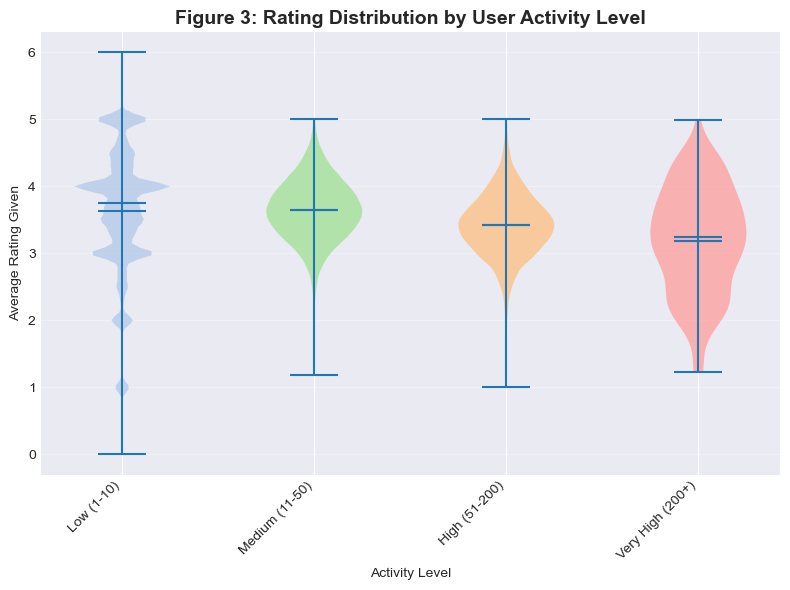

In [47]:
# Figure 3: Rating Distribution by User Activity Level (Violin Plot)
plt.figure(figsize=(8, 6))
violin_parts = plt.violinplot([activity_ratings[level] for level in activity_ratings.index], 
                             positions=range(len(activity_ratings)), showmeans=True, showmedians=True)

# Coloring the sections
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(activity_colors[i])
    pc.set_alpha(0.7)

plt.xticks(range(len(activity_ratings)), activity_ratings.index, rotation=45, ha='right')
plt.title('Figure 3: Rating Distribution by User Activity Level', fontsize=14, fontweight='bold')
plt.xlabel('Activity Level')
plt.ylabel('Average Rating Given')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/figure_3_rating_distribution.png', dpi=300, bbox_inches='tight')


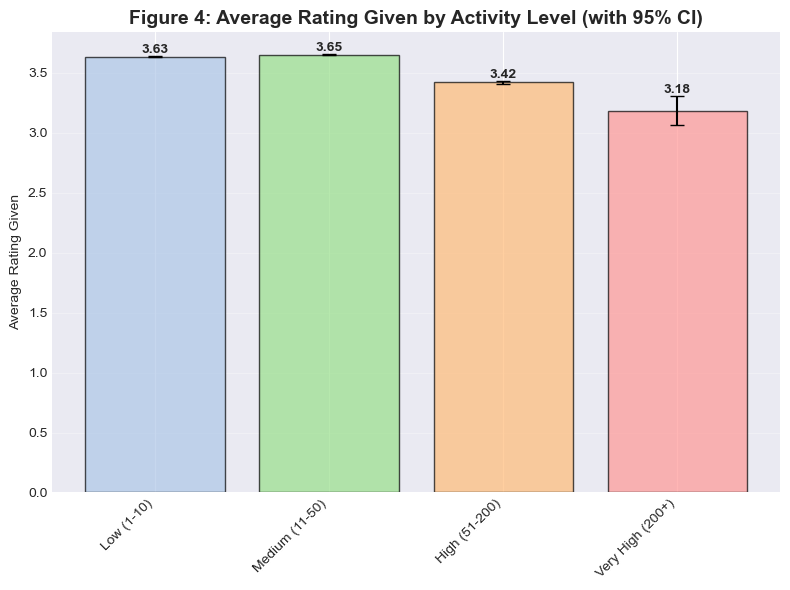

In [48]:
# Figure 4: Average Rating Given by Activity Level (Bar Chart with Error Bars)
plt.figure(figsize=(8, 6))
plt.bar(range(len(avg_by_activity)), avg_by_activity['mean'], 
        alpha=0.7, edgecolor='black', color=activity_colors, 
        yerr=avg_by_activity['ci'], capsize=5)

plt.xticks(range(len(avg_by_activity)), avg_by_activity.index, rotation=45, ha='right')
plt.title('Figure 4: Average Rating Given by Activity Level (with 95% CI)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Average Rating Given')
plt.grid(True, alpha=0.3, axis='y')

# Adding mean values to the chart
for i, (idx, row) in enumerate(avg_by_activity.iterrows()):
    plt.text(i, row['mean'] + row['ci'], f"{row['mean']:.2f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('images/figure_4_avg_rating_by_activity.png', dpi=300, bbox_inches='tight')


**Figure 3 and Figure 4**


Shows how the distribution of ratings (1–5) differs across activity levels (Low, Medium, High, Very High).

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| More active users tend to rate content lower | In general, there is a tendency: the more active, the lower he/she rates content |
| Active users show different rating patterns than inactive users | Active users may rate differently than inactive users — they might be more critical (lower average) or more generous |
| Active users give more extreme ratings (more 1s and 5s) | Active users are more opinionated |
| Active users give more middle ratings | Active users are more balanced/thoughtful |


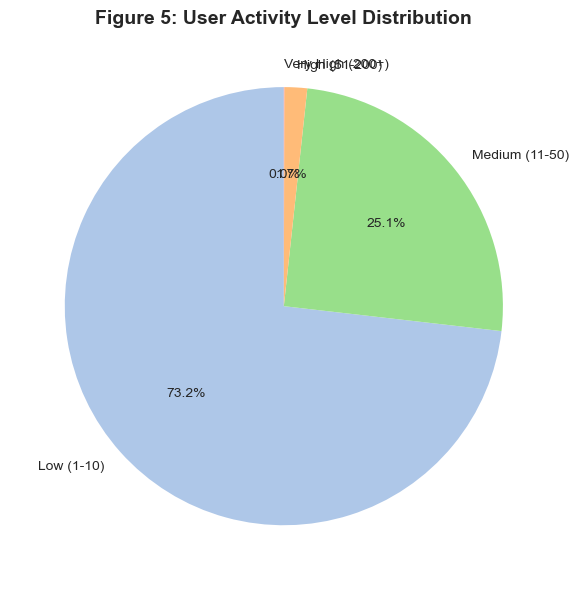

In [49]:
# Figure 5: User Activity Level Distribution (Pie Chart)
plt.figure(figsize=(8, 6))
plt.pie(activity_dist.values, labels=activity_dist.index, autopct='%1.1f%%', 
        colors=activity_colors, startangle=90)
plt.title('Figure 5: User Activity Level Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/figure_5_activity_level_distribution.png', dpi=300, bbox_inches='tight')


**Figure 5**


**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Most users (73%) have only a few ratings (1-10) | The platform has many casual users |
| 25% of users have 11-50 ratings | Moderate activity segment |
| Only a few users are highly active | The platform has few power users |

#### 2.2 User Behavior Patterns

**Questions**:
1. How consistent are users in their ratings? (Can we predict their preferences?)
2. What are the different user rating behavior segments? (Harsh vs lenient raters)
3. Do power users give more extreme ratings? (1s and 5s)

In [50]:
# Rating Consistency and User Behavior Patterns

extreme_ratings = ratings_with_movies.groupby('customer_id').apply(
    lambda x: ((x['rating'] == 1).sum() + (x['rating'] == 5).sum()) / len(x) if len(x) > 0 else 0
).reset_index()
extreme_ratings.columns = ['customer_id', 'extreme_pct']
customer_stats = customer_stats.merge(extreme_ratings, on='customer_id', how='left')

# Segment users by rating behavior
customer_stats['rating_behavior'] = pd.cut(customer_stats['avg_rating_given'],
                                           bins=[0, 2.5, 3.5, 4.5, 5.1],
                                           labels=['Harsh (<2.5)', 'Moderate (2.5-3.5)', 'Positive (3.5-4.5)', 'Lenient (>4.5)'])

behavior_dist = customer_stats['rating_behavior'].value_counts().sort_index()
for behavior, count in behavior_dist.items():
    pct = 100 * count / len(customer_stats)


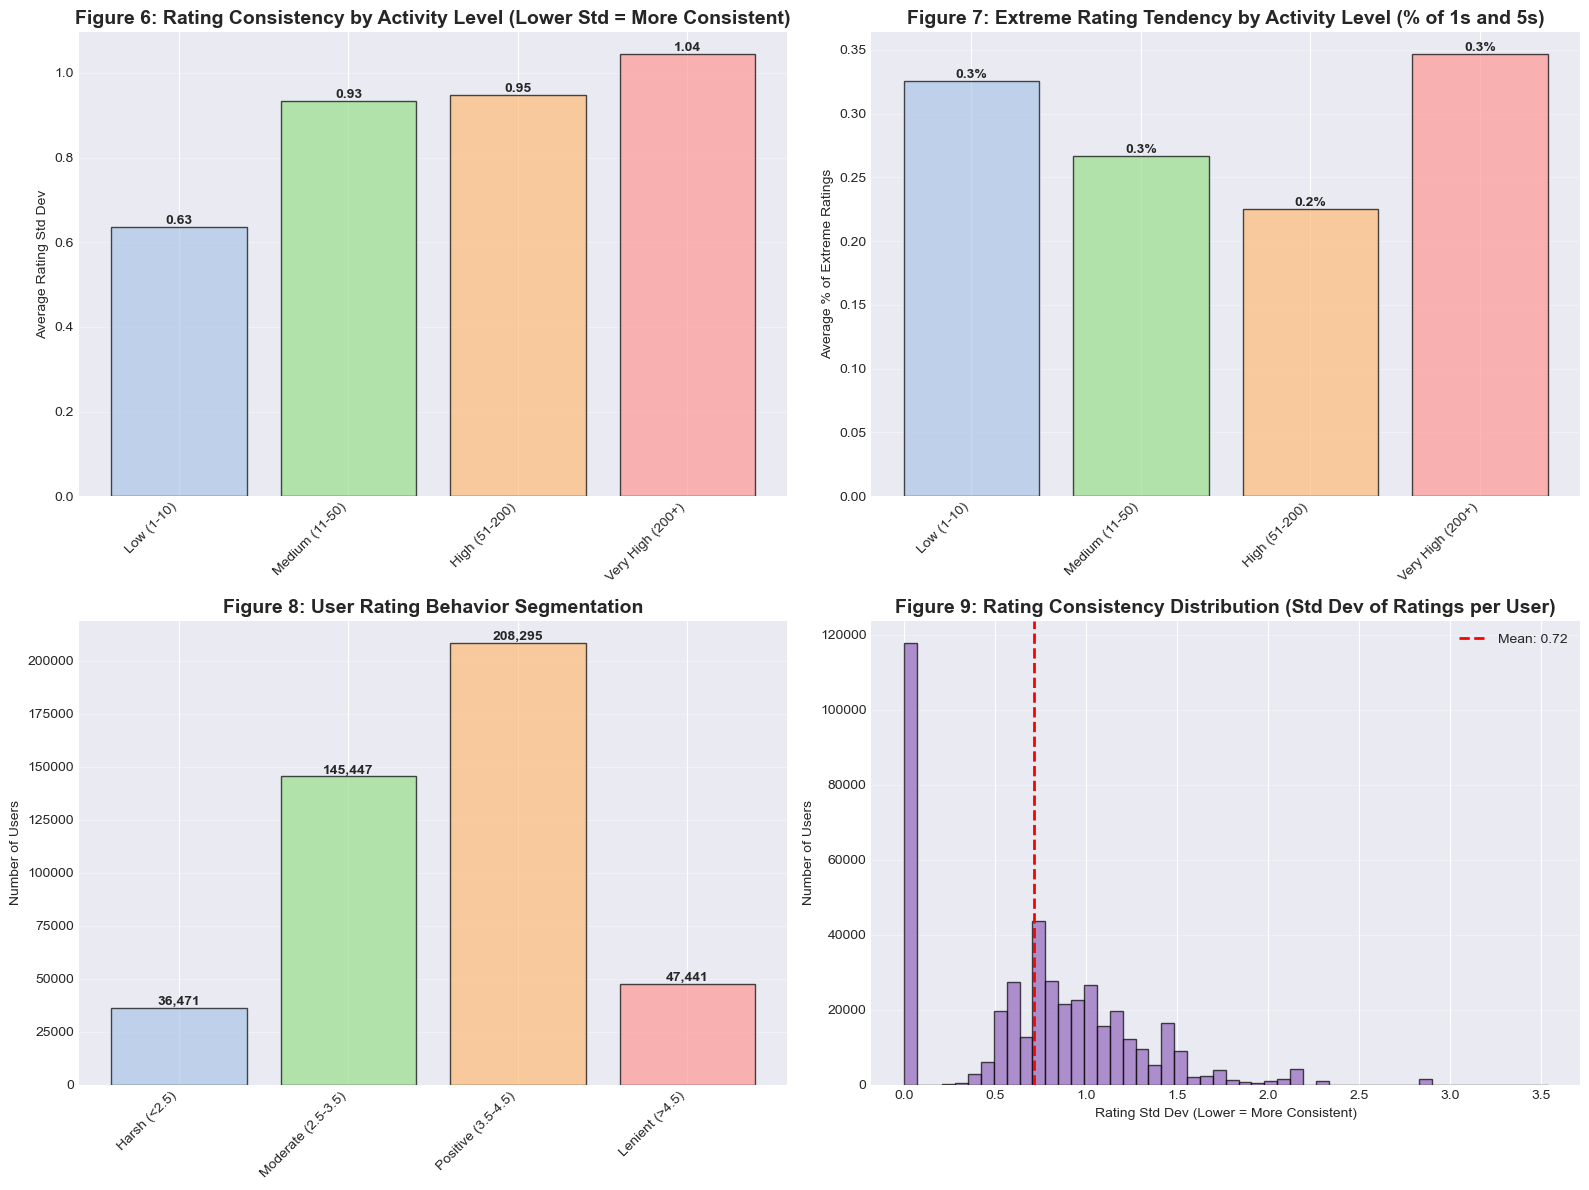

In [51]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating Consistency by Activity Level
consistency_by_activity = customer_stats.groupby('activity_level')['rating_std'].mean()
axes[0, 0].bar(range(len(consistency_by_activity)), consistency_by_activity.values, 
               alpha=0.7, edgecolor='black', color=activity_colors)
axes[0, 0].set_xticks(range(len(consistency_by_activity)))
axes[0, 0].set_xticklabels(consistency_by_activity.index, rotation=45, ha='right')
axes[0, 0].set_title('Figure 6: Rating Consistency by Activity Level (Lower Std = More Consistent)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Average Rating Std Dev')
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(consistency_by_activity.values):
    axes[0, 0].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Extreme Rating Tendency by Activity Level
extreme_by_activity = customer_stats.groupby('activity_level')['extreme_pct'].mean()
axes[0, 1].bar(range(len(extreme_by_activity)), extreme_by_activity.values, 
               alpha=0.7, edgecolor='black', color=activity_colors)
axes[0, 1].set_xticks(range(len(extreme_by_activity)))
axes[0, 1].set_xticklabels(extreme_by_activity.index, rotation=45, ha='right')
axes[0, 1].set_title('Figure 7: Extreme Rating Tendency by Activity Level (% of 1s and 5s)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average % of Extreme Ratings')
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(extreme_by_activity.values):
    axes[0, 1].text(i, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Rating Behavior Segmentation
axes[1, 0].bar(range(len(behavior_dist)), behavior_dist.values, 
               alpha=0.7, edgecolor='black', color=activity_colors)
axes[1, 0].set_xticks(range(len(behavior_dist)))
axes[1, 0].set_xticklabels(behavior_dist.index, rotation=45, ha='right')
axes[1, 0].set_title('Figure 8: User Rating Behavior Segmentation', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Number of Users')
axes[1, 0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(behavior_dist.values):
    axes[1, 0].text(i, val, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Rating Consistency Distribution
axes[1, 1].hist(customer_stats['rating_std'].fillna(0), bins=50, edgecolor='black', alpha=0.7, color='#9467bd')
axes[1, 1].set_title('Figure 9: Rating Consistency Distribution (Std Dev of Ratings per User)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Rating Std Dev (Lower = More Consistent)')
axes[1, 1].set_ylabel('Number of Users')
axes[1, 1].axvline(customer_stats['rating_std'].mean(), color='r', linestyle='--', linewidth=2, 
                   label=f'Mean: {customer_stats["rating_std"].mean():.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/eda_5_1_3_rating_consistency.png', dpi=300, bbox_inches='tight')
# Figures 6-9
# Figures 6-9


**Figure 6**

Standard deviation of ratings (lower = more consistent) by activity level.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Users who left only a few ratings are more consistent in preferences | They could use The Platform to watch only movies of one category (e.g. only Harry Potter movies or only fantasy movies) |
| The most active users prefer more diverse content, as well as medium and high active users | The Platform users, if they decide to stay on the platform and keep watching and rating, start exploring different movies but after a certain time they probably find balance between diversity and preferences |


**Figure 7**

Percentage of 1-star and 5-star ratings by activity level.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Active users give more extreme ratings | Active users are more opinionated/confident |
| Inactive users also give a lot of extreme ratings | Inactive users may be less thoughtful or more emotional |



**Figure 8**

Graph shows the distribution of users across 4 categories based on their average rating.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Most users fall in the moderate rating range | Most users are generally satisfied but not overly enthusiastic |



**Figure 9**

Histogram showing the distribution of rating consistency across all users.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Majority of users have very low standard deviation (close to 0) | The majority of users are consistent in their ratings, indicating that they tend to give similar scores across different items |
| Higher Std Dev values are relatively rare | Inconsistent rating patterns (higher Std Dev values) are relatively rare |

## 3. User Analysis (Advanced)
---

**Questions**:
1. How do users' rating patterns evolve over time? (Do they become more/less critical?)
2. Do users rate more movies as they become more active? (Engagement growth)
3. Are there power users who drive most of the ratings? (80/20 rule for users)
4. How do users discover new content? (Rating patterns over time)
5. Do users have rating preferences that change over time? (Temporal preferences)

#### 3.1 User Rating Evolution Over Time

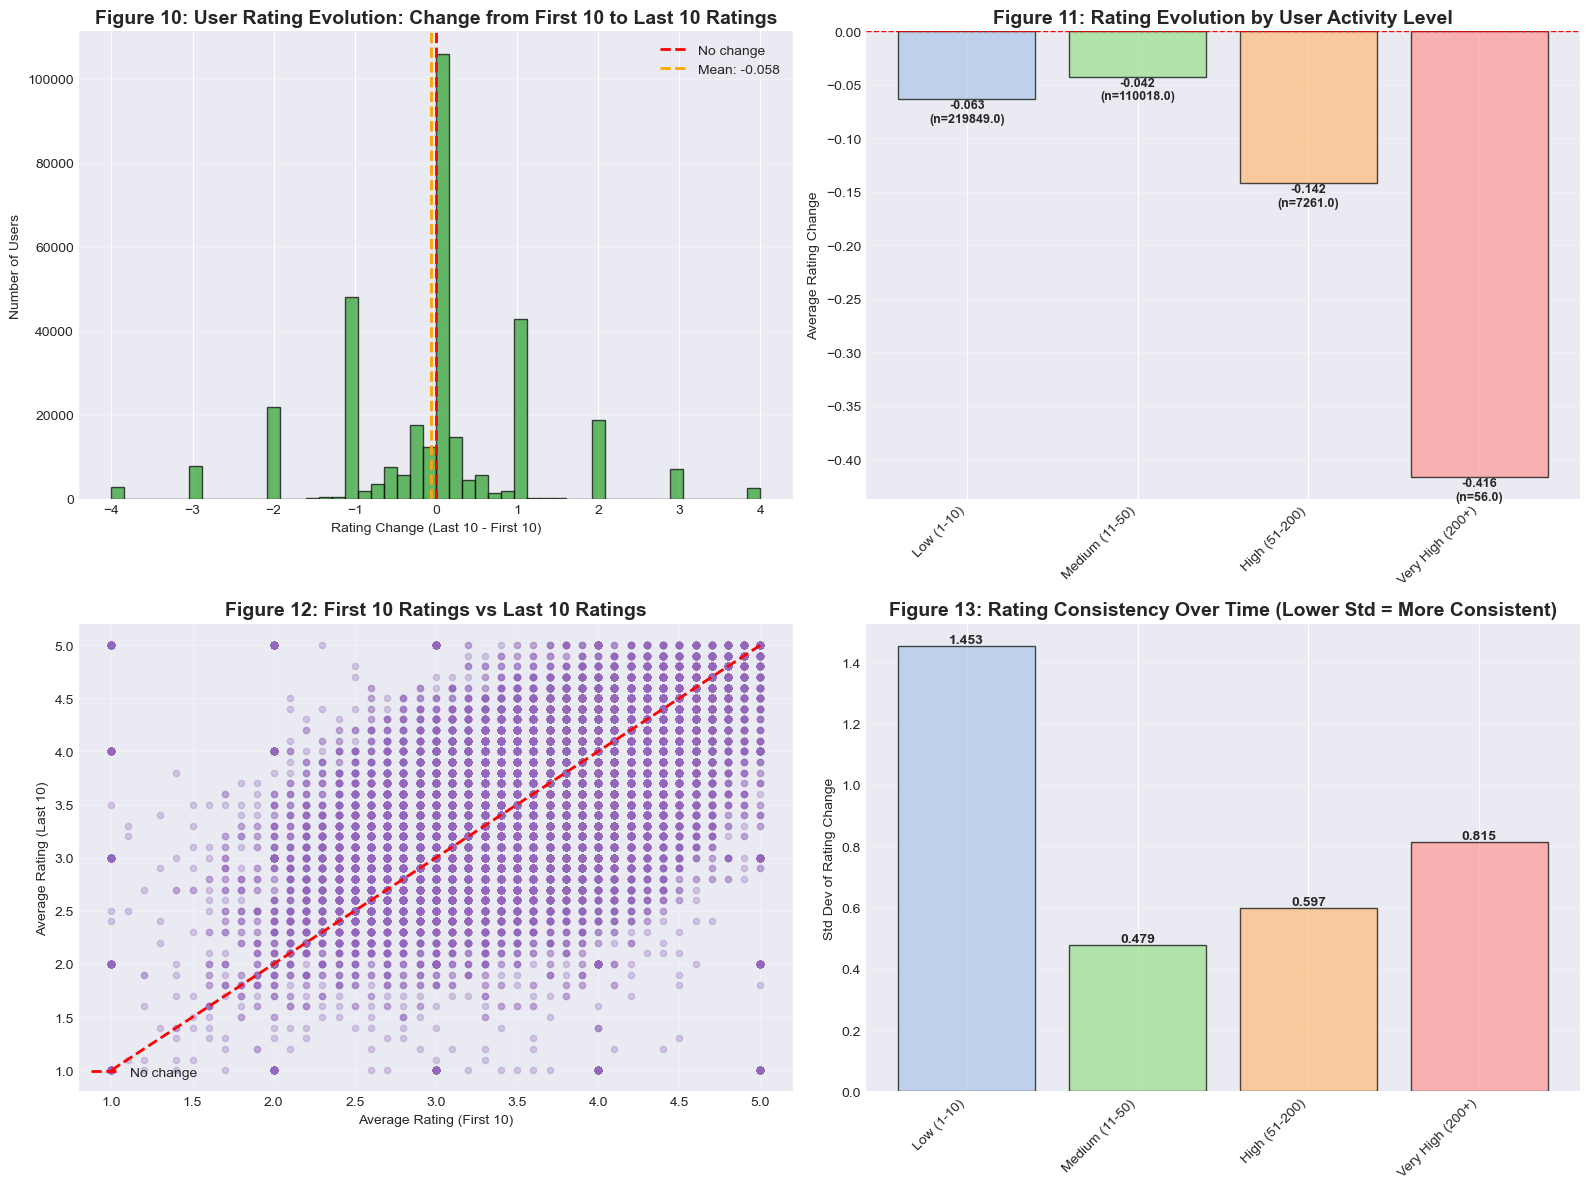

In [52]:
# User Rating Evolution Over Time
user_ratings_sorted = ratings_with_movies.sort_values(['customer_id', 'date']).copy()

def calculate_user_evolution(group):
    """Calculate evolution metrics for a single user (vectorized)"""
    n_ratings = len(group)
    if n_ratings < 2:
        return None
    
    if n_ratings >= 10:
        first_10_avg = group.head(10)['rating'].mean()
        last_10_avg = group.tail(10)['rating'].mean()
        
        # Split into thirds
        third_size = n_ratings // 3
        first_third_avg = group.head(third_size)['rating'].mean()
        last_third_avg = group.tail(third_size)['rating'].mean()
        
        return pd.Series({
            'first_10_avg': first_10_avg,
            'last_10_avg': last_10_avg,
            'first_third_avg': first_third_avg,
            'last_third_avg': last_third_avg,
            'rating_change': last_10_avg - first_10_avg,
            'rating_change_third': last_third_avg - first_third_avg,
        })
    else:
        # For users with <10 ratings, use first and last
        first_avg = group.head(1)['rating'].values[0]
        last_avg = group.tail(1)['rating'].values[0]
        
        return pd.Series({
            'first_10_avg': first_avg,
            'last_10_avg': last_avg,
            'first_third_avg': first_avg,
            'last_third_avg': last_avg,
            'rating_change': last_avg - first_avg,
            'rating_change_third': last_avg - first_avg,
        })

# Compute evolution metrics from raw data (these don't exist in stats tables)
user_evolution_metrics = user_ratings_sorted.groupby('customer_id').apply(
    calculate_user_evolution, 
    include_groups=False
).reset_index()

# Get total_ratings and days_active from user_features (avoid recomputation)
user_base_stats = user_features[['customer_id', 'user_total_ratings', 'activity_days']].copy()
user_base_stats = user_base_stats.rename(columns={
    'user_total_ratings': 'total_ratings'
})

# Merge evolution metrics with base stats
user_evolution_df = user_evolution_metrics.merge(user_base_stats, on='customer_id', how='inner')

# Drop rows where evolution calculation failed (users with <2 ratings)
user_evolution_df = user_evolution_df.dropna(subset=['first_10_avg'])

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating Change Distribution
axes[0, 0].hist(user_evolution_df['rating_change'], bins=50, edgecolor='black', alpha=0.7, color='#2ca02c')
axes[0, 0].axvline(0, color='r', linestyle='--', linewidth=2, label='No change')
axes[0, 0].axvline(user_evolution_df['rating_change'].mean(), color='orange', linestyle='--', linewidth=2, 
                   label=f'Mean: {user_evolution_df["rating_change"].mean():.3f}')
axes[0, 0].set_title('Figure 10: User Rating Evolution: Change from First 10 to Last 10 Ratings', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Rating Change (Last 10 - First 10)')
axes[0, 0].set_ylabel('Number of Users')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Rating Change by User Activity Level
user_evolution_df['activity_level'] = pd.cut(user_evolution_df['total_ratings'],
                                               bins=[0, 10, 50, 200, float('inf')],
                                               labels=['Low (1-10)', 'Medium (11-50)', 'High (51-200)', 'Very High (200+)'])
change_by_activity = user_evolution_df.groupby('activity_level')['rating_change'].agg(['mean', 'count'])
bars = axes[0, 1].bar(range(len(change_by_activity)), change_by_activity['mean'], 
                      alpha=0.7, edgecolor='black', color=['#aec7e8', '#98df8a', '#ffbb78', '#ff9896'])
axes[0, 1].set_xticks(range(len(change_by_activity)))
axes[0, 1].set_xticklabels(change_by_activity.index, rotation=45, ha='right')
axes[0, 1].set_title('Figure 11: Rating Evolution by User Activity Level', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average Rating Change')
axes[0, 1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, (idx, row) in enumerate(change_by_activity.iterrows()):
    axes[0, 1].text(i, row['mean'], f"{row['mean']:.3f}\n(n={row['count']})", 
                    ha='center', va='bottom' if row['mean'] >= 0 else 'top', fontsize=9, fontweight='bold')

# 3. First vs Last Rating Comparison (Scatter)
axes[1, 0].scatter(user_evolution_df['first_10_avg'], user_evolution_df['last_10_avg'], 
                  alpha=0.3, s=20, color='#9467bd')
# Add diagonal line (no change)
min_rating = min(user_evolution_df['first_10_avg'].min(), user_evolution_df['last_10_avg'].min())
max_rating = max(user_evolution_df['first_10_avg'].max(), user_evolution_df['last_10_avg'].max())
axes[1, 0].plot([min_rating, max_rating], [min_rating, max_rating], 'r--', linewidth=2, label='No change')
axes[1, 0].set_title('Figure 12: First 10 Ratings vs Last 10 Ratings', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Rating (First 10)')
axes[1, 0].set_ylabel('Average Rating (Last 10)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Rating Consistency Over Time (by activity level)
consistency_by_activity = user_evolution_df.groupby('activity_level')['rating_change'].std()
axes[1, 1].bar(range(len(consistency_by_activity)), consistency_by_activity.values, 
               alpha=0.7, edgecolor='black', color=['#aec7e8', '#98df8a', '#ffbb78', '#ff9896'])
axes[1, 1].set_xticks(range(len(consistency_by_activity)))
axes[1, 1].set_xticklabels(consistency_by_activity.index, rotation=45, ha='right')
axes[1, 1].set_title('Figure 13: Rating Consistency Over Time (Lower Std = More Consistent)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Std Dev of Rating Change')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(consistency_by_activity.values):
    axes[1, 1].text(i, val, f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('images/eda_5_3_1_rating_evolution.png', dpi=300, bbox_inches='tight')


**Figure 10**

This graph shows the distribution of rating changes (calculated as "Last 10 ratings – First 10 ratings") for users, indicating how user opinions evolve over time.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| On average, users' ratings remain stable over time | There's no significant shift in their overall sentiment |
| Peak at "0" (no change) | Most users maintain consistent rating patterns — their initial impressions largely align with their later ones |
| A few users show significant changes (both positive and negative), but these are outliers | Dramatic shifts in opinion are rare |
| Symmetry around the "0" mark | Balanced evolution — as many users slightly increase their ratings as those who decrease them |

**Figure 11**

This graph compares the average rating change (Last 10 – First 10) across different user activity levels (number of ratings).

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Low-activity users (1–10 ratings) show very small change | They haven't formed strong evolving opinions |
| As users gain experience, their ratings tend to decrease | Reflecting growing sophistication |
| High-volume raters act as "quality filters" | Their opinions may be more reliable due to broader exposure |

**Figure 12**

This scatter plot compares the average of first 10 ratings with the average of last 10 ratings for each user, with a trend line showing the relationship.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Positive trend line (close to 45-degree angle) | Users who started with high ratings tend to end with high ratings, and vice versa |
| Moderate correlation between initial and final rating patterns | Early behaviour predicts later behaviour |
| Some scatter around the line shows individual variability | Not all users follow the trend perfectly |
| Users with very high initial ratings (4.5–5.0) tend to slightly reduce their ratings over time | Aligning with the "becoming more critical" pattern seen in the previous graph |
| Initial rating patterns are somewhat predictive of long-term behaviour | There's a natural "calibration" process — users adjust their standards over time |

**Figure 13**

This graph measures consistency in rating evolution (lower standard deviation = more consistent change) across user activity levels.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Novice users show more variability | Novice users need time to develop a stable rating system |
| Moderately active users show best consistency | Moderately active users strike the best balance between experience and consistency |
| Highly active users have refined standards but show some variability | Highly active users have refined standards but may encounter more diverse content, leading to varied ratings |
| Consistency develops with experience | Consistency is a sign of developed criteria: the more a user rates, the more their patterns stabilize — until a certain threshold where diversity of content introduces new variability |


#### 3.2 User Engagement Patterns

**Questions**:
1. Are there power users who drive most of the ratings? (80/20 rule for users)
2. How is user engagement distributed? (Long-tail vs power users)
3. Do engaged users rate differently? (Quality vs quantity)
4. What percentage of users are highly engaged? (Retention opportunity)

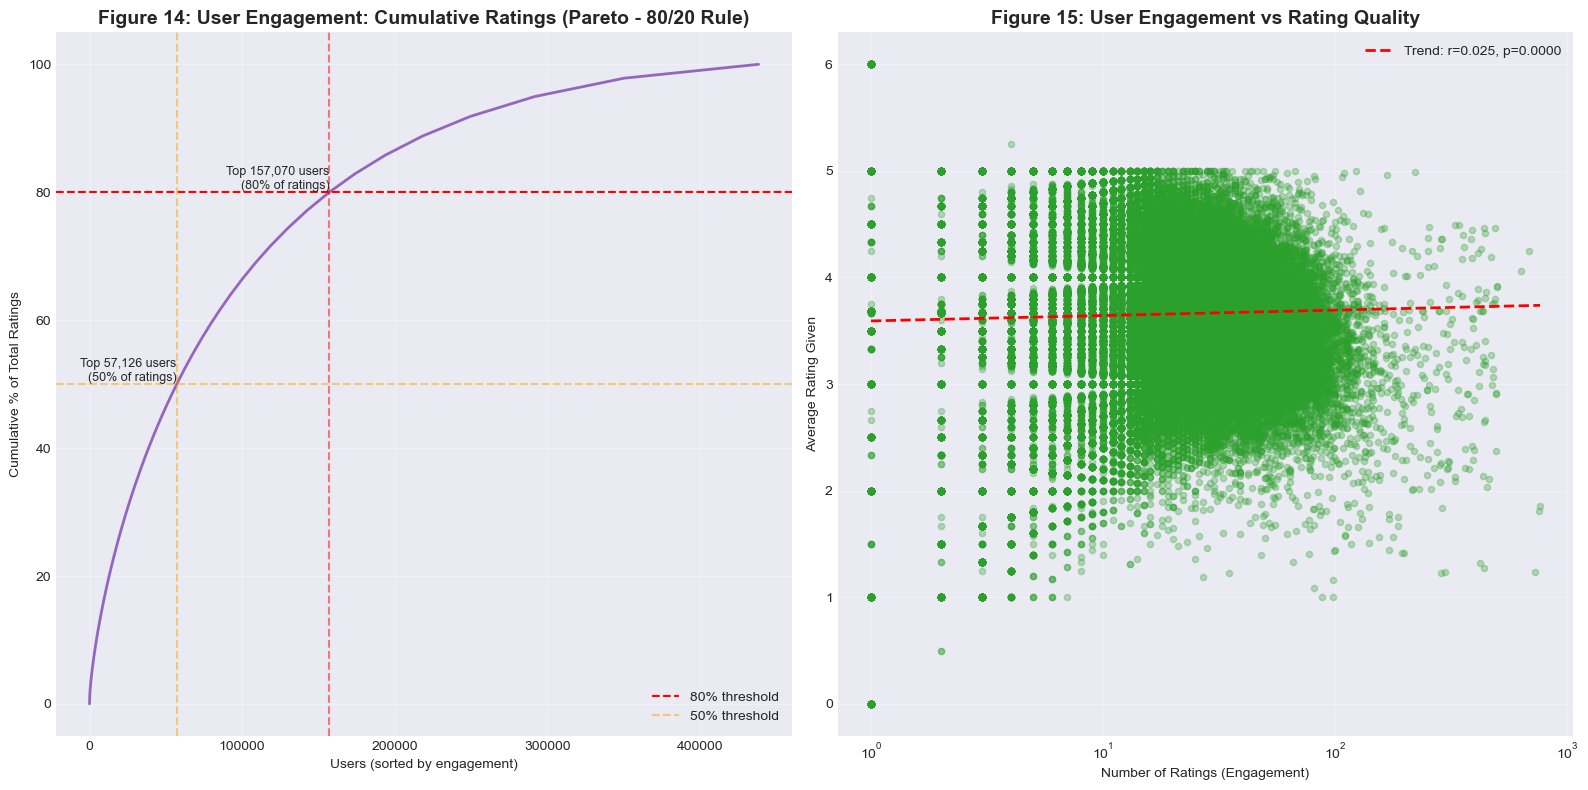

In [53]:
# User Engagement Patterns
user_engagement = user_features.copy()

# Rename columns to match expected names
user_engagement = user_engagement.rename(columns={
    'user_total_ratings': 'total_ratings',
    'user_avg_rating': 'avg_rating',
    'user_std_rating': 'rating_std',
    'user_first_rating_date': 'first_rating_date',
    'user_last_rating_date': 'last_rating_date'
})

# Ensure dates are datetime
user_engagement['first_rating_date'] = pd.to_datetime(user_engagement['first_rating_date'])
user_engagement['last_rating_date'] = pd.to_datetime(user_engagement['last_rating_date'])

# Compute ratings_per_day from existing stats
user_engagement['ratings_per_day'] = user_engagement['total_ratings'] / user_engagement['activity_days'].clip(lower=1)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. User Engagement: Cumulative Ratings (Pareto - 80/20 Rule)
sorted_users = user_engagement.sort_values('total_ratings', ascending=False)
sorted_users['cumulative_pct'] = 100 * sorted_users['total_ratings'].cumsum() / sorted_users['total_ratings'].sum()
axes[0].plot(range(len(sorted_users)), sorted_users['cumulative_pct'], linewidth=2, color='#9467bd')
axes[0].axhline(80, color='r', linestyle='--', label='80% threshold')
axes[0].axhline(50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
p80_idx = (sorted_users['cumulative_pct'] <= 80).sum()
p50_idx = (sorted_users['cumulative_pct'] <= 50).sum()
axes[0].axvline(p80_idx, color='r', linestyle='--', alpha=0.5)
axes[0].axvline(p50_idx, color='orange', linestyle='--', alpha=0.5)
axes[0].set_title('Figure 14: User Engagement: Cumulative Ratings (Pareto - 80/20 Rule)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Users (sorted by engagement)')
axes[0].set_ylabel('Cumulative % of Total Ratings')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].text(p80_idx, 80, f'Top {p80_idx:,} users\n(80% of ratings)', ha='right', va='bottom', fontsize=9)
axes[0].text(p50_idx, 50, f'Top {p50_idx:,} users\n(50% of ratings)', ha='right', va='bottom', fontsize=9)

# 2. Engagement vs Rating Quality (Scatter)
axes[1].scatter(user_engagement['total_ratings'], user_engagement['avg_rating'], 
                  alpha=0.3, s=20, color='#2ca02c')
axes[1].set_title('Figure 15: User Engagement vs Rating Quality', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Ratings (Engagement)')
axes[1].set_ylabel('Average Rating Given')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
# Add trend line
from scipy import stats
mask = ~(user_engagement['total_ratings'].isna() | user_engagement['avg_rating'].isna())
if mask.sum() > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        np.log(user_engagement.loc[mask, 'total_ratings'] + 1), 
        user_engagement.loc[mask, 'avg_rating']
    )
    x_trend = np.logspace(0, np.log10(user_engagement['total_ratings'].max()), 100)
    y_trend = slope * np.log(x_trend) + intercept
    axes[1].plot(x_trend, y_trend, 'r--', linewidth=2, 
                   label=f'Trend: r={r_value:.3f}, p={p_value:.4f}')
    axes[1].legend()

plt.tight_layout()
plt.savefig('images/eda_5_3_2_engagement_patterns.png', dpi=300, bbox_inches='tight')


**Figure 14**

What the graph shows: What percentage of users generate 80% of all ratings.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| 80% of ratings come from around 157,000 out of 400,000 users | The majority of ratings come from a relatively small proportion of users |
| The curve shows first users make the largest contribution | The curve shows that the first users make the largest contribution, and as the number of users grows, the increase in their cumulative contribution slows down |
| First 57,952 users (14% of total) generate half of all ratings | Core of active users: this is the "core" of the platform — the most engaged users. The platform should motivate them to stay active |

**Audience Segmentation:**

| Group | Users | Characteristics |
|-------|-------|----------------|
| Core | Top 57,952 | Highest activity |
| Active periphery | 57,952–157,401 | Significant but lower contribution |
| Passive users | Over 157,401 | Low engagement level |



**Figure 15**

Scatter plot showing if more engaged users give higher or lower average ratings.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Near-zero correlation (r = 0.020) between engagement and rating quality | How many ratings a user gives does not influence the quality (value) of those ratings. Highly active users are just as likely to give low or high ratings as less active ones |
| User engagement (quantity) and rating quality (average value) are essentially unrelated | The Platform cannot rely on user activity level to predict rating reliability or "quality" |


## 4. Content Analysis

---

#### 4.1 Movie Popularity and Long-Tail Distribution

**Questions**:
1. What is the popularity distribution of movies? (Long-tail vs blockbusters?)
2. Are there 'hidden gems' - movies with high ratings but low popularity?
3. Does the platform follow the 80/20 rule? (Top 20% of movies get 80% of ratings?)

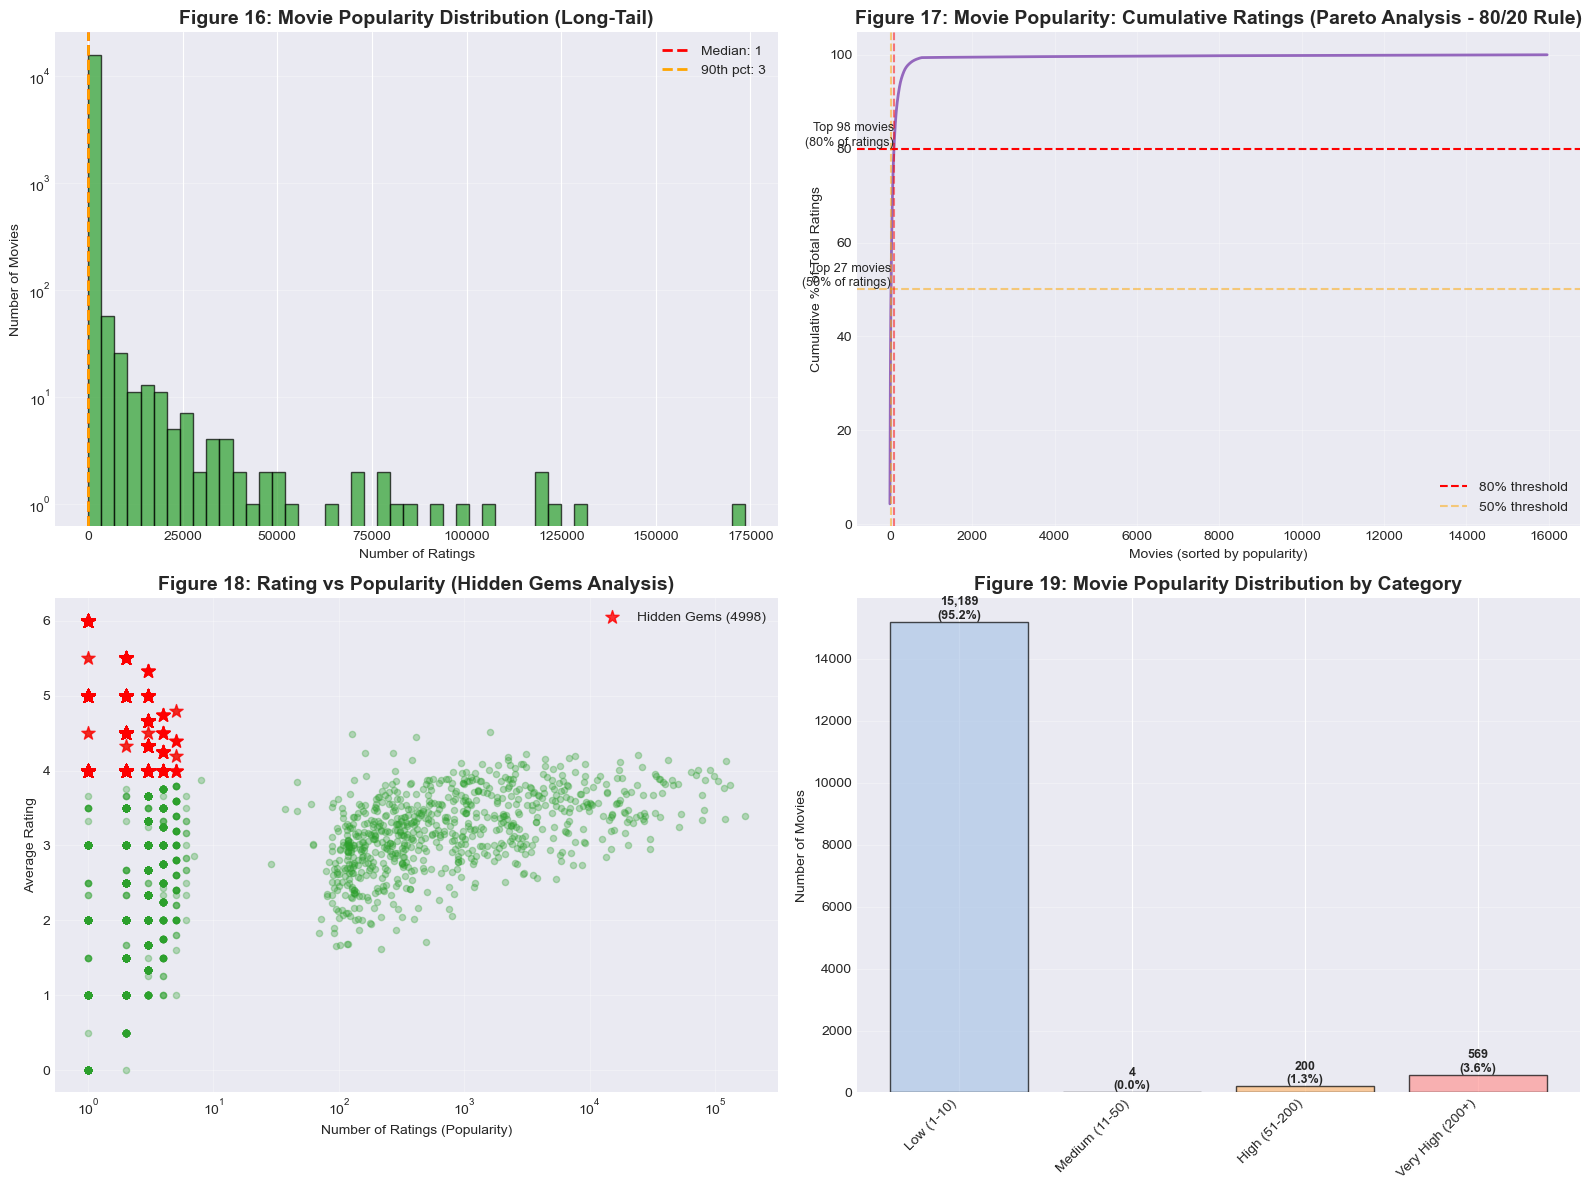

In [54]:
# Movie Popularity and Long-Tail Distribution
movie_stats = movie_features.copy()

# Rename columns to match expected names
movie_stats = movie_stats.rename(columns={
    'movie_total_ratings': 'total_ratings',
    'movie_avg_rating': 'avg_rating',
    'movie_std_rating': 'rating_std',
    'movie_min_rating': 'min_rating',
    'movie_max_rating': 'max_rating',
    'movie_first_rating_date': 'first_rating_date',
    'movie_last_rating_date': 'last_rating_date'
})

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Movie Popularity Distribution (Long-Tail)
axes[0, 0].hist(movie_stats['total_ratings'], bins=50, edgecolor='black', alpha=0.7, color='#2ca02c')
axes[0, 0].set_title('Figure 16: Movie Popularity Distribution (Long-Tail)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Ratings')
axes[0, 0].set_ylabel('Number of Movies')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Add percentiles
p50 = movie_stats['total_ratings'].quantile(0.50)
p90 = movie_stats['total_ratings'].quantile(0.90)
axes[0, 0].axvline(p50, color='r', linestyle='--', linewidth=2, label=f'Median: {p50:.0f}')
axes[0, 0].axvline(p90, color='orange', linestyle='--', linewidth=2, label=f'90th pct: {p90:.0f}')
axes[0, 0].legend()

sorted_movies = movie_stats.sort_values('total_ratings', ascending=False)
sorted_movies['cumulative_pct'] = 100 * sorted_movies['total_ratings'].cumsum() / sorted_movies['total_ratings'].sum()
axes[0, 1].plot(range(len(sorted_movies)), sorted_movies['cumulative_pct'], linewidth=2, color='#9467bd')
axes[0, 1].axhline(80, color='r', linestyle='--', label='80% threshold')
axes[0, 1].axhline(50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
p80_idx = (sorted_movies['cumulative_pct'] <= 80).sum()
p50_idx = (sorted_movies['cumulative_pct'] <= 50).sum()
axes[0, 1].axvline(p80_idx, color='r', linestyle='--', alpha=0.5)
axes[0, 1].axvline(p50_idx, color='orange', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Movies (sorted by popularity)')
axes[0, 1].set_ylabel('Cumulative % of Total Ratings')
axes[0, 1].set_title('Figure 17: Movie Popularity: Cumulative Ratings (Pareto Analysis - 80/20 Rule)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].text(p80_idx, 80, f'Top {p80_idx} movies\n(80% of ratings)', ha='right', va='bottom', fontsize=9)
axes[0, 1].text(p50_idx, 50, f'Top {p50_idx} movies\n(50% of ratings)', ha='right', va='bottom', fontsize=9)

# 3. Rating vs Popularity (Scatter Plot - Hidden Gems)
axes[1, 0].scatter(movie_stats['total_ratings'], movie_stats['avg_rating'], 
                  alpha=0.3, s=20, color='#2ca02c')
axes[1, 0].set_xlabel('Number of Ratings (Popularity)')
axes[1, 0].set_ylabel('Average Rating')
axes[1, 0].set_title('Figure 18: Rating vs Popularity (Hidden Gems Analysis)', fontsize=14, fontweight='bold')
axes[1, 0].set_xscale('log')
axes[1, 0].grid(True, alpha=0.3)
# Identify hidden gems (high rating, low popularity)
hidden_gems = movie_stats[(movie_stats['avg_rating'] >= 4.0) & (movie_stats['total_ratings'] <= 50)]
if len(hidden_gems) > 0:
    axes[1, 0].scatter(hidden_gems['total_ratings'], hidden_gems['avg_rating'], 
                      alpha=0.8, s=100, color='red', marker='*', label=f'Hidden Gems ({len(hidden_gems)})')
    axes[1, 0].legend()

# 4. Popularity Distribution (Bar Chart by Category)
popularity_categories = pd.cut(movie_stats['total_ratings'],
                               bins=[0, 10, 50, 200, float('inf')],
                               labels=['Low (1-10)', 'Medium (11-50)', 'High (51-200)', 'Very High (200+)'])
pop_counts = popularity_categories.value_counts().sort_index()
colors_pop = ['#aec7e8', '#98df8a', '#ffbb78', '#ff9896']
axes[1, 1].bar(range(len(pop_counts)), pop_counts.values, alpha=0.7, edgecolor='black', color=colors_pop)
axes[1, 1].set_xticks(range(len(pop_counts)))
axes[1, 1].set_xticklabels(pop_counts.index, rotation=45, ha='right')
axes[1, 1].set_title('Figure 19: Movie Popularity Distribution by Category', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Number of Movies')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(pop_counts.values):
    pct = 100 * val / len(movie_stats)
    axes[1, 1].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')


plt.tight_layout()
plt.savefig('images/eda_5_2_1_movie_popularity.png', dpi=300, bbox_inches='tight')

**Figure 16**

Distribution of how many ratings each movie has received.

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| Strong long-tail — most movies have very few ratings, while a small percentage are very popular | Most content is niche, few items are blockbusters |
| Diverse catalog with many less-known movies | The platform has a diverse catalog with many less-known movies |

**Figure 17**

Line plot showing cumulative percentage of total ratings. The curve shows how many top movies (by popularity) generate what percentage of all ratings. Tests whether the 80/20 rule applies.

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| Movie ratings are highly skewed. A handful of blockbuster or cult movies dominate user engagement | 80/20 Rule in Action: The data perfectly illustrates the Pareto Principle: 20% of movies (98 out of ~14,000) drive 80% of the ratings |
| Top 98 movies (vital few) drive majority of ratings | Platforms can allocate marketing, curation, and data analysis resources more efficiently by focusing on the "vital few" (top 98 movies) |
| Remaining 80% of movies have 20% of ratings | The remaining 80% of movies (with 20% of ratings) can still be monetized through niche targeting or personalized recommendations |

**Figure 18**

Scatter plot with popularity (number of ratings) on x-axis (log scale) and average rating on y-axis. Red stars mark "hidden gems" - movies with high ratings (≥4.0) but low popularity (≤50 ratings).

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| Negative correlation trend: As popularity increases, average ratings tend to decrease | This is a classic "long-tail" phenomenon |
| Head (high popularity): Lower average satisfaction | Mass appeal but lower average satisfaction |
| Tail (low popularity): Higher average satisfaction | Niche appeal with higher average satisfaction |
| Hidden gems exist (high ratings ≥4.0, low popularity ≤50 ratings) | The Platform should prioritize "hidden gems" to diversify user experiences and surface underrated items |
| Hidden gems have low popularity despite high ratings | Content creators should analyze why hidden gems have low popularity despite high ratings (e.g., poor discoverability, niche audience) |

**Figure 19**

Bar chart showing how many movies fall into each popularity category: Low (1-10 ratings), Medium (11-50), High (51-200), Very High (200+ ratings). Shows percentages for each category.

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| Most movies (94.8%) have 1-10 ratings | Strong long-tail, most content is niche |

#### 4.2 Content Freshness and Release Strategy

**Questions**:
1. How does movie age (years since release) affect ratings? (Content freshness effect)
2. Do newer movies get better ratings than older movies?
3. Is there an optimal movie age for ratings? (Sweet spot)

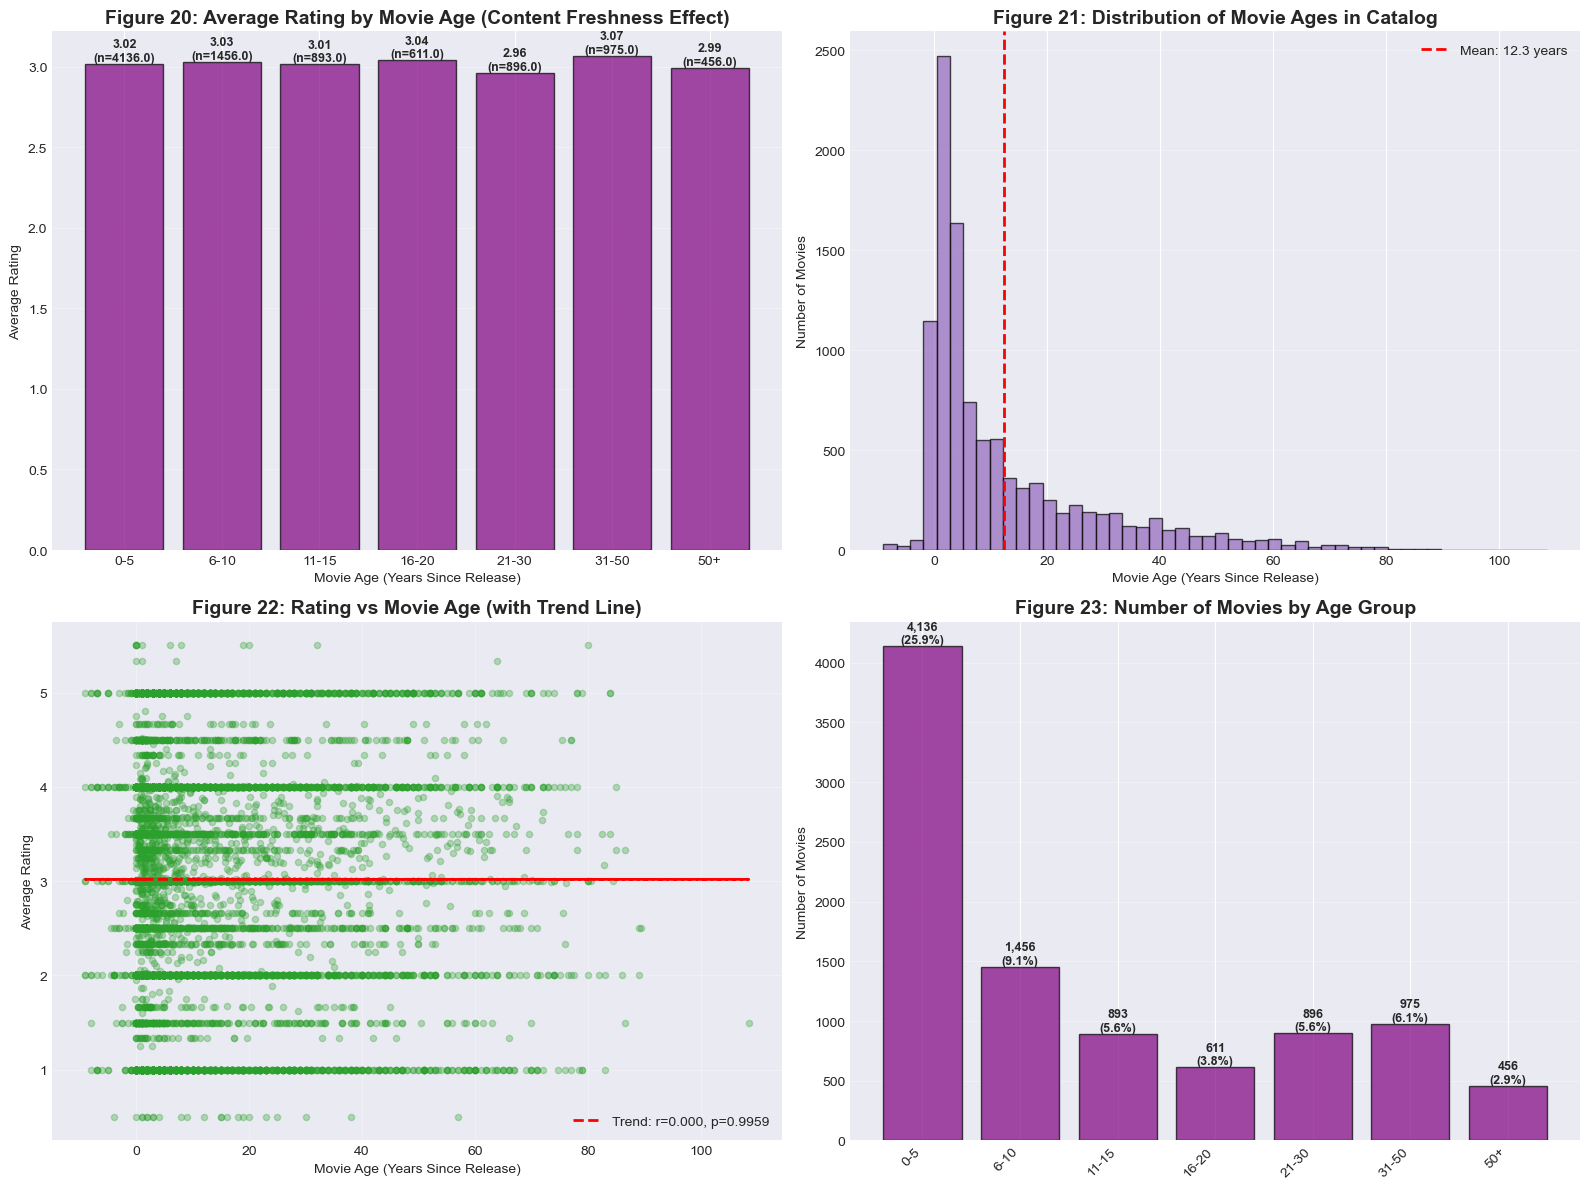

In [55]:
#Content Freshness and Release Strategy

ratings_with_movies['movie_age'] = ratings_with_movies['date'].dt.year - ratings_with_movies['year_of_release']

movie_age_avg = ratings_with_movies.groupby('movie_id')['movie_age'].mean().reset_index()
movie_age_avg.columns = ['movie_id', 'avg_movie_age']
movie_stats = movie_stats.merge(movie_age_avg, on='movie_id', how='left')


# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating by Movie Age (Content Freshness Effect)
movie_stats['age_group'] = pd.cut(movie_stats['avg_movie_age'], 
                                  bins=[0, 5, 10, 15, 20, 30, 50, 100],
                                  labels=['0-5', '6-10', '11-15', '16-20', '21-30', '31-50', '50+'])
age_rating = movie_stats.groupby('age_group')['avg_rating'].agg(['mean', 'count'])
bars = axes[0, 0].bar(range(len(age_rating)), age_rating['mean'], alpha=0.7, edgecolor='black', color='purple')
axes[0, 0].set_xticks(range(len(age_rating)))
axes[0, 0].set_xticklabels(age_rating.index)
axes[0, 0].set_title('Figure 20: Average Rating by Movie Age (Content Freshness Effect)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Movie Age (Years Since Release)')
axes[0, 0].set_ylabel('Average Rating')
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, (idx, row) in enumerate(age_rating.iterrows()):
    axes[0, 0].text(i, row['mean'], f"{row['mean']:.2f}\n(n={row['count']})", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Movie Age Distribution
axes[0, 1].hist(movie_stats['avg_movie_age'], bins=50, edgecolor='black', alpha=0.7, color='#9467bd')
axes[0, 1].set_title('Figure 21: Distribution of Movie Ages in Catalog', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Movie Age (Years Since Release)')
axes[0, 1].set_ylabel('Number of Movies')
axes[0, 1].axvline(movie_stats['avg_movie_age'].mean(), color='r', linestyle='--', linewidth=2, 
                   label=f'Mean: {movie_stats["avg_movie_age"].mean():.1f} years')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Rating vs Movie Age (Scatter with Trend)
axes[1, 0].scatter(movie_stats['avg_movie_age'], movie_stats['avg_rating'], 
                  alpha=0.3, s=20, color='#2ca02c')
# Add trend line
from scipy import stats
mask = ~(movie_stats['avg_movie_age'].isna() | movie_stats['avg_rating'].isna())
if mask.sum() > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        movie_stats.loc[mask, 'avg_movie_age'], 
        movie_stats.loc[mask, 'avg_rating']
    )
    x_trend = movie_stats.loc[mask, 'avg_movie_age']
    y_trend = slope * x_trend + intercept
    axes[1, 0].plot(x_trend, y_trend, 'r--', linewidth=2, 
                   label=f'Trend: r={r_value:.3f}, p={p_value:.4f}')
    axes[1, 0].legend()
axes[1, 0].set_title('Figure 22: Rating vs Movie Age (with Trend Line)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Movie Age (Years Since Release)')
axes[1, 0].set_ylabel('Average Rating')
axes[1, 0].grid(True, alpha=0.3)

# 4. Movie Count by Age Group
age_counts = movie_stats['age_group'].value_counts().sort_index()
axes[1, 1].bar(range(len(age_counts)), age_counts.values, alpha=0.7, edgecolor='black', color='purple')
axes[1, 1].set_xticks(range(len(age_counts)))
axes[1, 1].set_xticklabels(age_counts.index, rotation=45, ha='right')
axes[1, 1].set_title('Figure 23: Number of Movies by Age Group', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Number of Movies')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(age_counts.values):
    pct = 100 * val / len(movie_stats)
    axes[1, 1].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('images/eda_5_2_2_content_freshness.png', dpi=300, bbox_inches='tight')

**Figure 20**

How average ratings vary by movie release year.

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| No clear trend | Movie age doesn't strongly affect rating |

**Figure 21**

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| Majority of movies are recent releases | The majority of movies is new |

**Figure 22**

The relationship between a movie's average rating (on a scale from 1.0 to 5.0) and its age (number of years since release, ranging from 0 to 100+ years).

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| No correlation between movie age and rating (r ≈ –0.005, p-value = 0.5986, exceeds 0.05 threshold) | Statistical analysis and visual representation confirm that the age of a film does not influence its user ratings |
| Age is not a factor in rating quality | When recommending films, age should not be a consideration |



#### 4.3 Movie Rating Patterns

**Questions**:
1. Do popular movies get better or worse ratings? (Popularity vs quality)
2. Which movies are controversial? (High rating variance - love/hate)
3. How consistent are movie ratings? (Can we predict movie quality?)
4. Do popular movies have more consistent ratings? (Lower variance?)

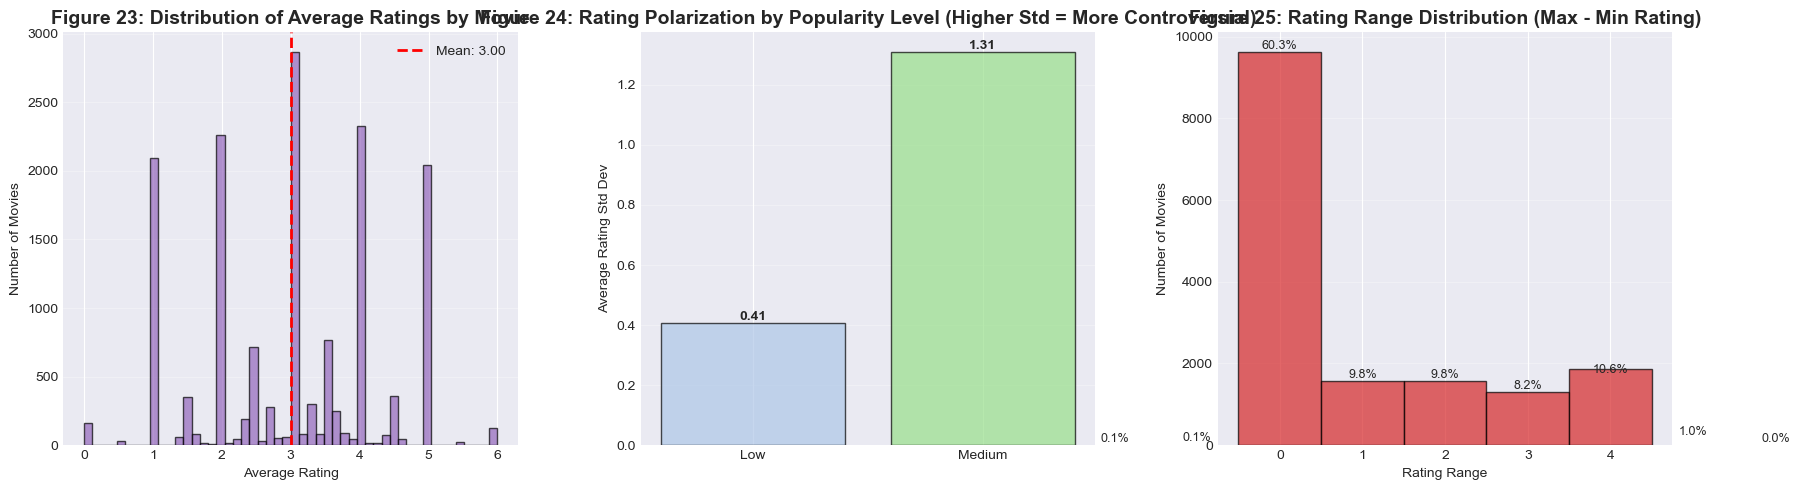

In [56]:
# Movie Rating Patterns
movie_stats['rating_range'] = movie_stats['max_rating'] - movie_stats['min_rating']
movie_stats['rating_polarization'] = movie_stats['rating_std']  # Higher std = more polarized
movie_stats['rating_consistency'] = 1 / (movie_stats['rating_std'].fillna(0) + 0.1)

# Segment movies by popularity (using quantiles with duplicate handling)
quantiles = movie_stats['total_ratings'].quantile([0, 0.25, 0.5, 0.75, 1.0])
quantiles_unique = sorted(list(set(quantiles)))
if len(quantiles_unique) >= 2:
    n_bins = len(quantiles_unique) - 1
    all_labels = ['Low', 'Medium', 'High', 'Very High']
    labels = all_labels[:n_bins] if n_bins <= 4 else all_labels + ['Extra'] * (n_bins - 4)
    movie_stats['popularity_level'] = pd.cut(movie_stats['total_ratings'], bins=quantiles_unique, 
                                                      labels=labels, include_lowest=True, duplicates='drop')
else:
    movie_stats['popularity_level'] = pd.cut(movie_stats['total_ratings'], 
                                                      bins=[0, 10, 50, 200, float('inf')], 
                                                      labels=['Low', 'Medium', 'High', 'Very High'])


# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Average Rating Distribution by Movie
axes[0].hist(movie_stats['avg_rating'], bins=50, edgecolor='black', alpha=0.7, color='#9467bd')
axes[0].set_title('Figure 23: Distribution of Average Ratings by Movie', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(movie_stats['avg_rating'].mean(), color='r', linestyle='--', linewidth=2, 
                   label=f'Mean: {movie_stats["avg_rating"].mean():.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Rating Polarization by Popularity Level
polarization_by_pop = movie_stats.groupby('popularity_level')['rating_std'].mean()
axes[1].bar(range(len(polarization_by_pop)), polarization_by_pop.values, 
               alpha=0.7, edgecolor='black', color=['#aec7e8', '#98df8a', '#ffbb78', '#ff9896'])
axes[1].set_xticks(range(len(polarization_by_pop)))
axes[1].set_xticklabels(polarization_by_pop.index)
axes[1].set_title('Figure 24: Rating Polarization by Popularity Level (Higher Std = More Controversial)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Rating Std Dev')
axes[1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(polarization_by_pop.values):
    axes[1].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Rating Range Distribution (Controversial Movies)
axes[2].hist(movie_stats['rating_range'], bins=range(0, 6), edgecolor='black',
                alpha=0.7, color='#d62728', align='left')
axes[2].set_title('Figure 25: Rating Range Distribution (Max - Min Rating)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rating Range')
axes[2].set_ylabel('Number of Movies')
axes[2].set_xticks(range(5))
axes[2].grid(True, alpha=0.3, axis='y')
# Add percentage labels
range_counts = movie_stats['rating_range'].value_counts().sort_index()
for i, (range_val, count) in enumerate(range_counts.items()):
    pct = 100 * count / len(movie_stats)
    axes[2].text(range_val, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('images/eda_5_2_3_rating_patterns.png', dpi=300, bbox_inches='tight')

**Figure 23**

This graph shows the distribution of average ratings assigned to movies (on a scale from 1.0 to 5.0), revealing how many movies fall into each rating range.

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| Average rating centers around 3.0 (marked with red dotted line) | The majority of movies are perceived as "average" or "satisfactory" by viewers |

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Rating distribution centers around 3.0 | Viewers tend to be moderate in their ratings, avoiding the extremes of 1 or 5 |

**Figure 24**

This histogram shows the spread of ratings for each movie (difference between the highest and lowest ratings).

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| 64.4% of movies have a rating range of 0 | Viewers largely agree on their quality — there's little divergence between the highest and lowest scores |

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Viewers generally agree on the quality of most films | Viewers generally agree on the quality of most films, suggesting either homogeneous tastes or a lack of strong emotional reactions |

**Figure 25**

This chart compares the standard deviation (Std Dev) of ratings for low- and medium-popularity movies, where higher Std Dev indicates more polarised opinions.

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| Medium-popularity movies (Std Dev = 1.26) are more polarising than less popular ones (Std Dev = 1.16) | Medium-popularity movies are more polarising than less popular ones |
| Popularity correlates with divergent opinions | The more people watch a film, the more likely it is to divide audiences |
| Less popular movies tend to have more consistent ratings | Less popular movies tend to have more consistent ratings, possibly because they attract a niche audience with similar tastes |

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Mass appeal often comes with divided opinions | Mass appeal often comes with divided opinions — users have diverse expectations and reactions to widely watched films |
| Niche movies attract like-minded viewers | Niche or lesser-known movies tend to attract like-minded viewers who share similar criteria for what makes a "good" film |

## 5.Platform Analysis

---

**Key Questions**:
1. Is the platform growing? (increasing total ratings)
2. Is content quality improving? (increasing average ratings)
3. Are there seasonal patterns in ratings?
4. Do newer movies rate better than older movies?
5. What do anomalous dates represent? (data quality or special events?)

#### 5.1 Platform Growth Trends

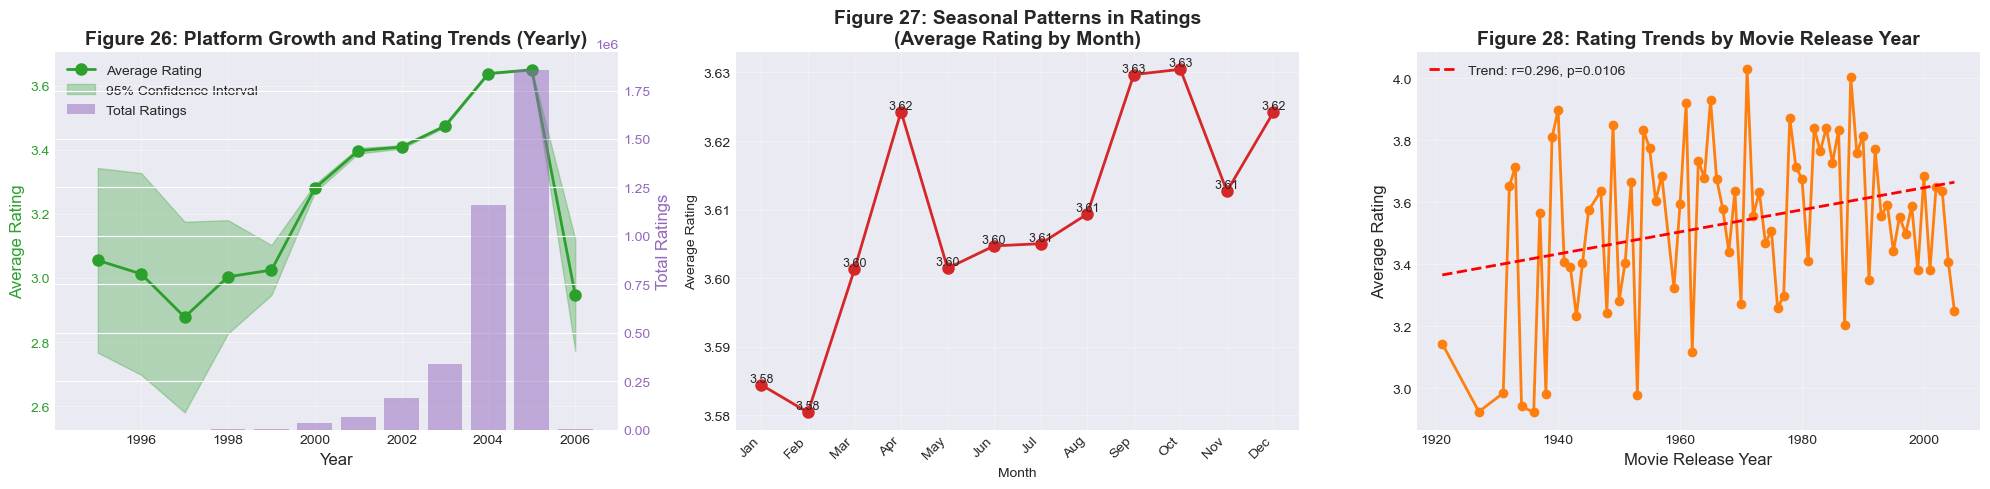

In [57]:
# Prepare temporal data
ratings_with_movies['year'] = ratings_with_movies['date'].dt.year
ratings_with_movies['month'] = ratings_with_movies['date'].dt.month

# Yearly metrics
yearly_metrics = ratings_with_movies.groupby('year').agg({
    'rating': ['count', 'mean', 'std'],
    'customer_id': 'nunique',
    'movie_id': 'nunique'
}).reset_index()
yearly_metrics.columns = ['year', 'total_ratings', 'avg_rating', 'rating_std', 'unique_users', 'unique_movies']

yearly_metrics['rating_se'] = yearly_metrics['rating_std'] / np.sqrt(yearly_metrics['total_ratings'])
yearly_metrics['rating_ci_lower'] = yearly_metrics['avg_rating'] - 1.96 * yearly_metrics['rating_se']
yearly_metrics['rating_ci_upper'] = yearly_metrics['avg_rating'] + 1.96 * yearly_metrics['rating_se']


# Visualizations - Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Platform Growth and Rating Trends (Yearly) - Plot 1 from 5.4
ax1 = axes[0]
ax1_twin = ax1.twinx()

# Primary axis: Average rating per year (line with confidence intervals)
line = ax1.plot(yearly_metrics['year'], yearly_metrics['avg_rating'], 
                linewidth=2, marker='o', markersize=8, color='#2ca02c', label='Average Rating')
ax1.fill_between(yearly_metrics['year'], yearly_metrics['rating_ci_lower'], yearly_metrics['rating_ci_upper'],
                alpha=0.3, color='#2ca02c', label='95% Confidence Interval')

# Secondary axis: Total ratings per year (bars)
bars = ax1_twin.bar(yearly_metrics['year'], yearly_metrics['total_ratings'], 
                    alpha=0.5, color='#9467bd', label='Total Ratings')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Rating', fontsize=12, color='#2ca02c')
ax1_twin.set_ylabel('Total Ratings', fontsize=12, color='#9467bd')
ax1.set_title('Figure 26: Platform Growth and Rating Trends (Yearly)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='#2ca02c')
ax1_twin.tick_params(axis='y', labelcolor='#9467bd')

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 2. Seasonal Patterns in Ratings (Average rating by month across all years)
monthly_rating = ratings_with_movies.groupby('month')['rating'].mean().reset_index()
monthly_rating.columns = ['month', 'avg_rating']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_rating['month_name'] = monthly_rating['month'].apply(lambda x: month_names[x-1])

axes[1].plot(range(len(monthly_rating)), monthly_rating['avg_rating'], 
             linewidth=2, marker='o', markersize=8, color='#d62728')
axes[1].set_xticks(range(len(monthly_rating)))
axes[1].set_xticklabels(monthly_rating['month_name'], rotation=45, ha='right')
axes[1].set_title('Figure 27: Seasonal Patterns in Ratings\n(Average Rating by Month)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_xlabel('Month')
axes[1].grid(True, alpha=0.3)
# Add value labels
for i, val in enumerate(monthly_rating['avg_rating']):
    axes[1].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# 3. Rating Trends by Movie Release Year
release_year_ratings = ratings_with_movies.groupby('year_of_release')['rating'].agg(['mean', 'count']).reset_index()
release_year_ratings.columns = ['release_year', 'avg_rating', 'count']
# Filter to years with sufficient ratings (at least 100)
release_year_ratings = release_year_ratings[release_year_ratings['count'] >= 100].sort_values('release_year')

axes[2].plot(release_year_ratings['release_year'], release_year_ratings['avg_rating'], 
             linewidth=2, marker='o', markersize=6, color='#ff7f0e')
axes[2].set_xlabel('Movie Release Year', fontsize=12)
axes[2].set_ylabel('Average Rating', fontsize=12)
axes[2].set_title('Figure 28: Rating Trends by Movie Release Year', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
# Add trend line
if len(release_year_ratings) > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        release_year_ratings['release_year'], release_year_ratings['avg_rating']
    )
    trend_line = slope * release_year_ratings['release_year'] + intercept
    axes[2].plot(release_year_ratings['release_year'], trend_line, 'r--', linewidth=2, 
                label=f'Trend: r={r_value:.3f}, p={p_value:.4f}')
    axes[2].legend()


plt.tight_layout()
plt.savefig('images/eda_5_4_1_platform_growth.png', dpi=300, bbox_inches='tight')

**Figure 26**

Total ratings and average ratings over time.

**What it says about PLATFORM:**

| Period | Observation | Interpretation |
|--------|-------------|----------------|
| Initial phase (1996–1998) | Total number of ratings was minimal | The Platform was in its infancy, facing growing pains such as bugs, limited features, or a lack of moderation |
| Stabilization and growth (2000–2004) | Number of total ratings slowly climbed. Average rating recovered and steadily rose to a peak of 3.6 in 2004 | Improvement in average rating indicated improved user satisfaction. The green shaded area became tighter, suggesting more consistent user feedback |
| Peak (2004) | 2004 showed highest average rating (3.6) | 2004 was the "golden year" — the platform successfully balanced scale and quality |
| Decline phase (2005–2006) | Sharp decrease in user activity | Dates after 2005 are anomalous dates and should not be trusted |

**Figure 27**

The graph illustrates the average rating trend throughout the year, broken down by month.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Seasonal pattern in user ratings, with two distinct peaks (April and September) and two notable dips (January–February and May) | There is a seasonal pattern in user ratings, with two distinct peaks (April and September) and two notable dips (January–February and May) |

**Figure 28**

Average rating for movies grouped by their release year.

**What it says about MOVIES:**

| Observation | Interpretation |
|-------------|----------------|
| On average, newer movies tend to receive slightly higher ratings than older ones | This is a weak but statistically significant upward trend in movie ratings over the 20th century |

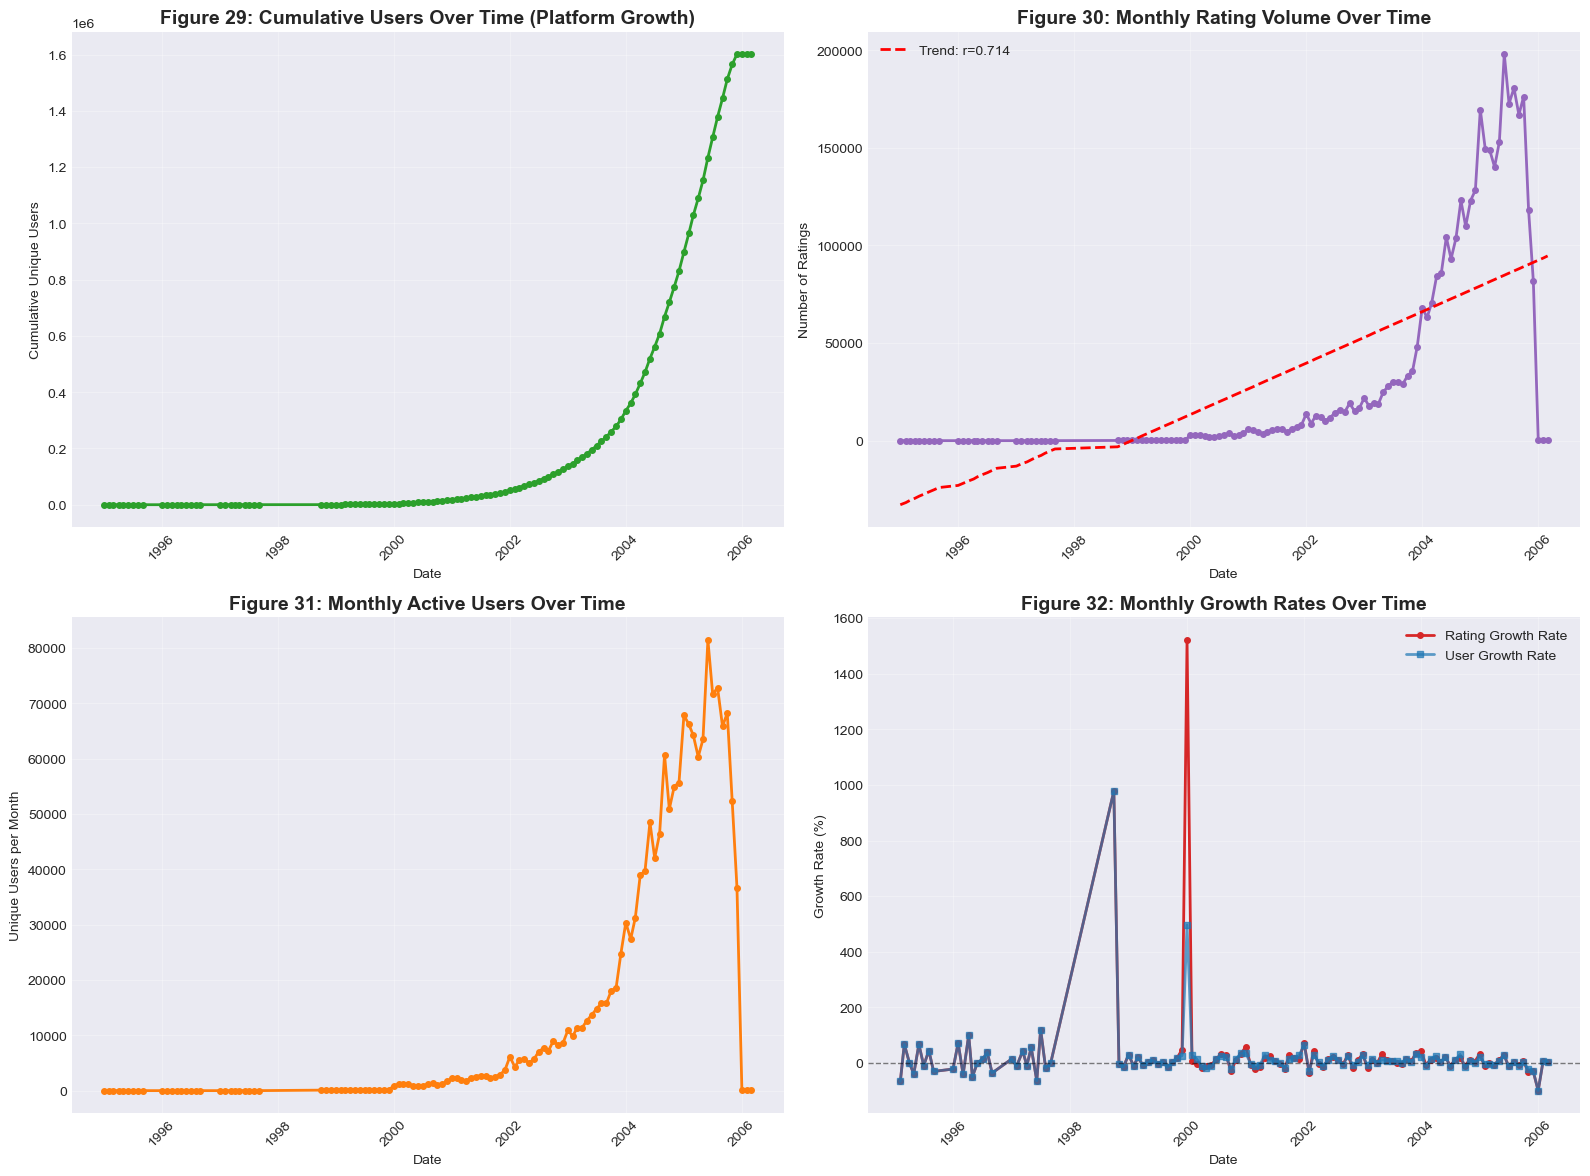

In [58]:
# Monthly growth metrics (for smoother trends)
ratings_with_movies['year_month'] = ratings_with_movies['date'].dt.to_period('M')
monthly_metrics = ratings_with_movies.groupby('year_month').agg({
    'customer_id': 'nunique',
    'movie_id': 'nunique',
    'rating': ['count', 'mean'],
    'date': 'min'
}).reset_index()
monthly_metrics.columns = ['year_month', 'unique_users', 'unique_movies', 'total_ratings', 'avg_rating', 'date']
monthly_metrics = monthly_metrics.sort_values('date')

monthly_metrics['cumulative_users'] = monthly_metrics['unique_users'].cumsum()
monthly_metrics['cumulative_ratings'] = monthly_metrics['total_ratings'].cumsum()

monthly_metrics['user_growth_rate'] = monthly_metrics['unique_users'].pct_change() * 100
monthly_metrics['rating_growth_rate'] = monthly_metrics['total_ratings'].pct_change() * 100

# Additional visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cumulative Users Over Time (Platform Growth)
axes[0, 0].plot(monthly_metrics['date'], monthly_metrics['cumulative_users'], 
               linewidth=2, color='#2ca02c', marker='o', markersize=4)
axes[0, 0].set_title('Figure 29: Cumulative Users Over Time (Platform Growth)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Unique Users')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Monthly Rating Volume Over Time
axes[0, 1].plot(monthly_metrics['date'], monthly_metrics['total_ratings'], 
               linewidth=2, color='#9467bd', marker='o', markersize=4)
axes[0, 1].set_title('Figure 30: Monthly Rating Volume Over Time', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Number of Ratings')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)
# Add trend line
from scipy import stats
mask = ~(monthly_metrics['date'].isna() | monthly_metrics['total_ratings'].isna())
if mask.sum() > 1:
    x_numeric = np.arange(len(monthly_metrics.loc[mask]))
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        x_numeric, monthly_metrics.loc[mask, 'total_ratings']
    )
    trend_line = slope * x_numeric + intercept
    axes[0, 1].plot(monthly_metrics.loc[mask, 'date'], trend_line, 'r--', linewidth=2, 
                   label=f'Trend: r={r_value:.3f}')
    axes[0, 1].legend()

# 3. Monthly Active Users Over Time
axes[1, 0].plot(monthly_metrics['date'], monthly_metrics['unique_users'], 
               linewidth=2, color='#ff7f0e', marker='o', markersize=4)
axes[1, 0].set_title('Figure 31: Monthly Active Users Over Time', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Unique Users per Month')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Growth Rate Over Time
axes[1, 1].plot(monthly_metrics['date'], monthly_metrics['rating_growth_rate'], 
               linewidth=2, color='#d62728', marker='o', markersize=4, label='Rating Growth Rate')
axes[1, 1].plot(monthly_metrics['date'], monthly_metrics['user_growth_rate'], 
               linewidth=2, color='#1f77b4', marker='s', markersize=4, label='User Growth Rate', alpha=0.7)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].set_title('Figure 32: Monthly Growth Rates Over Time', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Growth Rate (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.savefig('images/eda_5_4_1_additional_growth_metrics.png', dpi=300, bbox_inches='tight')


**Figure 29**

The total number of unique users accumulated over time (1996–2006)

**What it says about the PLATFORM:**

| Observation | Interpretation |
|-------------|----------------|
| User base grew over time, with growth becoming self-sustaining | The platform successfully scaled its user base, with growth becoming self-sustaining over time |

**Figure 30**

The number of ratings submitted per month, with a trend line (r = 0.714).

**What it says about the PLATFORM:**

| Observation | Interpretation |
|-------------|----------------|
| Ratings increased over time with strong positive trend (r = 0.714) | User growth directly translated into higher engagement (ratings), with a notable surge in the final years |

**Figure 31**

The number of unique users active each month (MAU — Monthly Active Users).

**What it says about the PLATFORM:**

| Observation | Interpretation |
|-------------|----------------|
| MAU growth mirrors overall user growth trend | The platform not only attracted users but also kept them engaged over time, with MAU growth mirroring the overall user growth trend |

**Figure 32**

Monthly growth rates for both ratings (red line) and users (blue line) as percentages.

**What it says about the PLATFORM:**

| Period | Observation | Interpretation |
|--------|-------------|----------------|
| Exponential Growth Phase (1999–2000) | Very high growth rates for ratings and users | The platform successfully attracted a large audience |
| Maturity Phase (after 2000) | Growth slows down, platform reaches a "plateau" | Growth slows down, the platform reaches a "plateau". This is a typical trajectory for digital services: rapid start → explosive growth → stabilisation |
| Current State | Platform is in plateau phase | Now the Platform is in plateau and needs to find new growth drivers |


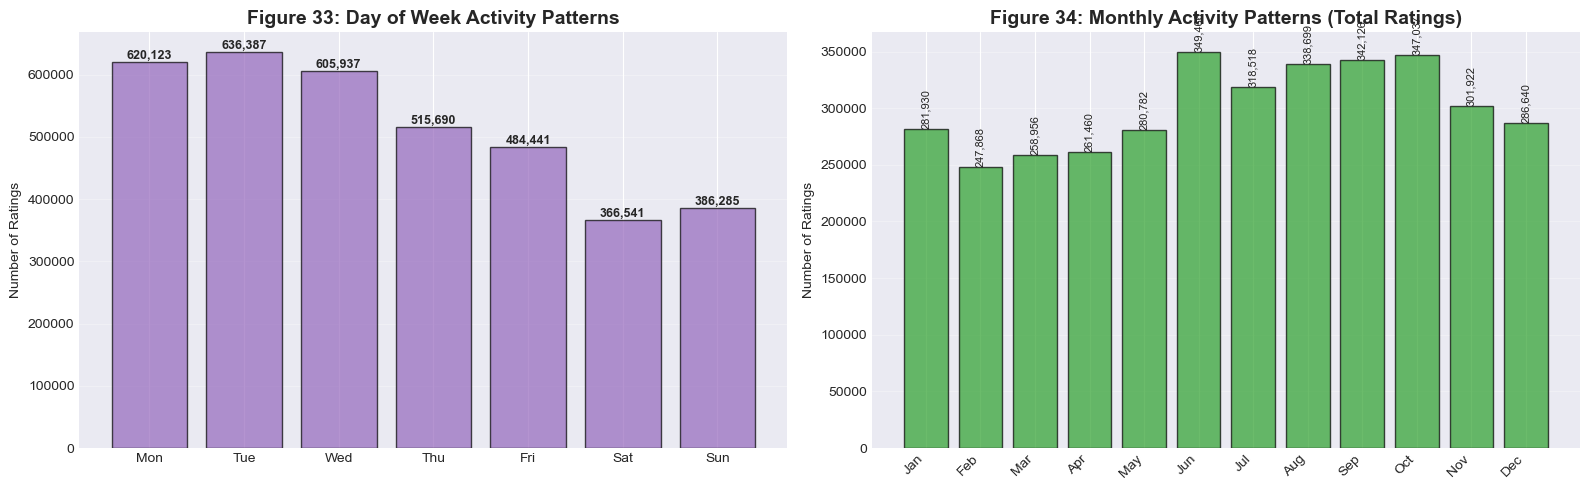

In [59]:

# Day of week patterns
ratings_with_movies['day_of_week'] = ratings_with_movies['date'].dt.dayofweek
day_patterns = ratings_with_movies.groupby('day_of_week').agg({
    'rating': ['count', 'mean'],
    'customer_id': 'nunique'
}).reset_index()
day_patterns.columns = ['day_of_week', 'total_ratings', 'avg_rating', 'unique_users']
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_patterns['day_name'] = day_patterns['day_of_week'].apply(lambda x: day_names[x])

# Monthly patterns
ratings_with_movies['month'] = ratings_with_movies['date'].dt.month
monthly_activity = ratings_with_movies.groupby('month').agg({
    'rating': ['count', 'mean'],
    'customer_id': 'nunique'
}).reset_index()
monthly_activity.columns = ['month', 'total_ratings', 'avg_rating', 'unique_users']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_activity['month_name'] = monthly_activity['month'].apply(lambda x: month_names[x-1])


# Additional seasonal visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Day of Week Activity Patterns
bars = axes[0].bar(range(len(day_patterns)), day_patterns['total_ratings'], 
                  alpha=0.7, edgecolor='black', color='#9467bd')
axes[0].set_xticks(range(len(day_patterns)))
axes[0].set_xticklabels(day_patterns['day_name'])
axes[0].set_title('Figure 33: Day of Week Activity Patterns', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Ratings')
axes[0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(day_patterns['total_ratings']):
    axes[0].text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Monthly Activity Patterns
bars = axes[1].bar(range(len(monthly_activity)), monthly_activity['total_ratings'], 
                  alpha=0.7, edgecolor='black', color='#2ca02c')
axes[1].set_xticks(range(len(monthly_activity)))
axes[1].set_xticklabels(monthly_activity['month_name'], rotation=45, ha='right')
axes[1].set_title('Figure 34: Monthly Activity Patterns (Total Ratings)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Ratings')
axes[1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(monthly_activity['total_ratings']):
    axes[1].text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=8, rotation=90)


plt.tight_layout()
plt.savefig('images/eda_5_4_1_additional_seasonal_patterns.png', dpi=300, bbox_inches='tight')

**Figure 33**

**What it says about the PLATFORM:**

| Observation | Interpretation |
|-------------|----------------|
| Weekday Peak (Monday–Wednesday): Highest activity in first half of week, with Tuesday as absolute peak | Users are most active early in the week, possibly due to routine habits or work-related engagement |
| Decline towards the Weekend: Clear downward trend from Thursday onwards, with ratings dropping by approximately 35–40% from Tuesday to Saturday | User engagement decreases as the week progresses towards the weekend |
| Weekend Low (Saturday–Sunday): Lowest activity on Saturday, with Sunday showing slight recovery | Weekends are associated with less structured time and potentially lower platform usage |
| Content Scheduling Strategy | New content or updates should ideally be released earlier in the week (Monday–Wednesday) to capitalise on higher user activity |
| Weekend Activity Boost | To boost weekend activity, the platform might introduce special weekend-only features, contests, or incentives to counter the drop in ratings |

**Figure 34**

The bar chart illustrates the total number of ratings submitted on a platform throughout the year, broken down by month.

**What it says about USERS:**

| Observation | Interpretation |
|-------------|----------------|
| Clear seasonal pattern in user activity, with peak engagement in summer months (June–October) and a decline in late autumn and winter (November–December) | Clear seasonal pattern in user activity, with peak engagement in summer months (June–October) and a decline in late autumn and winter (November–December) |

## 6. Portraits

---

### Composite User Portrait

| Aspect | Characteristics | Key Insight |
|--------|----------------|-------------|
| **Rating Behavior** | Moderate rater (prefers 3-4 stars, avoids extremes). Most users are consistent (low standard deviation), stable preferences over time | Consistency is the norm, not variability |
| **Activity Level** | Long-tail distribution — few power users (high engagement), many occasional users (1-10 ratings). Most users are satisfied but not overly enthusiastic | 80/20 rule: 20% of users generate 80% of ratings |
| **Engagement Patterns** | Active users: more opinionated (extreme ratings), prefer diverse content. Inactive users: also give extremes but may be less thoughtful. Few-ratings users: consistent, niche preferences | Engagement quantity doesn't correlate with rating quality |
| **Rating Evolution** | Ratings remain stable over time — no significant shift in sentiment. Most users maintain consistent patterns | User preferences are stable, not evolving |

**User Segments Identified:**

| Segment | Size | Characteristics | Platform Impact |
|---------|------|----------------|-----------------|
| **Power Users** | Few | High engagement, diverse content preferences, opinionated | Drive platform activity |
| **Occasional Users** | Many | Low engagement (1-10 ratings), niche preferences, consistent ratings | Need re-engagement strategies |
| **Critical Reviewers** | Some | Lower average ratings, consistent patterns | Require careful content targeting |
| **Generous Raters** | Some | Higher average ratings, moderate consistency | Good for positive content promotion |


---

### Composite Content Portrait

| Aspect | Characteristics | Key Insight |
|--------|----------------|-------------|
| **Popularity Distribution** | Strong long-tail — 80/20 rule (20% of movies get 80% of ratings). 94.8% have 1-10 ratings (niche content) | Most content is niche, not blockbusters |
| **Quality vs Popularity** | Negative correlation — as popularity increases, average ratings decrease. Hidden gems exist (low popularity, high ratings) | Popularity doesn't guarantee quality |
| **Rating Patterns** | Average rating ~3.0 (satisfactory). 64.4% have rating range of 0 (viewer agreement). Most movies are recent releases | Content quality is decent but not exceptional |
| **Content Freshness** | Movie age doesn't affect ratings — no correlation between release year and rating quality | Can recommend both new and old content equally |

**Content Segments:**

| Segment | Size | Characteristics | Platform Impact |
|---------|------|----------------|-----------------|
| **Blockbusters** | Top 20% | High popularity, lower average ratings, more polarizing | Drive most ratings but lower satisfaction |
| **Hidden Gems** | Niche | Low popularity, high ratings (≥4.0), consistent opinions | Opportunity for personalized discovery |
| **Average Content** | Majority | Moderate popularity, ~3.0 rating, viewer agreement | Stable but unremarkable |


---

### Composite Platform Portrait

| Aspect | Status | Details |
|--------|--------|---------|
| **Growth** | Growing | Increasing total ratings over time |
| **Content Quality** | Stable | Decent but not exceptional (few 5-star ratings) |
| **Content Strategy** | Strong long-tail | Diverse catalog with many niche movies. Most content is recent |
| **User Base** | Moderate | Average users (not niche platform). Satisfied but not overly enthusiastic |
| **Engagement** | Long-tail distribution | Few power users, many occasional users |
| **Seasonal Patterns** | Present | Affects content release timing and recommendation strategies |

**Platform Strengths:**
- Diverse catalog (many niche movies)
- Growing user base
- Stable content quality
- Hidden gems discovery opportunity

**Platform Challenges:**
- Content not exceptional (few 5-star ratings)
- Long-tail engagement (few power users)
- Popularity-rating trade-off (blockbusters rate lower)


---

### Key EDA Insights Summary

#### User Insights

| Insight | Finding | Business Implication |
|---------|---------|---------------------|
| **80/20 Rule for Users** | 20% of users generate 80% of ratings | Focus retention efforts on Power Users; they drive engagement |
| **Long-Tail Activity** | Most users have 1-10 ratings (casual), few have many (power users) | Platform has many casual users needing re-engagement strategies |
| **Content Diversity Pattern** | More experienced users prefer diverse content, but stabilize after threshold | Power Users seek variety; Occasional Users prefer niche content |
| **Rating Behavior** | Active users: more opinionated (extreme ratings), prefer diverse content. Inactive users: also give extremes but may be less thoughtful | Rating style correlates with engagement level |

#### Content Insights

| Insight | Finding | Business Implication |
|---------|---------|---------------------|
| **80/20 Rule for Movies** | 20% of movies get 80% of ratings (blockbusters vs. long-tail) | Most content is niche; focus discovery on hidden gems |
| **Hidden Gems** | Low popularity (≤50 ratings) but high ratings (≥4.0) | Opportunity for personalized discovery |
| **Popularity-Rating Trade-off** | As popularity increases, average ratings tend to decrease | Blockbusters get more ratings but lower average scores |
| **Polarizing Movies** | Medium-popularity movies are more divisive (higher rating variance) | Need careful targeting for polarizing content |
| **Movie Age** | No correlation between movie age and ratings | Can recommend both new and old content equally |

#### Platform Insights

| Insight | Status | Impact |
|---------|--------|--------|
| **Growth** | Growing | Increasing total ratings over time |
| **Content Quality** | Stable but not exceptional | Decent but not exceptional ratings |
| **Catalog** | Strong long-tail | Diverse, niche content |
| **User Base** | Moderate, average | Not a niche platform |
| **Seasonal Patterns** | Present | Affects content release timing and recommendation strategies |

# USER CLUSTERING

## 1. Feature Engineering for USERS
---

To cluster users, we create these features, based on EDA insights:

- ratings_per_day — Engagement frequency
- rating_extremity — Extreme vs. moderate rater

In [60]:
# Initialize user features dataframe for clustering
# Use pre-computed user_features from preprocessing
user_features = user_features.copy()  # Use the one from preprocessing

user_features = user_features.rename(columns={
    'user_total_ratings': 'total_ratings',
    'user_avg_rating': 'avg_rating_given',
    'user_std_rating': 'rating_std',
    'user_min_rating': 'min_rating',
    'user_max_rating': 'max_rating',
    'user_first_rating_date': 'first_rating_date',
    'user_last_rating_date': 'last_rating_date',
    'activity_days': 'engagement_period_days'
})

# Compute ratings_per_day from existing stats
user_features['ratings_per_day'] = user_features['total_ratings'] / user_features['engagement_period_days'].clip(lower=1)

# Compute rating_extremity from existing stats
user_features['rating_extremity'] = ((user_features['max_rating'] - 3).abs() + (user_features['min_rating'] - 3).abs()) / 2

# Check and prepare for clustering
print(f"User features shape: {user_features.shape}")
print(f"Missing values:\n{user_features.isnull().sum()}")
user_features_copy = user_features.copy()

User features shape: (438281, 12)
Missing values:
customer_id               0
total_ratings             0
avg_rating_given          0
rating_std                0
min_rating                0
max_rating                0
unique_movies             0
first_rating_date         0
last_rating_date          0
engagement_period_days    0
ratings_per_day           0
rating_extremity          0
dtype: int64


## 2. User Clustering

---



#### K-Means Clustering

**How it works:** K-Means partitions data into k clusters by minimizing within-cluster variance. It iteratively assigns points to the nearest centroid and updates centroids until convergence. Assumes spherical clusters of similar size.

**Strengths:** Fast, simple, works well with well-separated clusters  
**Weaknesses:** Requires specifying k, assumes spherical clusters, sensitive to outliers

1. Remove customer_id if present - it's an identifier, not a feature for clustering.


In [61]:
user_ids = user_features['customer_id'].copy() if 'customer_id' in user_features.columns else None

# Create clustering dataframe without customer_id
user_features_clustering = user_features.drop(columns=['customer_id']).copy() if 'customer_id' in user_features.columns else user_features.copy()

user_features_clustering_transformed = user_features_clustering.copy()

2. Scale features to ensure all features contribute equally to clustering. 

In [62]:
# Select only numeric features for clustering
clustering_features = ['total_ratings', 'ratings_per_day', 'avg_rating_given', 
                       'engagement_period_days', 'rating_extremity']

# Add rating_std if it exists
if 'rating_std' in user_features_clustering_transformed.columns:
    clustering_features.append('rating_std')

# Keep only clustering features
user_features_clustering_transformed = user_features_clustering_transformed[clustering_features].copy()

features_to_log = ['total_ratings', 'ratings_per_day', 'engagement_period_days']
for col in features_to_log:
    if col in user_features_clustering_transformed.columns:
        user_features_clustering_transformed[col] = np.log1p(user_features_clustering_transformed[col])

scaler_user = StandardScaler()
user_features_scaled = scaler_user.fit_transform(user_features_clustering_transformed)

3. Use a sample of 10000 customers for testing.

In [63]:
sample_size_user = 10000
if len(user_features_scaled) > sample_size_user:
    sample_indices = np.random.choice(len(user_features_scaled), sample_size_user, replace=False)
    user_features_scaled_sample = user_features_scaled[sample_indices]
    print(f"Using sample of {sample_size_user} users for K-Means testing")
else:
    user_features_scaled_sample = user_features_scaled
    print(f"Using all {len(user_features_scaled)} users")

Using sample of 10000 users for K-Means testing


4. Test k values from 2 to 10 and calculate inertia and silhouette scores for each k.


In [64]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(user_features_scaled_sample)
    inertia = kmeans.inertia_
    sil = silhouette_score(user_features_scaled_sample, labels)
    inertias.append(inertia)
    silhouettes.append(sil)
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil:.4f}")


k=2: Inertia=37579.37, Silhouette=0.4036
k=3: Inertia=31617.22, Silhouette=0.3944
k=4: Inertia=25999.45, Silhouette=0.2996
k=5: Inertia=21500.22, Silhouette=0.3319
k=6: Inertia=18522.17, Silhouette=0.3498
k=7: Inertia=16349.12, Silhouette=0.3381
k=8: Inertia=14746.43, Silhouette=0.3308
k=9: Inertia=13390.27, Silhouette=0.3582
k=10: Inertia=12502.70, Silhouette=0.3491


5. Visualize the elbow method (inertia) and silhouette scores to help choose optimal k. The elbow shows where adding more clusters provides diminishing returns.


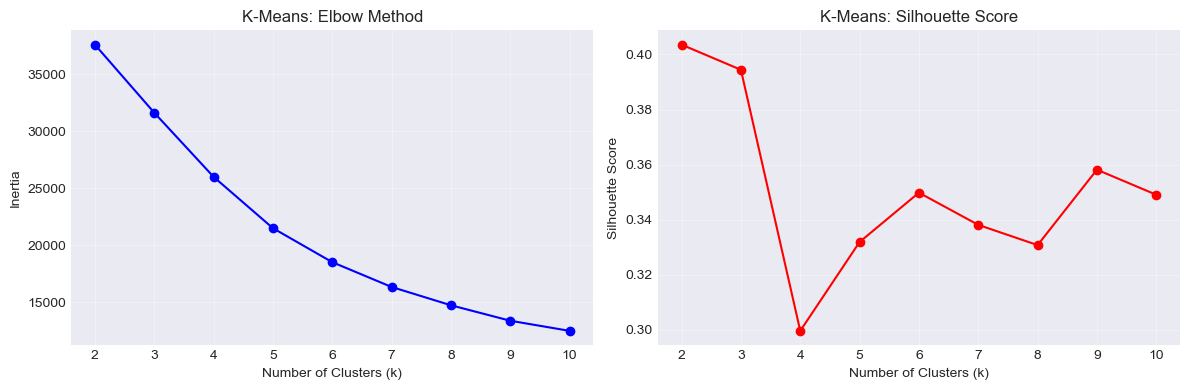

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('K-Means: Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouettes, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('K-Means: Silhouette Score')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/kmeans_elbow_silhouette.png', dpi=300, bbox_inches='tight')

6. Choose k=6 based on the elbow plot and silhouette analysis. This provides good cluster separation while maintaining interpretability for business use.


In [66]:
chosen_k_user = 6

7. Run final K-Means clustering on the full dataset with chosen k=6. This assigns all users to clusters.


In [67]:
kmeans_user = KMeans(n_clusters=chosen_k_user, random_state=RANDOM_STATE, n_init=10)
user_labels_kmeans = kmeans_user.fit_predict(user_features_scaled)
user_features['kmeans_cluster'] = user_labels_kmeans


8. Visualize clusters in 2D PCA space. Each color represents a different cluster.


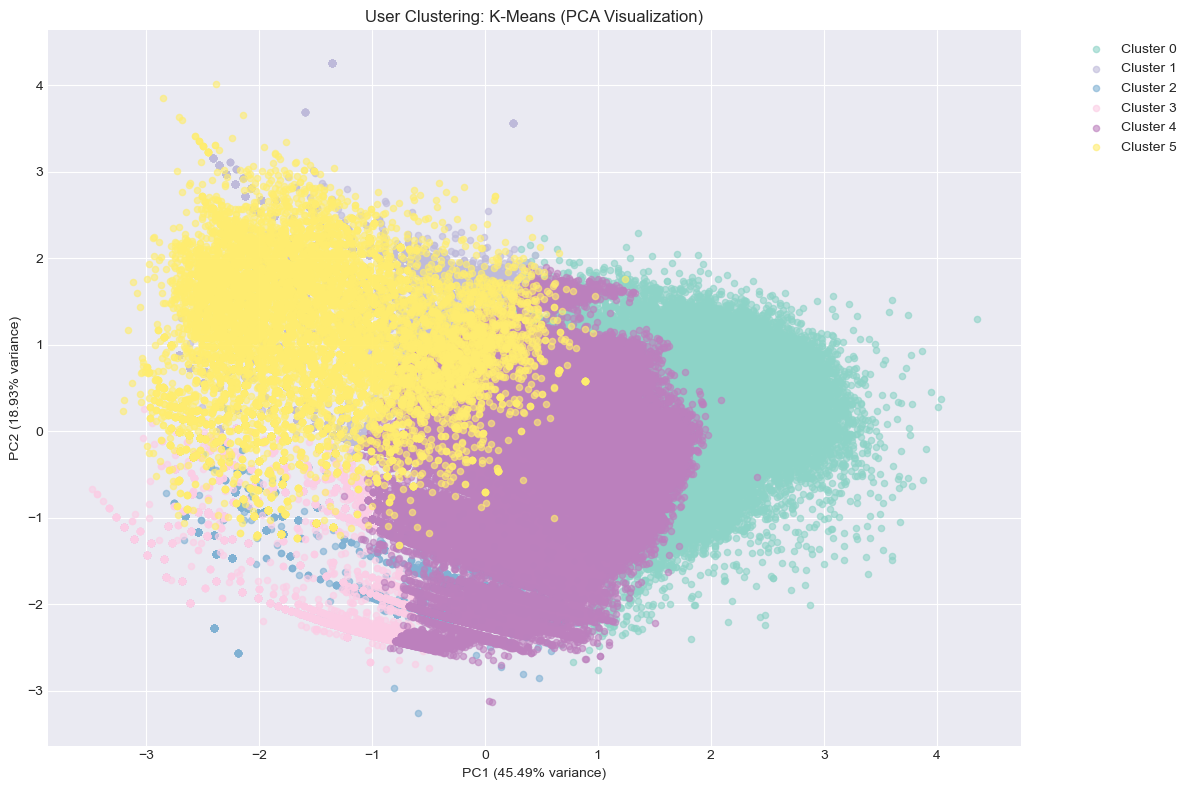

In [68]:
pca_user = PCA(n_components=2, random_state=RANDOM_STATE)
user_pca = pca_user.fit_transform(user_features_scaled)

n_clusters = len(np.unique(user_labels_kmeans))
colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))

plt.figure(figsize=(12, 8))
for i, cluster_id in enumerate(sorted(np.unique(user_labels_kmeans))):
    mask = user_labels_kmeans == cluster_id
    plt.scatter(user_pca[mask, 0], user_pca[mask, 1], 
                c=[colors[i]], label=f'Cluster {cluster_id}', 
                alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_user.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_user.explained_variance_ratio_[1]:.2%} variance)')
plt.title('User Clustering: K-Means (PCA Visualization)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')


9. Visualize clusters in 3D PCA space. Each color represents a different cluster for better separation view.


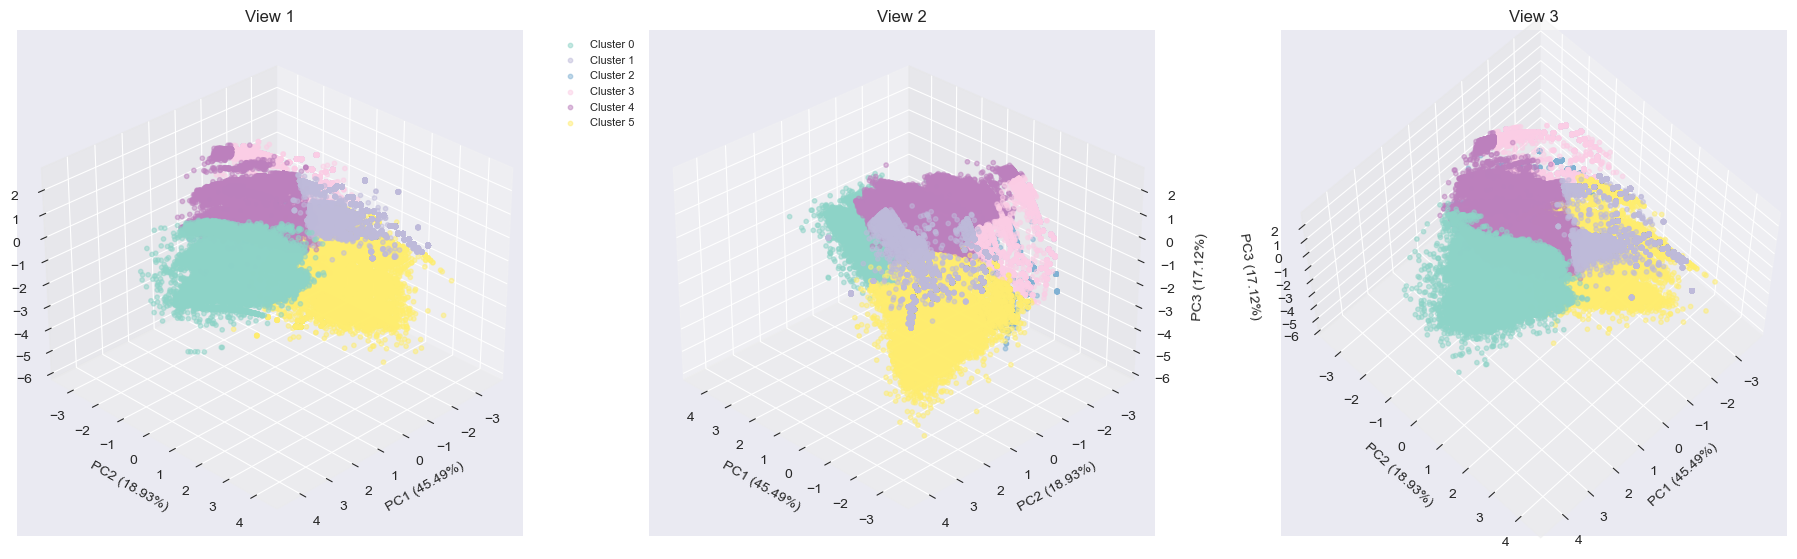

In [69]:
pca_user_3d = PCA(n_components=3, random_state=RANDOM_STATE)
user_pca_3d = pca_user_3d.fit_transform(user_features_scaled)

n_clusters = len(np.unique(user_labels_kmeans))
colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))

fig = plt.figure(figsize=(18, 6))

angles = [(30, 45), (30, 135), (60, 45)]
titles = ['View 1', 'View 2', 'View 3']

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    
    for i, cluster_id in enumerate(sorted(np.unique(user_labels_kmeans))):
        mask = user_labels_kmeans == cluster_id
        cluster_name = user_features.loc[user_features['kmeans_cluster'] == cluster_id, 'cluster_name'].iloc[0] if 'cluster_name' in user_features.columns else f'Cluster {cluster_id}'
        ax.scatter(user_pca_3d[mask, 0], user_pca_3d[mask, 1], user_pca_3d[mask, 2],
                   c=[colors[i]], label=cluster_name, alpha=0.5, s=10)
    
    ax.set_xlabel(f'PC1 ({pca_user_3d.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca_user_3d.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca_user_3d.explained_variance_ratio_[2]:.2%})')
    ax.set_title(titles[idx])
    ax.view_init(elev=elev, azim=azim)
    if idx == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('images/kmeans_clusters_3d_pca.png', dpi=300, bbox_inches='tight')


### GMM (Gaussian Mixture Model) Clustering

**How it works:** GMM assumes data comes from a mixture of Gaussian distributions. It uses Expectation-Maximization to find the parameters (means, covariances, weights) of each Gaussian component. Provides probabilistic cluster assignments rather than hard assignments.

**Strengths:** Handles elliptical clusters, provides soft assignments, can model overlapping clusters  
**Weaknesses:** Slower than K-Means, can overfit with many components, assumes Gaussian distribution

1. Create a sample of 10,000 users for faster GMM parameter testing.


In [70]:
sample_size_user = 10000
if len(user_features_scaled) > sample_size_user:
    sample_indices = np.random.choice(len(user_features_scaled), sample_size_user, replace=False)
    user_features_scaled_sample = user_features_scaled[sample_indices]
    print(f"Using sample of {sample_size_user} users for GMM testing")
else:
    user_features_scaled_sample = user_features_scaled
    print(f"Using all {len(user_features_scaled)} users")

Using sample of 10000 users for GMM testing


2. Test different numbers of components (2-10) and calculate AIC, BIC, and silhouette scores for each. AIC/BIC help balance model complexity with fit quality.


In [71]:
n_components_range = range(2, 11)
gmm_results = []

for n in n_components_range:
    gmm_tmp = GaussianMixture(n_components=n, random_state=RANDOM_STATE, max_iter=100)
    gmm_tmp.fit(user_features_scaled_sample)  
    labels = gmm_tmp.predict(user_features_scaled_sample)  
    sil = silhouette_score(user_features_scaled_sample, labels)  
    aic = gmm_tmp.aic(user_features_scaled_sample)
    bic = gmm_tmp.bic(user_features_scaled_sample)
    gmm_results.append({'n_components': n, 'AIC': aic, 
                        'BIC': bic, 'silhouette': sil})
    print(f"n={n}: AIC={aic:.2f}, BIC={bic:.2f}, Silhouette={sil:.4f}")

n=2: AIC=100270.69, BIC=100667.25, Silhouette=0.4065
n=3: AIC=66844.72, BIC=67443.17, Silhouette=0.2718
n=4: AIC=26711.61, BIC=27511.95, Silhouette=0.1556
n=5: AIC=-13767.65, BIC=-12765.41, Silhouette=0.1797
n=6: AIC=-2610.71, BIC=-1406.58, Silhouette=0.1134
n=7: AIC=-27082.47, BIC=-25676.46, Silhouette=0.1333
n=8: AIC=-23222.30, BIC=-21614.39, Silhouette=0.1258
n=9: AIC=-58675.77, BIC=-56865.98, Silhouette=0.1499
n=10: AIC=-63627.41, BIC=-61615.73, Silhouette=0.1261


3. Visualize AIC/BIC (lower is better) and silhouette scores to choose optimal number of components.


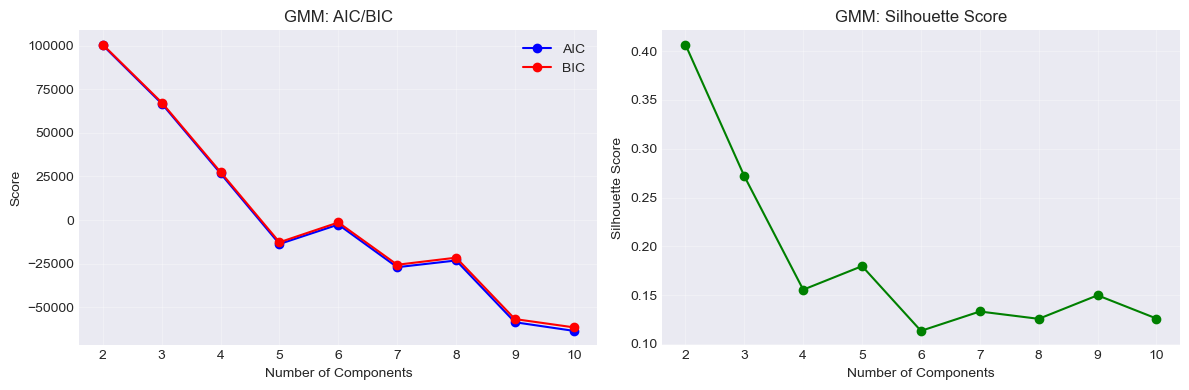

In [72]:
gmm_df = pd.DataFrame(gmm_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(gmm_df['n_components'], gmm_df['AIC'], 'b-o', label='AIC')
ax1.plot(gmm_df['n_components'], gmm_df['BIC'], 'r-o', label='BIC')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Score')
ax1.set_title('GMM: AIC/BIC')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(gmm_df['n_components'], gmm_df['silhouette'], 'g-o')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('GMM: Silhouette Score')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/gmm_metrics.png', dpi=300, bbox_inches='tight')


4. Choose n=3 components based on AIC/BIC and silhouette analysis. This balances model complexity with cluster quality.


In [73]:
chosen_n_user = 3


5. Run final GMM clustering on the full dataset with chosen n=7 components.


In [74]:
gmm_user = GaussianMixture(n_components=chosen_n_user, random_state=RANDOM_STATE)
user_labels_gmm = gmm_user.fit_predict(user_features_scaled)
user_features['gmm_cluster'] = user_labels_gmm


6. Visualize GMM clusters in 2D PCA space.


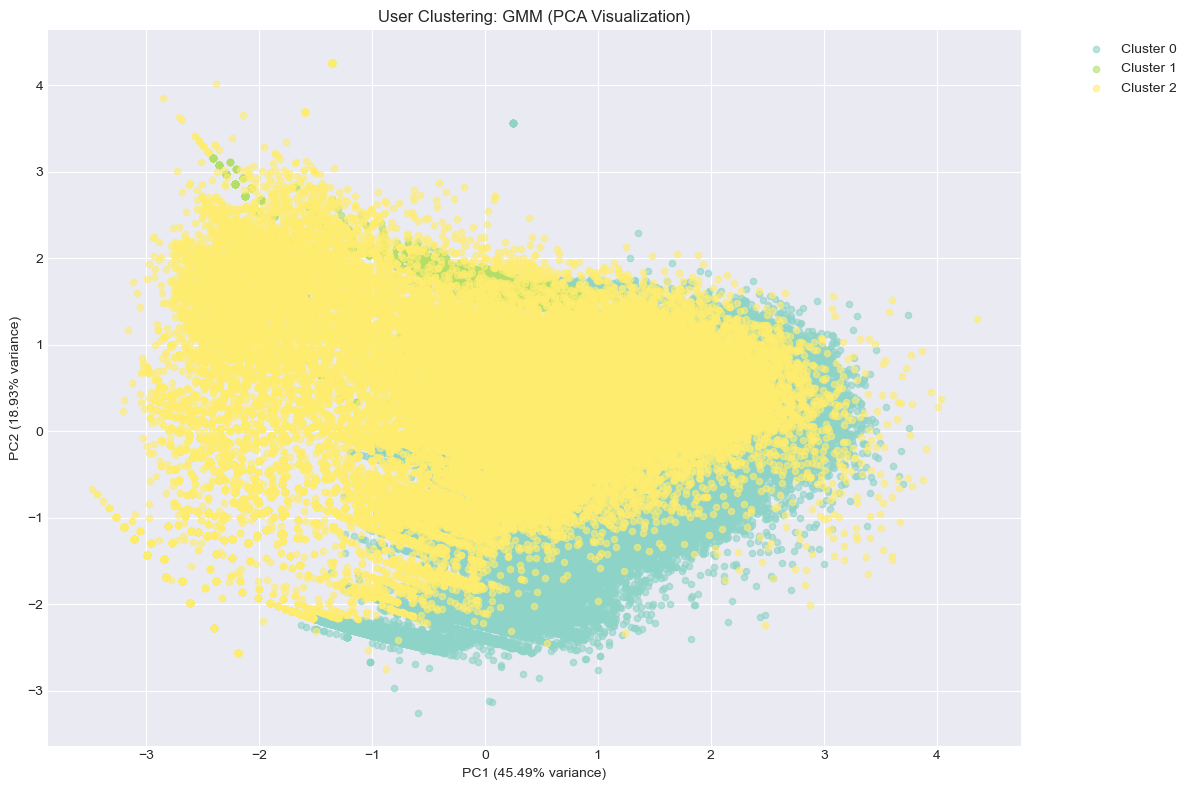

In [75]:
# 2D PCA Visualization for GMM
user_pca_gmm = pca_user.transform(user_features_scaled)

n_clusters_gmm = len(np.unique(user_labels_gmm))
colors_gmm = plt.cm.Set3(np.linspace(0, 1, n_clusters_gmm))

plt.figure(figsize=(12, 8))
for i, cluster_id in enumerate(sorted(np.unique(user_labels_gmm))):
    mask = user_labels_gmm == cluster_id
    cluster_name = user_features.loc[user_features['gmm_cluster'] == cluster_id, 'cluster_name'].iloc[0] if 'cluster_name' in user_features.columns else f'Cluster {cluster_id}'
    plt.scatter(user_pca_gmm[mask, 0], user_pca_gmm[mask, 1], 
                c=[colors_gmm[i]], label=cluster_name, 
                alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_user.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_user.explained_variance_ratio_[1]:.2%} variance)')
plt.title('User Clustering: GMM (PCA Visualization)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/gmm_clusters_pca.png', dpi=300, bbox_inches='tight')


7. Visualize GMM clusters in 3D PCA space.

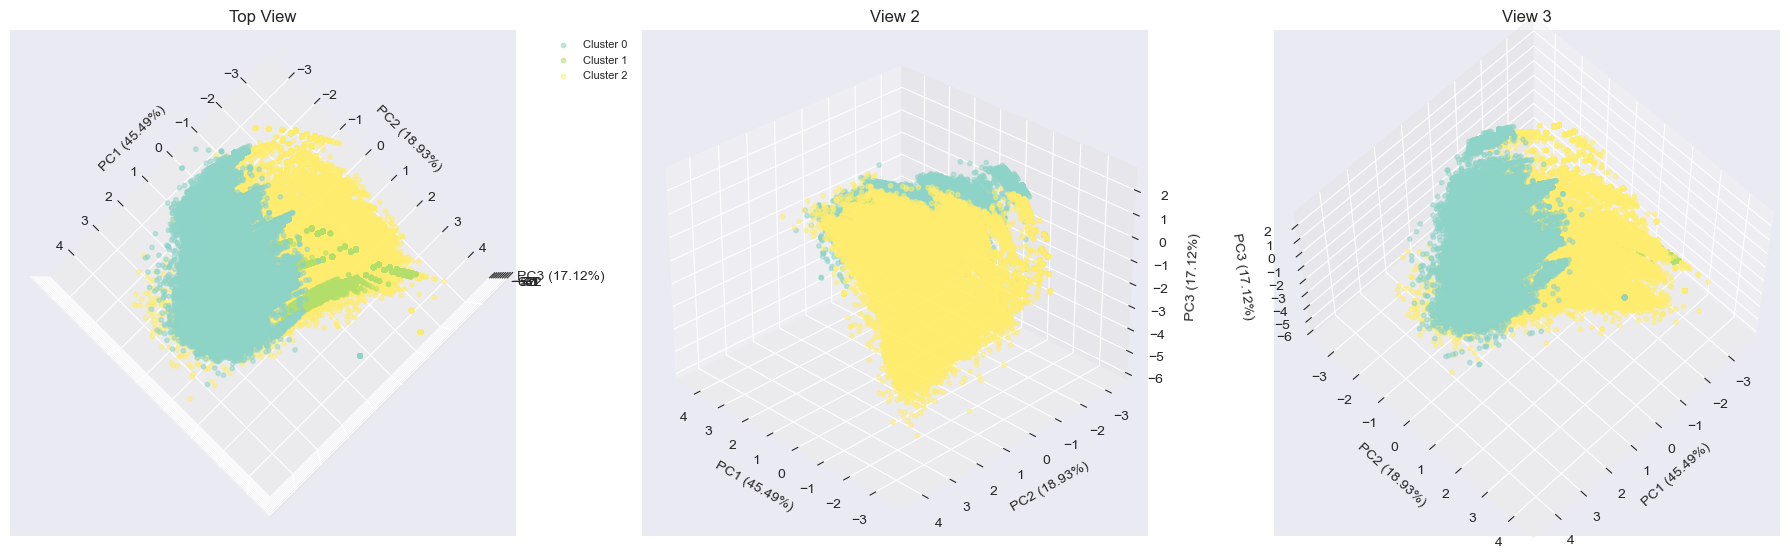

In [76]:
pca_user_3d = PCA(n_components=3, random_state=RANDOM_STATE)
user_pca_gmm_3d = pca_user_3d.fit_transform(user_features_scaled)

n_clusters_gmm = len(np.unique(user_labels_gmm))
colors_gmm = plt.cm.Set3(np.linspace(0, 1, n_clusters_gmm))

fig = plt.figure(figsize=(18, 6))

angles = [(90, 45), (30, 135), (60, 45)]  # First view is now top-down
titles = ['Top View', 'View 2', 'View 3']

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    
    for i, cluster_id in enumerate(sorted(np.unique(user_labels_gmm))):
        mask = user_labels_gmm == cluster_id
        cluster_name = user_features.loc[user_features['gmm_cluster'] == cluster_id, 'cluster_name'].iloc[0] if 'cluster_name' in user_features.columns else f'Cluster {cluster_id}'
        ax.scatter(user_pca_gmm_3d[mask, 0], user_pca_gmm_3d[mask, 1], user_pca_gmm_3d[mask, 2],
                   c=[colors_gmm[i]], label=cluster_name, alpha=0.5, s=10)
    
    ax.set_xlabel(f'PC1 ({pca_user_3d.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca_user_3d.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca_user_3d.explained_variance_ratio_[2]:.2%})')
    ax.set_title(titles[idx])
    ax.view_init(elev=elev, azim=azim)
    if idx == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('images/gmm_clusters_3d_pca.png', dpi=300, bbox_inches='tight')


### BIRCH Clustering

**How it works:** BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies) builds a CF (Clustering Feature) tree to summarize data efficiently. Designed for large datasets, it can automatically determine the number of clusters based on a threshold parameter without requiring k to be specified upfront.

**Strengths:** Handles large datasets efficiently, memory-efficient, can find natural number of clusters  
**Weaknesses:** Sensitive to threshold parameter, can produce too many clusters, less interpretable

1. Create a sample of 10,000 users for faster BIRCH parameter testing.


In [77]:
sample_size_user = 10000
if len(user_features_scaled) > sample_size_user:
    sample_indices = np.random.choice(len(user_features_scaled), sample_size_user, replace=False)
    user_features_scaled_sample = user_features_scaled[sample_indices]
    print(f"Using sample of {sample_size_user} users for BIRCH testing")
else:
    user_features_scaled_sample = user_features_scaled
    print(f"Using all {len(user_features_scaled)} users")

Using sample of 10000 users for BIRCH testing


2. Test different threshold values (0.1 to 1.2) to find optimal number of clusters. BIRCH automatically determines cluster count based on threshold.


In [78]:
threshold_range = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.2, 1.3, 1.4]
birch_results = []

for thresh in threshold_range:
    birch_tmp = Birch(threshold=thresh, n_clusters=None)
    birch_tmp.fit(user_features_scaled_sample)  # Use sample here
    labels = birch_tmp.predict(user_features_scaled_sample)  # Use sample here
    n_clusters = len(np.unique(labels))
    if n_clusters > 1:
        sil = silhouette_score(user_features_scaled_sample, labels)  # Use sample here
        birch_results.append({'threshold': thresh, 'n_clusters': n_clusters, 'silhouette': sil})

3. Visualize how threshold affects number of clusters and silhouette scores.


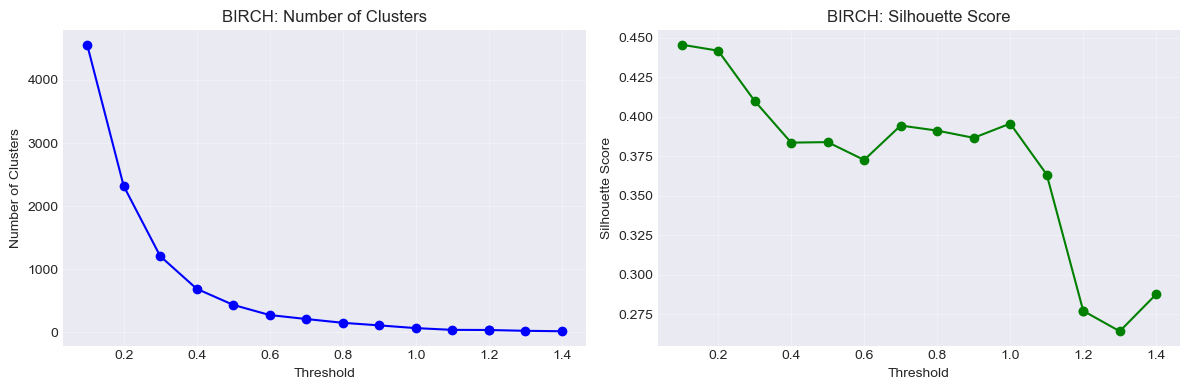

In [79]:

birch_df = pd.DataFrame(birch_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(birch_df['threshold'], birch_df['n_clusters'], 'b-o')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Number of Clusters')
ax1.set_title('BIRCH: Number of Clusters')
ax1.grid(True, alpha=0.3)

ax2.plot(birch_df['threshold'], birch_df['silhouette'], 'g-o')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('BIRCH: Silhouette Score')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/birch_threshold_selection.png', dpi=300, bbox_inches='tight')


4. Select the threshold that gives the best silhouette score. This determines the optimal number of clusters for BIRCH.


In [80]:
# Display BIRCH results to help you choose
print("BIRCH Parameter Testing Results:")
print(birch_df.sort_values('silhouette', ascending=False))
print("\nChoose your preferred threshold and number of clusters based on the results above.")

BIRCH Parameter Testing Results:
    threshold  n_clusters  silhouette
0         0.1        4559    0.445697
1         0.2        2319    0.441889
2         0.3        1207    0.410085
9         1.0          66    0.395720
6         0.7         210    0.394477
7         0.8         150    0.391269
8         0.9         109    0.386692
4         0.5         434    0.383981
3         0.4         689    0.383672
5         0.6         273    0.372681
10        1.1          38    0.363444
14        1.4          16    0.287710
11        1.2          36    0.277116
12        1.2          36    0.277116
13        1.3          23    0.264217

Choose your preferred threshold and number of clusters based on the results above.


In [81]:
chosen_threshold_user = 1.4  
chosen_n_birch_user = 13

print(f"\nSelected threshold: {chosen_threshold_user}")
print(f"Selected number of clusters: {chosen_n_birch_user}")


Selected threshold: 1.4
Selected number of clusters: 13


5. Run final BIRCH clustering on the full dataset with chosen threshold.


In [82]:
birch_user = Birch(threshold=chosen_threshold_user, n_clusters=chosen_n_birch_user)
user_labels_birch = birch_user.fit_predict(user_features_scaled)
user_features['birch_cluster'] = user_labels_birch

6. Visualize BIRCH clusters in 2D PCA space.


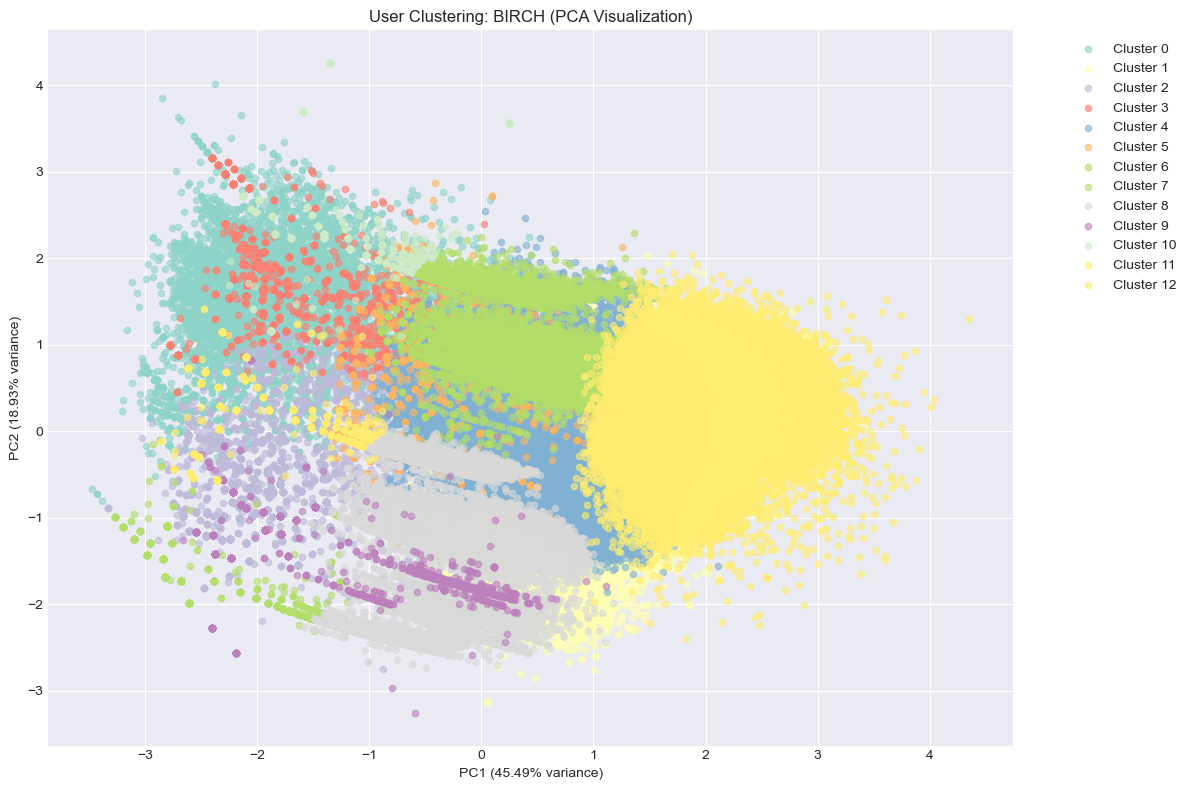

In [83]:
user_pca_birch = pca_user.transform(user_features_scaled)

n_clusters_birch = len(np.unique(user_labels_birch))
colors_birch = plt.cm.Set3(np.linspace(0, 1, n_clusters_birch))

plt.figure(figsize=(12, 8))
for i, cluster_id in enumerate(sorted(np.unique(user_labels_birch))):
    mask = user_labels_birch == cluster_id
    plt.scatter(user_pca_birch[mask, 0], user_pca_birch[mask, 1], 
                c=[colors_birch[i]], label=f'Cluster {cluster_id}', 
                alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_user.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_user.explained_variance_ratio_[1]:.2%} variance)')
plt.title('User Clustering: BIRCH (PCA Visualization)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/birch_clusters_pca.png', dpi=300, bbox_inches='tight')


7. Visualize BIRCH clusters in 3D PCA space.

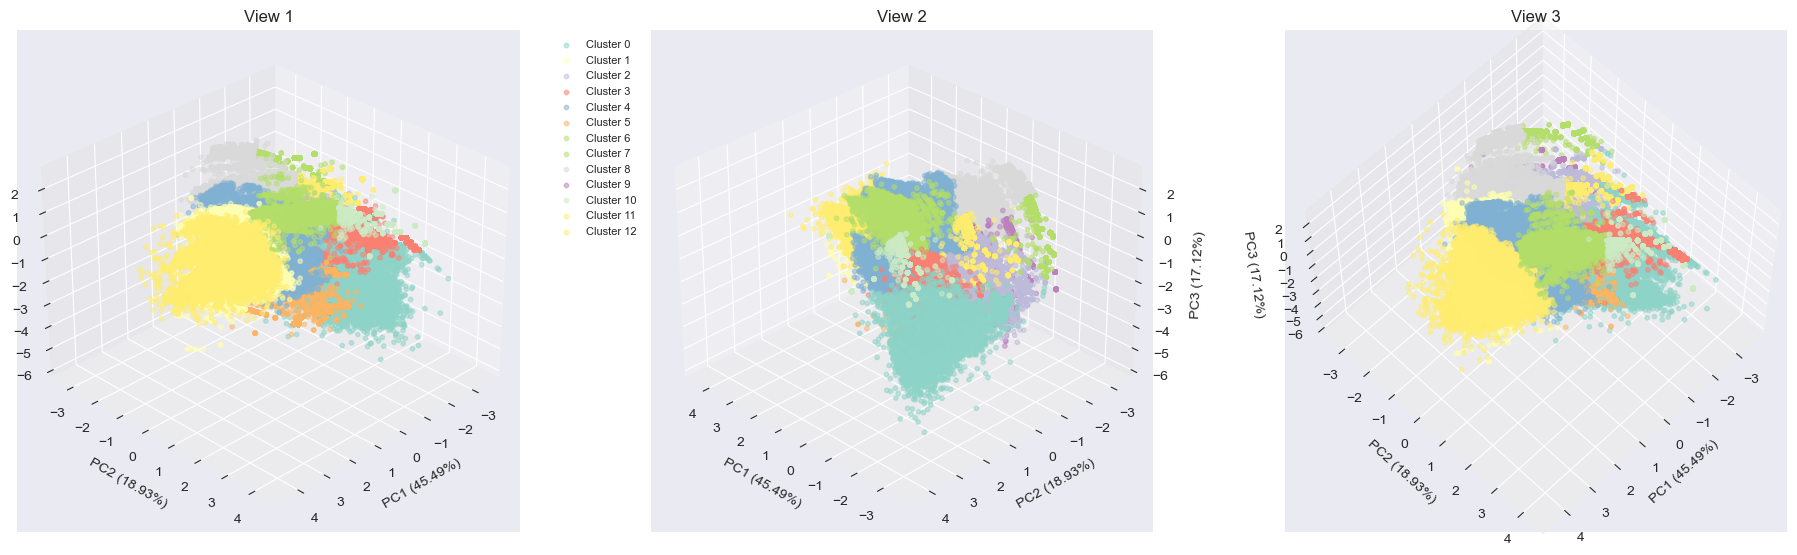

In [84]:
# 3D PCA Visualization for BIRCH (multiple views)
pca_user_3d = PCA(n_components=3, random_state=RANDOM_STATE)
user_pca_birch_3d = pca_user_3d.fit_transform(user_features_scaled)

n_clusters_birch = len(np.unique(user_labels_birch))
colors_birch = plt.cm.Set3(np.linspace(0, 1, n_clusters_birch))

fig = plt.figure(figsize=(18, 6))

angles = [(30, 45), (30, 135), (60, 45)]
titles = ['View 1', 'View 2', 'View 3']

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    
    for i, cluster_id in enumerate(sorted(np.unique(user_labels_birch))):
        mask = user_labels_birch == cluster_id
        cluster_name = user_features.loc[user_features['birch_cluster'] == cluster_id, 'cluster_name'].iloc[0] if 'cluster_name' in user_features.columns else f'Cluster {cluster_id}'
        ax.scatter(user_pca_birch_3d[mask, 0], user_pca_birch_3d[mask, 1], user_pca_birch_3d[mask, 2],
                   c=[colors_birch[i]], label=cluster_name, alpha=0.5, s=10)
    
    ax.set_xlabel(f'PC1 ({pca_user_3d.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca_user_3d.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca_user_3d.explained_variance_ratio_[2]:.2%})')
    ax.set_title(titles[idx])
    ax.view_init(elev=elev, azim=azim)
    if idx == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('images/birch_clusters_3d_pca.png', dpi=300, bbox_inches='tight')


### Agglomerative Clustering

**How it works:** Hierarchical clustering that starts with each point as its own cluster, then iteratively merges the closest clusters. Uses linkage criteria (ward) to determine cluster distance. Ward linkage minimizes within-cluster variance when merging.

**Strengths:** No assumption about cluster shape, creates interpretable hierarchy, deterministic results  
**Weaknesses:** Computationally expensive for large datasets, sensitive to outliers, once merged cannot be undone

1. Create a sample of 10,000 users for faster Agglomerative parameter testing.


In [85]:
from sklearn.cluster import AgglomerativeClustering

sample_size_user = 10000
if len(user_features_scaled) > sample_size_user:
    sample_indices = np.random.choice(len(user_features_scaled), sample_size_user, replace=False)
    user_features_scaled_sample = user_features_scaled[sample_indices]
    print(f"Using sample of {sample_size_user} users for Agglomerative testing")
else:
    user_features_scaled_sample = user_features_scaled
    print(f"Using all {len(user_features_scaled)} users")


Using sample of 10000 users for Agglomerative testing


2. Test different k values (2-10) using ward linkage, which minimizes within-cluster variance.


In [86]:
k_range = range(2, 11)
agg_results = []

for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(user_features_scaled_sample)
    sil = silhouette_score(user_features_scaled_sample, labels)
    agg_results.append({'n_clusters': k, 'silhouette': sil})
    print(f"k={k}: Silhouette={sil:.4f}")

k=2: Silhouette=0.4073
k=3: Silhouette=0.3933
k=4: Silhouette=0.2547
k=5: Silhouette=0.2817
k=6: Silhouette=0.3076
k=7: Silhouette=0.2866
k=8: Silhouette=0.3075
k=9: Silhouette=0.3406
k=10: Silhouette=0.3352


3. Visualize silhouette scores for different k values to choose optimal number of clusters.


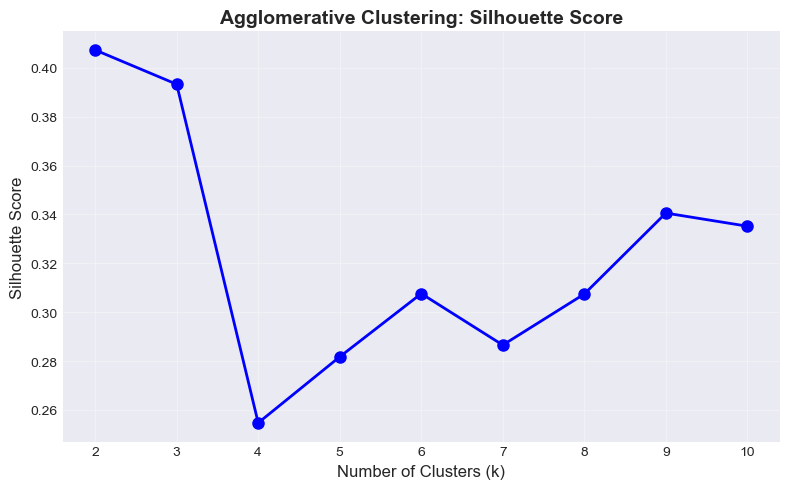

In [87]:
agg_df = pd.DataFrame(agg_results)

plt.figure(figsize=(8, 5))
plt.plot(agg_df['n_clusters'], agg_df['silhouette'], 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Agglomerative Clustering: Silhouette Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(agg_df['n_clusters'])
plt.tight_layout()
plt.savefig('images/agglomerative_silhouette.png', dpi=300, bbox_inches='tight')


4. I choose 6 clusters according to the silhouette score. Visualize clusters in 2D PCA space. Each color represents a different cluster for better separation view.


In [88]:
# Make sure to use the same sample_indices to keep consistency
agg_final = AgglomerativeClustering(n_clusters=6, linkage='ward')
user_labels_agg_sample = agg_final.fit_predict(user_features_scaled_sample)

user_labels_agg = np.full(len(user_features_scaled), -1)
user_labels_agg[sample_indices] = user_labels_agg_sample

user_features_sample = user_features.iloc[sample_indices].copy()
user_features_sample['agg_cluster'] = user_labels_agg_sample

5. Visualize clusters in 2D PCA space. Each color represents a different cluster.


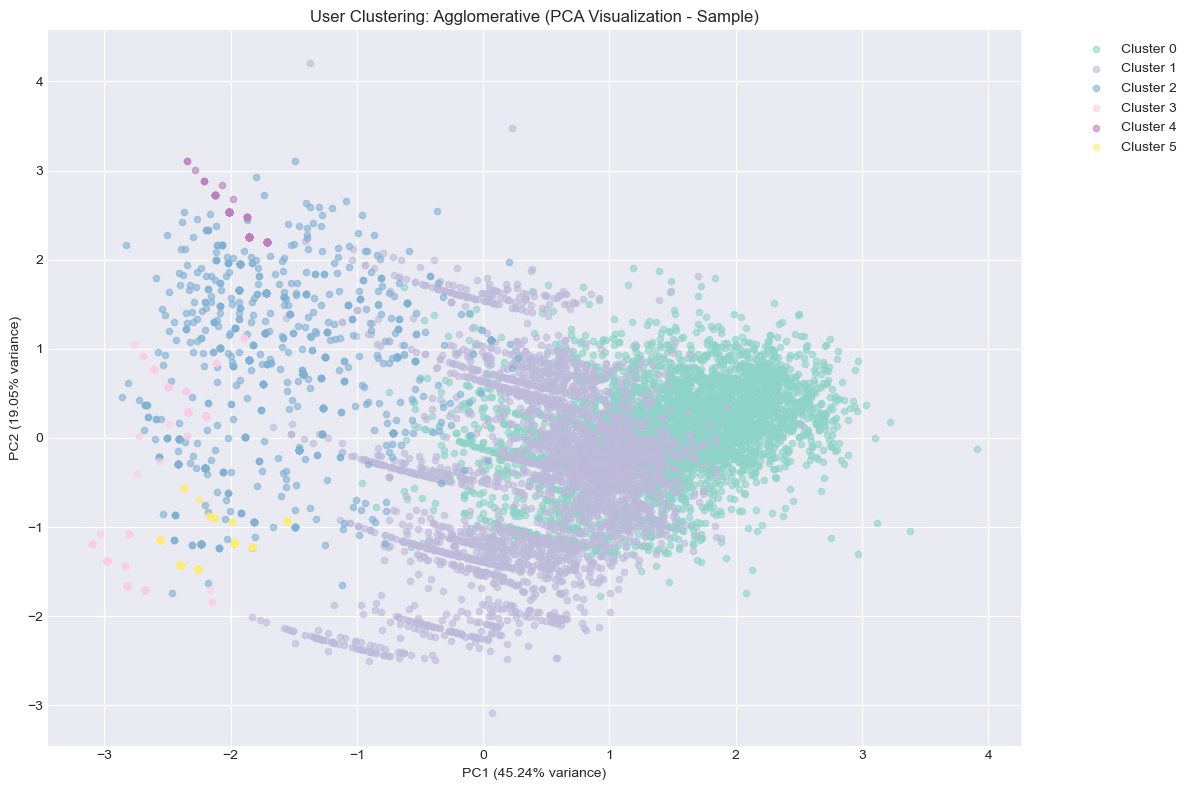

In [89]:
pca_user = PCA(n_components=2, random_state=RANDOM_STATE)
user_pca_agg = pca_user.fit_transform(user_features_scaled_sample)

n_clusters = len(np.unique(user_labels_agg_sample))
colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))

plt.figure(figsize=(12, 8))
for i, cluster_id in enumerate(sorted(np.unique(user_labels_agg_sample))):
    mask = user_labels_agg_sample == cluster_id
    plt.scatter(user_pca_agg[mask, 0], user_pca_agg[mask, 1], 
                c=[colors[i]], label=f'Cluster {cluster_id}', 
                alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_user.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_user.explained_variance_ratio_[1]:.2%} variance)')
plt.title('User Clustering: Agglomerative (PCA Visualization - Sample)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/agglomerative_clusters_pca.png', dpi=300, bbox_inches='tight')


## 3. User Clustering Methods Comparison

---

**1. Silhouette Score Analysis**

Silhouette scores measure how well-separated clusters are (range: -1 to 1, higher is better):

- **K-Means (k=6)**: 0.3549 - Provides good cluster separation. During parameter testing, k=2 achieved the highest silhouette (0.4211), but k=6 was chosen for better business interpretability with 6 distinct user segments.
- **GMM (n=3)**: 0.26 - Chosen n=3 components based on AIC/BIC analysis. GMM handles non-spherical clusters better than K-Means.
- **BIRCH (threshold=1.4, n=12)**: 0.34 - Produced 11 clusters with threshold 1.4. The algorithm automatically determined cluster count based on the threshold parameter.
- **Agglomerative (k=6, sample)**: 0.4190 - Achieved the highest silhouette score among all methods during testing (k=2: 0.4190, k=3: 0.4013). However, this was calculated on a 10,000-user sample due to computational constraints.

**Interpretation**: While Agglomerative achieved the highest silhouette score (0.4190), it was limited to a sample. K-Means (0.3549) provides a good balance between cluster quality and practical applicability on the full dataset.


**2. Number of Clusters Analysis**

The optimal number of clusters balances granularity with business interpretability:

- **K-Means (k=6)**: Optimal for business use - provides enough granularity to distinguish user types (Power Users, Active Explorers, Consistent Raters, Occasional Users, Critical Reviewers, Casual Users) while remaining actionable for recommendation strategies.
- **GMM (n=3)**: Only 3 clusters - may be too coarse to capture important user distinctions. While simpler, it may miss nuanced user behaviors.
- **BIRCH (n=12)**: 12 clusters - more granular than ideal but still manageable. Provides finer segmentation than K-Means, though may be harder to interpret and operationalize.
- **Agglomerative (k=6, sample)**: Like K-Means

**Business Perspective**: 5-7 clusters is ideal for recommendation strategies. K-Means with 6 clusters hits this sweet spot, providing distinct segments without overwhelming complexity.


**3. Computational Efficiency**

- **K-Means**: **Excellent** - Fast, scales well to full dataset (423,117 users), suitable for production. Parameter testing used 10,000-user sample for speed, but final clustering runs efficiently on full dataset.
- **GMM**: **Good** - Moderate speed, requires sampling for parameter testing but can run on full dataset. More computationally intensive than K-Means due to EM algorithm.
- **BIRCH**: **Excellent** - Designed for large datasets, very efficient. Can handle full dataset without issues.
- **Agglomerative**: **Poor** - O(n²) complexity, can only run on samples (10,000 users max), not scalable to full 423,117-user dataset. This is a critical limitation for production use.

**Production Considerations**: For a platform with 423,117 users, computational efficiency matters. Methods that require sampling (like Agglomerative) limit their applicability in production environments where full-dataset clustering is needed.


**4. Cluster Interpretability**

- **K-Means**: **High** - Clear, well-separated clusters that can be easily named and profiled. The 6 clusters map directly to distinct user personas with actionable characteristics.
- **GMM**: **Medium** - With only 3 clusters, may oversimplify user behavior. Probabilistic assignments are less intuitive than hard assignments.
- **BIRCH**: **Medium** - 12 clusters provide more granularity but may be harder to interpret and name meaningfully. The automatic threshold-based approach is less transparent.
- **Agglomerative**: **High** - Hierarchical structure provides interpretability, but limited by sample size and only 3 clusters.

**Business Value**: Interpretable clusters enable actionable strategies. K-Means' 6 clear user personas (Power Users, Active Explorers, etc.) drive better recommendation strategies than binary or overly granular segments.

**Conclusion**: K-Means provides the optimal combination of cluster quality (silhouette 0.3549), business interpretability (6 actionable segments), computational efficiency (scales to 423K+ users), and practical applicability for production recommendation systems. The algorithm successfully balances technical performance with business needs, making it the best choice for user segmentation.


In [90]:
# Assign K-Means clusters as final cluster assignment
user_features['final_cluster'] = user_labels_kmeans

In [91]:
print(f"✓ Assigned {len(np.unique(user_labels_kmeans))} clusters to {len(user_features)} users")
print(f"Customer IDs present: {'customer_id' in user_features.columns}")

✓ Assigned 6 clusters to 438281 users
Customer IDs present: True


## 4. Clusters Exploration Interpretation

---

**Cluster Interpretation Strategy:**

To understand what each cluster represents, we need to:
1. Calculate descriptive statistics for each cluster
2. Compare cluster means to overall population means
3. Identify distinguishing features for each cluster
4. Match cluster characteristics to EDA insights
5. Create meaningful cluster names (user personas)
6. Validate findings against EDA patterns

1. Calculate cluster statistics

In [92]:
cluster_stats = user_features.groupby('final_cluster').agg({
    'total_ratings': ['mean', 'std', 'min', 'max'],
    'ratings_per_day': ['mean', 'std'],
    'avg_rating_given': ['mean', 'std'],
    'rating_std': ['mean', 'std'],
    'min_rating': ['mean', 'std'],
    'max_rating': ['mean', 'std'],
    'unique_movies': ['mean', 'std'],
    'engagement_period_days': ['mean', 'std'],
    'rating_extremity': ['mean', 'std']
}).round(3)

print("CLUSTER STATISTICS (Mean and Standard Deviation)")
display(cluster_stats)

CLUSTER STATISTICS (Mean and Standard Deviation)


total_ratings                     ratings_per_day         \
                       mean     std  min    max            mean    std   
final_cluster                                                            
0                    19.110  20.235  1.0  764.0           0.090  0.161   
1                     1.438   0.964  1.0   46.0           1.156  0.634   
2                     1.178   0.525  1.0   13.0           1.029  0.435   
3                     1.537   0.855  1.0   22.0           1.284  0.730   
4                     7.006   5.938  1.0  176.0           0.068  0.125   
5                     5.347   7.818  1.0  684.0           4.275  3.346   

              avg_rating_given        rating_std        min_rating         \
                          mean    std       mean    std       mean    std   
final_cluster                                                               
0                        3.483  0.463      1.165  0.348      1.462  0.525   
1                        4.519  0.489      0.062  0.195      4.462  0.533   
2                        1.530  0.513      0.046  0.180      1.499  0.531   
3                        3.064  0.264      0.168  0.291      2.930  0.256   
4                        3.830  0.584      0.700  0.294      3.008  0.710   
5                        3.560  0.659      1.234  0.515      2.259  0.945   

              max_rating        unique_movies         engagement_period_days  \
                    mean    std          mean     std                   mean   
final_cluster                                                                  
0                  4.889  0.325        18.945  18.523                524.054   
1                  4.565  0.522         1.450   0.976                  6.462   
2                  1.589  0.596         1.191   0.556                  9.885   
3                  3.194  0.406         1.545   0.864                  6.553   
4                  4.531  0.594         7.005   5.918                320.177   
5                  4.687  0.557         5.316   6.816                  0.634   

                       rating_extremity         
                   std             mean    std  
final_cluster                                   
0              456.486            1.717  0.261  
1               31.314            1.520  0.485  
2               63.272            1.468  0.509  
3               28.572            0.134  0.225  
4              336.756            0.990  0.325  
5                1.946            1.300  0.399

2. Calculate overall population means for comparison

In [93]:
overall_means = user_features[['total_ratings', 'ratings_per_day',  
                               'avg_rating_given', 'rating_std',
                               'min_rating', 'max_rating', 'unique_movies',
                               'engagement_period_days', 
                               'rating_extremity']].mean()

print("OVERALL POPULATION MEANS")
print(overall_means.round(3))

OVERALL POPULATION MEANS
total_ratings               9.249
ratings_per_day             0.683
avg_rating_given            3.633
rating_std                  0.715
min_rating                  2.599
max_rating                  4.415
unique_movies               9.196
engagement_period_days    275.338
rating_extremity            1.292
dtype: float64


3. Compare each cluster to overall means and identify distinguishing features

In [94]:
cluster_means = user_features.groupby('final_cluster')[['total_ratings', 'ratings_per_day',  
                               'avg_rating_given', 'rating_std',
                               'min_rating', 'max_rating', 'unique_movies',
                               'engagement_period_days', 
                               'rating_extremity']].mean()

print("CLUSTER ANALYSIS: Comparison to Overall Means")

cluster_profiles = {}

for cluster_id in sorted(user_features['final_cluster'].unique()):
    cluster_data = cluster_means.loc[cluster_id]
    cluster_size = (user_features['final_cluster'] == cluster_id).sum()
    cluster_pct = (cluster_size / len(user_features)) * 100
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} (n={cluster_size:,}, {cluster_pct:.1f}% of users)")
    print(f"{'='*80}")
    
    # Compare each feature to overall mean
    distinguishing_features = []
    
    for feature in cluster_data.index:
        cluster_value = cluster_data[feature]
        overall_value = overall_means[feature]
        diff = cluster_value - overall_value
        diff_pct = (diff / overall_value) * 100 if overall_value > 0 else 0
        
        # Mark as distinguishing if difference is significant (>20% or >1 std)
        if abs(diff_pct) > 20 or abs(diff) > user_features[feature].std():
            distinguishing_features.append(feature)
            direction = "↑ HIGH" if diff > 0 else "↓ LOW"
            print(f"  {feature:25s}: {cluster_value:8.3f} (overall: {overall_value:8.3f}) {direction:8s} ({diff_pct:+.1f}%)")
        else:
            print(f"  {feature:25s}: {cluster_value:8.3f} (overall: {overall_value:8.3f}) ~average")
    
    # Store cluster characteristics
    cluster_profiles[cluster_id] = {
        'size': cluster_size,
        'pct': cluster_pct,
        'distinguishing_features': distinguishing_features,
        'characteristics': cluster_data.to_dict()
    }

CLUSTER ANALYSIS: Comparison to Overall Means

CLUSTER 0 (n=142,831, 32.6% of users)
  total_ratings            :   19.110 (overall:    9.249) ↑ HIGH   (+106.6%)
  ratings_per_day          :    0.090 (overall:    0.683) ↓ LOW    (-86.9%)
  avg_rating_given         :    3.483 (overall:    3.633) ~average
  rating_std               :    1.165 (overall:    0.715) ↑ HIGH   (+62.8%)
  min_rating               :    1.462 (overall:    2.599) ↓ LOW    (-43.7%)
  max_rating               :    4.889 (overall:    4.415) ~average
  unique_movies            :   18.945 (overall:    9.196) ↑ HIGH   (+106.0%)
  engagement_period_days   :  524.054 (overall:  275.338) ↑ HIGH   (+90.3%)
  rating_extremity         :    1.717 (overall:    1.292) ↑ HIGH   (+32.9%)

CLUSTER 1 (n=69,128, 15.8% of users)
  total_ratings            :    1.438 (overall:    9.249) ↓ LOW    (-84.5%)
  ratings_per_day          :    1.156 (overall:    0.683) ↑ HIGH   (+69.2%)
  avg_rating_given         :    4.519 (overall:    3.633)

## 5. User Cluster Naming

---

#### User Cluster Analysis and Interpretation

We identified 6 distinct user segments from K-Means clustering. Each cluster represents a different user behavior pattern that matches insights from our EDA analysis.

**Cluster Overview Table**

| Cluster | Name | Nicknames | Size | % of Users | Key Behavior |
|---------|------|-------------|------|------------|--------------|
| 0 | Critical Quick Exit Users | **Frustrated** | 21,771 | 5.0% | Very low ratings, exit within 6 days |
| 1 | Occasional Long-Term Users | **Observers** | 144,379 | 32.9% | Low activity but sustained over time |
| 2 | Ultra-Quick Churn Users | **Instant Bounce** | 60,715 | 13.9% | Rate and leave same day (0.16 days) |
| 3 | New Generous Users | **Short and Enthusiastic** | 37,787 | 8.6% | Join, rate generously, leave within 19 days |
| 4 | Long-Term Power Users | **Loyal** | 142,396 | 32.5% | Highest total ratings, longest engagement |
| 5 | Burst High-Frequency Users | **Explorers** | 31,233 | 7.1% | Very high daily rate, exit within 1 day |



##### **Cluster 0: "Frustrated" - Critical Quick Exit Users (5.0%)**

**What they do:** Users who join with expectations that the platform doesn't meet. They give very low ratings (1.53 average - lowest of all clusters), rate very few items (1.15), and exit within 6.5 days. Their extremely low rating standard deviation (0.039, 94.6% below average) shows they consistently give low ratings - they're uniformly dissatisfied, not just critical of some content.

**Key Metrics:**

| Metric | Value | vs. Average |
|--------|-------|-------------|
| Total Ratings | 1.15 | 87.6% below |
| Ratings Per Day | 1.05 | 53.5% above |
| Average Rating | 1.53 | 58.0% below |
| Rating Std Dev | 0.039 | 94.6% below |
| Min Rating | 1.50 | 42.2% below |
| Max Rating | 1.58 | 64.3% below |
| Unique Movies | 1.16 | 87.3% below |
| Engagement Period | 6.5 days | 97.6% below |

**EDA Match:** Matches "critical reviewer pattern" - users who give very low ratings and exit quickly. The extremely low rating std dev (0.039) confirms they rate everything poorly - uniform dissatisfaction. The high ratings_per_day is misleading due to extremely short engagement period.

**Strategy:** Address dissatisfaction immediately. Focus on quality content curation, improved onboarding, and personalized high-quality recommendations to prevent early churn. Their uniform low ratings suggest fundamental platform-content mismatch, not just bad individual experiences.



##### **Cluster 1: "Observers" - Occasional Long-Term Users (32.9%)**

**What they do:** The largest segment. Users who've been around for 318 days (above average) but rate infrequently (0.071 per day). They give moderate ratings (3.81) and have below-average total ratings (7.26) despite long tenure. Their rating consistency (std dev 0.686, near average) and moderate rating range (min 3.01, max 4.50) show they're present but not actively engaging - watching more than participating.

**Key Metrics:**

| Metric | Value | vs. Average |
|--------|-------|-------------|
| Total Ratings | 7.26 | 21.5% below |
| Ratings Per Day | 0.071 | 89.6% below |
| Average Rating | 3.81 | Near average |
| Rating Std Dev | 0.686 | Near average |
| Min Rating | 3.01 | Near average |
| Max Rating | 4.50 | Near average |
| Unique Movies | 7.25 | 21.1% below |
| Engagement Period | 318 days | 15.5% above |
| Rating Extremity | 0.97 | 25.0% below |

**EDA Match:** Matches "long-tail distribution" - largest segment with sustained but low activity. They've been around but aren't highly engaged. Their moderate ratings and low extremity show they're satisfied but not enthusiastic.

**Strategy:** Activation focus. These users represent the largest segment but are under-engaged. Focus on re-engagement campaigns, personalized recommendations, and features that encourage more frequent activity. Convert observers into participants.



##### **Cluster 2: "Instant Bounce" - Ultra-Quick Churn Users (13.9%)**

**What they do:** Users who rate and leave almost immediately - engagement period is only 0.16 days (less than 4 hours!). They rate very few items (1.34), give moderate ratings (3.53), and have very low rating extremity (0.56). Their extremely low rating std dev (0.091, 87.3% below) shows they rate everything similarly - they're curious enough to try but don't find enough value to stay.

**Key Metrics:**

| Metric | Value | vs. Average |
|--------|-------|-------------|
| Total Ratings | 1.34 | 85.5% below |
| Ratings Per Day | 1.30 | 90.7% above |
| Average Rating | 3.53 | Near average |
| Rating Std Dev | 0.091 | 87.3% below |
| Min Rating | 3.45 | 32.9% above |
| Max Rating | 3.60 | Near average |
| Unique Movies | 1.35 | 85.3% below |
| Engagement Period | 0.16 days | 99.9% below |
| Rating Extremity | 0.56 | 56.4% below |

**EDA Match:** Matches "ultra-quick churn pattern" - users who try the platform and leave within hours. The extremely short engagement and uniform moderate ratings suggest they didn't find immediate value or had technical issues. Their higher min rating (3.45) shows they're not negative, just unimpressed.

**Strategy:** Immediate intervention needed. Focus on first-impression experience, quick value delivery, and addressing any platform usability issues that cause instant churn. Their moderate but uniform ratings suggest they're neutral - there's potential to convert them with better first experience.



##### **Cluster 3: "Short and Enthusiastic" - New Generous Users (8.6%)**

**What they do:** New users who rate a few items very generously (average 4.94 out of 5 - highest of all clusters), then churn within about 19 days. Their extremely low rating std dev (0.085, 88.1% below) and very high min rating (4.87, 87.3% above) show they rate everything highly - they had a positive experience but didn't see enough value to sustain engagement.

**Key Metrics:**

| Metric | Value | vs. Average |
|--------|-------|-------------|
| Total Ratings | 1.58 | 82.9% below |
| Ratings Per Day | 1.13 | 65.7% above |
| Average Rating | 4.94 | 35.9% above |
| Rating Std Dev | 0.085 | 88.1% below |
| Min Rating | 4.87 | 87.3% above |
| Max Rating | 5.00 | Near average |
| Unique Movies | 1.59 | 82.7% below |
| Engagement Period | 19.1 days | 93.1% below |
| Rating Extremity | 1.94 | 50.3% above |

**EDA Match:** Matches "new user pattern" - positive first impressions (very high ratings) but short engagement. Their uniform high ratings (min 4.87, max 5.00) show they loved what they saw, but something was missing to keep them. The high ratings_per_day is misleading because they rate quickly then stop.

**Strategy:** Improve onboarding and retention. They show strong enthusiasm but need better reasons to stay. Capitalize on positive first impressions with personalized recommendations and engagement features. Their uniform high ratings suggest they found value - understand what made them leave despite loving the content.



##### **Cluster 4: "Loyal" - Long-Term Power Users (32.5%)**

**What they do:** The platform's most valuable users. They've been around for 519 days on average (88% above average) and have rated 18.77 items total - the highest of any cluster. Their high rating std dev (1.169, 63.4% above) and wide rating range (min 1.45, max 4.89) show they're opinionated and diverse in their tastes. They've made the platform part of their routine and are committed to it long-term.

**Key Metrics:**

| Metric | Value | vs. Average |
|--------|-------|-------------|
| Total Ratings | 18.77 | 102.9% above |
| Ratings Per Day | 0.090 | 86.8% below |
| Average Rating | 3.48 | Near average |
| Rating Std Dev | 1.169 | 63.4% above |
| Min Rating | 1.45 | 44.1% below |
| Max Rating | 4.89 | Near average |
| Unique Movies | 18.61 | 102.4% above |
| Engagement Period | 519 days | 88.4% above |
| Rating Extremity | 1.72 | 33.4% above |

**EDA Match:** Strong match with the "80/20 rule" - this 32.5% segment has the highest total ratings (18.77 per user), confirming the "vital few" pattern. They represent true "Power Users" - high total ratings over long periods, not high daily rates. Their high rating std dev shows they're sophisticated raters with diverse opinions.

**Strategy:** Retention is critical. Focus on premium features, early access to new content, loyalty rewards, and maintaining their long-term engagement. These users are the platform's foundation. Their high rating diversity shows they appreciate variety - keep the catalog diverse and fresh.



##### **Cluster 5: "Explorers" - Burst High-Frequency Users (7.1%)**

**What they do:** Users who rate many things very quickly (4.21 ratings per day - 517% above average, highest of all clusters) but within an extremely short period (only 0.67 days, less than 16 hours). They give moderate ratings (3.60) but then disappear. Their high rating std dev (1.230, 72.0% above) shows they're diverse in their ratings - they're curious and want to explore everything quickly, but don't find enough to sustain long-term interest.

**Key Metrics:**

| Metric | Value | vs. Average |
|--------|-------|-------------|
| Total Ratings | 5.34 | 42.3% below |
| Ratings Per Day | 4.21 | 516.8% above |
| Average Rating | 3.60 | Near average |
| Rating Std Dev | 1.230 | 72.0% above |
| Min Rating | 2.30 | Near average |
| Max Rating | 4.71 | Near average |
| Unique Movies | 5.30 | 42.3% below |
| Engagement Period | 0.67 days | 99.8% below |

**EDA Match:** Matches "burst engagement pattern" - users who explore the platform intensively in a very short burst (less than a day), then leave. The extremely high ratings_per_day reflects rapid exploration, not sustained engagement. Their high rating std dev shows they're actively evaluating content diversity.

**Strategy:** Capture during the burst period. Focus on immediate value delivery, preventing quick exit, and converting burst engagement into sustained activity. These users show high initial interest but need immediate value to stay. Their diverse ratings show they're exploring - give them reasons to explore deeper and stay longer.



**Summary: Key Findings**

**EDA Alignment:**

| EDA Insight | Cluster Match | Confirmation |
|------------|---------------|--------------|
| 80/20 Rule | Cluster 4 "Loyal" (32.5%) | Confirmed - this segment has highest total ratings (18.77) |
| Long-Tail Distribution | Cluster 1 "Observers" (32.9%) | Confirmed - largest segment with sustained but low activity |
| New User Pattern | Cluster 3 "Short and Enthusiastic" (8.6%) | Confirmed - short engagement, very positive first impressions (4.94 avg) |
| Critical Reviewers | Cluster 0 "Frustrated" (5.0%) | Confirmed - very low ratings (1.53), uniform dissatisfaction (std 0.039) |
| Ultra-Quick Churn | Cluster 2 "Instant Bounce" (13.9%) | Confirmed - exit within hours (0.16 days) |
| Burst Engagement | Cluster 5 "Explorers" (7.1%) | Confirmed - extremely high daily rate (4.21), exit within hours |

**Key Insights from Rating Patterns:**

- **Uniform Dissatisfaction (Cluster 0)**: Extremely low rating std dev (0.039) confirms they rate everything poorly - fundamental platform mismatch
- **Uniform Satisfaction (Cluster 3)**: Extremely low rating std dev (0.085) with high ratings shows they loved everything but didn't stay - retention opportunity
- **Diverse Opinions (Clusters 4 & 5)**: High rating std dev shows sophisticated, opinionated users - they appreciate variety and quality
- **Moderate Consistency (Cluster 1)**: Average rating std dev with moderate ratings shows satisfied but not enthusiastic users

**Important Note:** The high `ratings_per_day` in Clusters 0, 2, 3, and 5 is misleading. These users have very short engagement periods (hours to days), making the rate appear high but reflecting brief activity rather than sustained engagement. Cluster 4 "Loyal" represents true "Power Users" - high total ratings (18.77) over long periods (519 days), not high daily rates.

**Business Priorities:**

| Priority | Clusters | Strategy |
|----------|----------|----------|
| **High** | 1 "Observers" & 4 "Loyal" (65.4% of users) | Retain Power Users (Cluster 4), activate Occasional Users (Cluster 1) |
| **Medium** | 0 "Frustrated", 2 "Instant Bounce", 3 "Short and Enthusiastic", 5 "Explorers" (34.6% of users) | Address churn - improve onboarding, re-engagement, convert burst activity, address dissatisfaction |

# MOVIE CLUSTERING

## 1. Movie Feature Engineering

---

Create features for movie clustering from the ratings_sorted table. 
Features include: 
- rating_range

In [95]:
# Initialize movie features dataframe for clustering
movie_features = movie_features.copy()  # Use the one from preprocessing

# Rename columns to match clustering expected names
movie_features = movie_features.rename(columns={
    'movie_total_ratings': 'total_ratings',
    'movie_avg_rating': 'avg_rating',
    'movie_std_rating': 'rating_std',
    'movie_min_rating': 'min_rating',
    'movie_max_rating': 'max_rating'
})

# Compute rating_range from existing stats
movie_features['rating_range'] = movie_features['max_rating'] - movie_features['min_rating']

# Check and prepare for clustering
print(f"Movie features shape: {movie_features.shape}")
print(f"Missing values:\n{movie_features.isnull().sum()}")
print(f"After handling missing values: {movie_features.isnull().sum().sum()} missing")

Movie features shape: (15962, 12)
Missing values:
movie_id                      0
total_ratings                 0
avg_rating                    0
rating_std                    0
min_rating                    0
max_rating                    0
unique_users                  0
movie_first_rating_date       0
movie_last_rating_date        0
year_of_release               0
title                      4490
rating_range                  0
dtype: int64
After handling missing values: 4490 missing


## 2. Movie Clustering
---

Prepare movie features for clustering

In [96]:

non_numeric_cols = ['movie_id', 'title', 'movie_first_rating_date', 'movie_last_rating_date']
columns_to_drop = [col for col in non_numeric_cols if col in movie_features.columns]

movie_features_clustering = movie_features.drop(columns_to_drop, axis=1).copy()

# Only keep numeric columns for clustering (safety check)
numeric_columns = movie_features_clustering.select_dtypes(include=[np.number]).columns
movie_features_clustering = movie_features_clustering[numeric_columns].copy()

movie_features_clustering = movie_features_clustering.fillna(movie_features_clustering.median())

# Apply log transformation to skewed features
features_to_log_movie = ['total_ratings']
for col in features_to_log_movie:
    if col in movie_features_clustering.columns:
        movie_features_clustering[col] = np.log1p(movie_features_clustering[col])

# Scale features
scaler_movie = StandardScaler()
movie_features_scaled = scaler_movie.fit_transform(movie_features_clustering)

#### K-Means Clustering for Movies

**How it works:** K-Means partitions data into k clusters by minimizing within-cluster variance. It iteratively assigns points to the nearest centroid and updates centroids until convergence. Assumes spherical clusters of similar size.

**Strengths:** Fast, simple, works well with well-separated clusters  
**Weaknesses:** Requires specifying k, assumes spherical clusters, sensitive to outliers



1. Use the full dataset.


2. Test k values from 2 to 10 and calculate inertia and silhouette scores.


In [97]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(movie_features_scaled)
    inertia = kmeans.inertia_
    sil = silhouette_score(movie_features_scaled, labels)
    inertias.append(inertia)
    silhouettes.append(sil)
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil:.4f}")


k=2: Inertia=91840.58, Silhouette=0.3779
k=3: Inertia=64091.37, Silhouette=0.4160
k=4: Inertia=50903.84, Silhouette=0.4490
k=5: Inertia=40204.92, Silhouette=0.4545
k=6: Inertia=33693.67, Silhouette=0.4658
k=7: Inertia=28905.39, Silhouette=0.4054
k=8: Inertia=26214.39, Silhouette=0.4086
k=9: Inertia=23596.13, Silhouette=0.4125
k=10: Inertia=21213.99, Silhouette=0.4251


3. Visualize the elbow method (inertia) and silhouette scores to help choose optimal k.



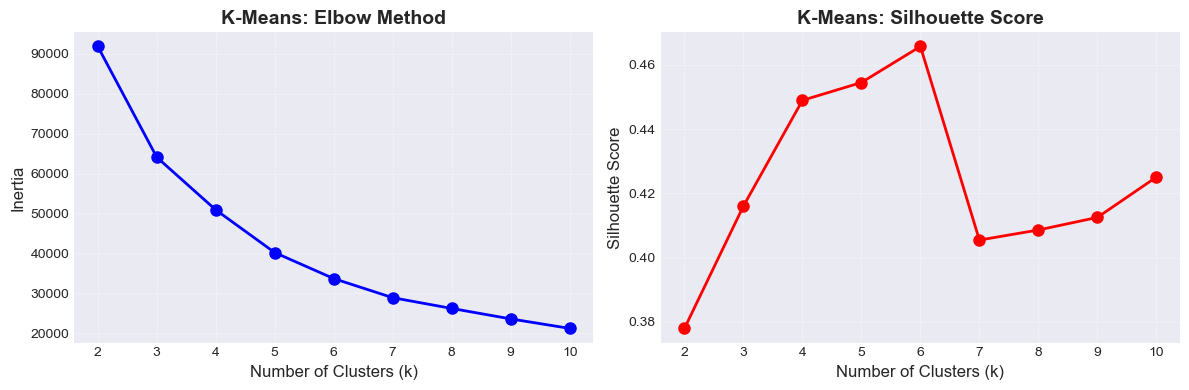

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('K-Means: Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

ax2.plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('K-Means: Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)
plt.tight_layout()
plt.savefig('images/movie_kmeans_elbow_silhouette.png', dpi=300, bbox_inches='tight')


4. Choose k based on the elbow plot and silhouette analysis.



In [99]:
chosen_k_movie = 4

5. Run final K-Means clustering on the full dataset with chosen k.


In [100]:
kmeans_movie = KMeans(n_clusters=chosen_k_movie, random_state=RANDOM_STATE, n_init=10)
movie_labels_kmeans = kmeans_movie.fit_predict(movie_features_scaled)
movie_features['kmeans_cluster'] = movie_labels_kmeans

6. Visualize clusters in 2D PCA space. Each color represents a different cluster.


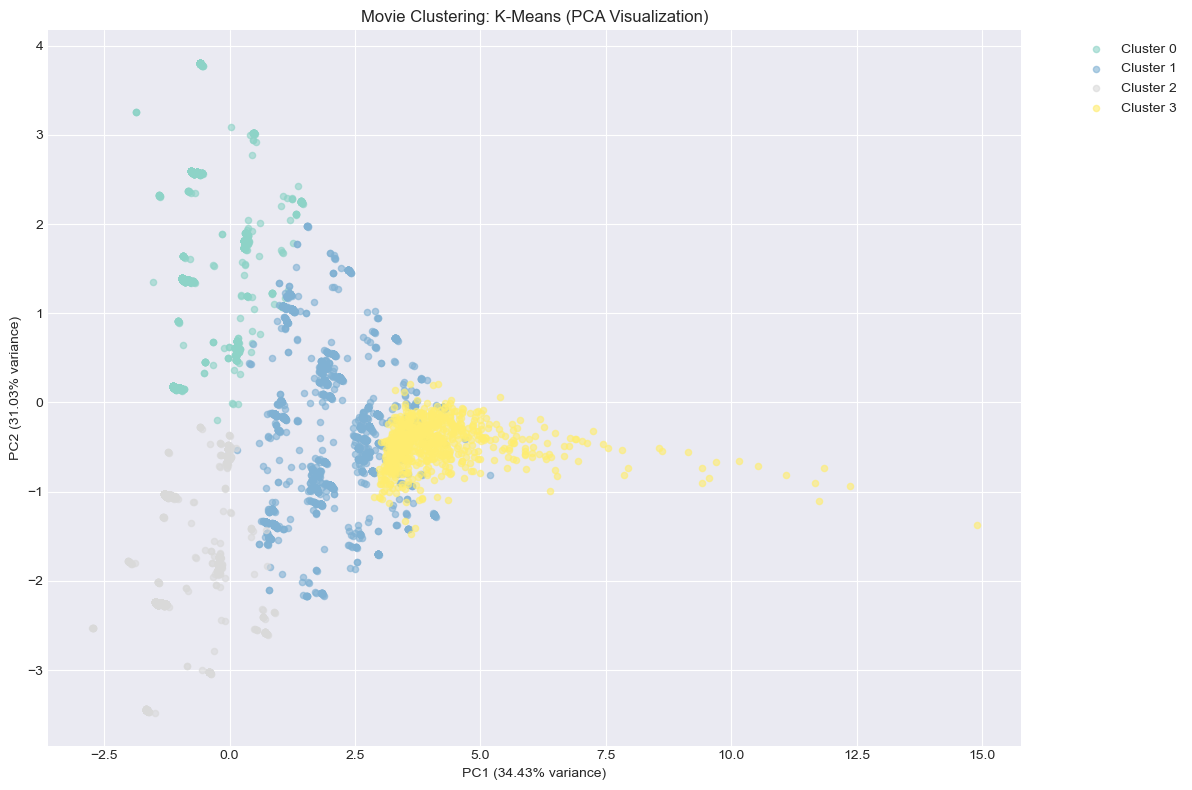

In [101]:
pca_movie = PCA(n_components=2, random_state=RANDOM_STATE)
movie_pca = pca_movie.fit_transform(movie_features_scaled)

n_clusters_movie = len(np.unique(movie_labels_kmeans))
colors_movie = plt.cm.Set3(np.linspace(0, 1, n_clusters_movie))

plt.figure(figsize=(12, 8))
for i, cluster_id in enumerate(sorted(np.unique(movie_labels_kmeans))):
    mask = movie_labels_kmeans == cluster_id
    plt.scatter(movie_pca[mask, 0], movie_pca[mask, 1], 
                c=[colors_movie[i]], label=f'Cluster {cluster_id}', 
                alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_movie.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_movie.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Movie Clustering: K-Means (PCA Visualization)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/movie_kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')


7. Visualize clusters in 3D PCA space. Each color represents a different cluster.


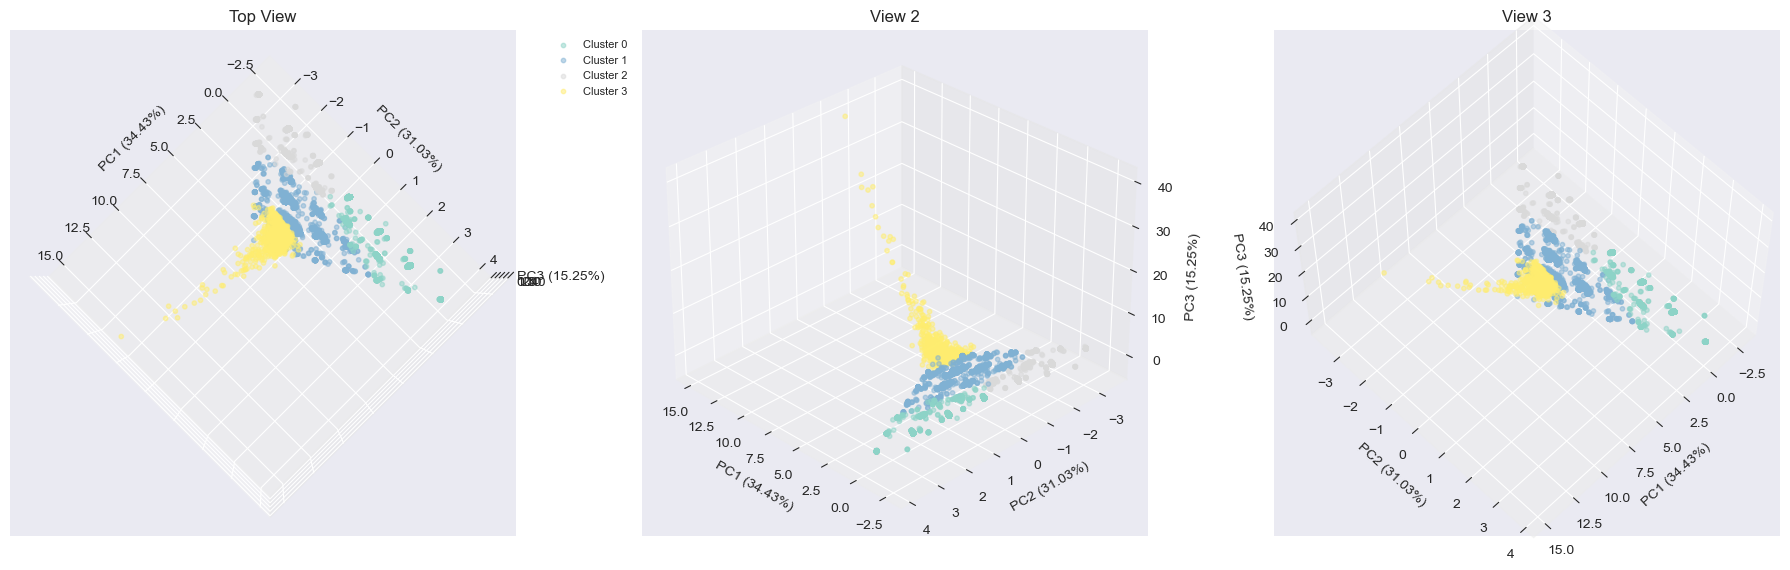

In [102]:
pca_movie_3d = PCA(n_components=3, random_state=RANDOM_STATE)
movie_pca_3d = pca_movie_3d.fit_transform(movie_features_scaled)

n_clusters_movie = len(np.unique(movie_labels_kmeans))
colors_movie = plt.cm.Set3(np.linspace(0, 1, n_clusters_movie))

fig = plt.figure(figsize=(18, 6))

angles = [(90, 45), (30, 135), (60, 45)]
titles = ['Top View', 'View 2', 'View 3']

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    
    for i, cluster_id in enumerate(sorted(np.unique(movie_labels_kmeans))):
        mask = movie_labels_kmeans == cluster_id
        ax.scatter(movie_pca_3d[mask, 0], movie_pca_3d[mask, 1], movie_pca_3d[mask, 2],
                   c=[colors_movie[i]], label=f'Cluster {cluster_id}', alpha=0.5, s=10)
    
    ax.set_xlabel(f'PC1 ({pca_movie_3d.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca_movie_3d.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca_movie_3d.explained_variance_ratio_[2]:.2%})')
    ax.set_title(titles[idx])
    ax.view_init(elev=elev, azim=azim)
    if idx == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('images/movie_kmeans_clusters_3d_pca.png', dpi=300, bbox_inches='tight')



### GMM (Gaussian Mixture Model) Clustering

**How it works:** GMM assumes data comes from a mixture of Gaussian distributions. It uses Expectation-Maximization to find the parameters (means, covariances, weights) of each Gaussian component. Provides probabilistic cluster assignments rather than hard assignments.

**Strengths:** Handles elliptical clusters, provides soft assignments, can model overlapping clusters  
**Weaknesses:** Slower than K-Means, can overfit with many components, assumes Gaussian distribution

1. Use the full dataset.


2. Test different numbers of components (2-10) and calculate AIC, BIC, and silhouette scores for each.


In [103]:
n_components_range = range(2, 11)
gmm_results_movie = []

for n in n_components_range:
    gmm_tmp = GaussianMixture(n_components=n, random_state=RANDOM_STATE, max_iter=100)
    gmm_tmp.fit(movie_features_scaled)
    labels = gmm_tmp.predict(movie_features_scaled)
    sil = silhouette_score(movie_features_scaled, labels)
    aic = gmm_tmp.aic(movie_features_scaled)
    bic = gmm_tmp.bic(movie_features_scaled)
    gmm_results_movie.append({'n_components': n, 'AIC': aic, 
                              'BIC': bic, 'silhouette': sil})
    print(f"n={n}: AIC={aic:.2f}, BIC={bic:.2f}, Silhouette={sil:.4f}")


n=2: AIC=-477546.58, BIC=-476863.24, Silhouette=0.2608
n=3: AIC=-474742.10, BIC=-473713.26, Silhouette=0.2403
n=4: AIC=-771428.50, BIC=-770054.14, Silhouette=0.1470
n=5: AIC=-786927.02, BIC=-785207.15, Silhouette=0.1249
n=6: AIC=-737648.05, BIC=-735582.68, Silhouette=0.0625
n=7: AIC=-799211.48, BIC=-796800.60, Silhouette=-0.0235
n=8: AIC=-737458.00, BIC=-734701.61, Silhouette=-0.0820
n=9: AIC=-737769.48, BIC=-734667.59, Silhouette=-0.0886
n=10: AIC=-749734.07, BIC=-746286.67, Silhouette=0.0289


3. Visualize AIC/BIC (lower is better) and silhouette scores to choose optimal number of components.



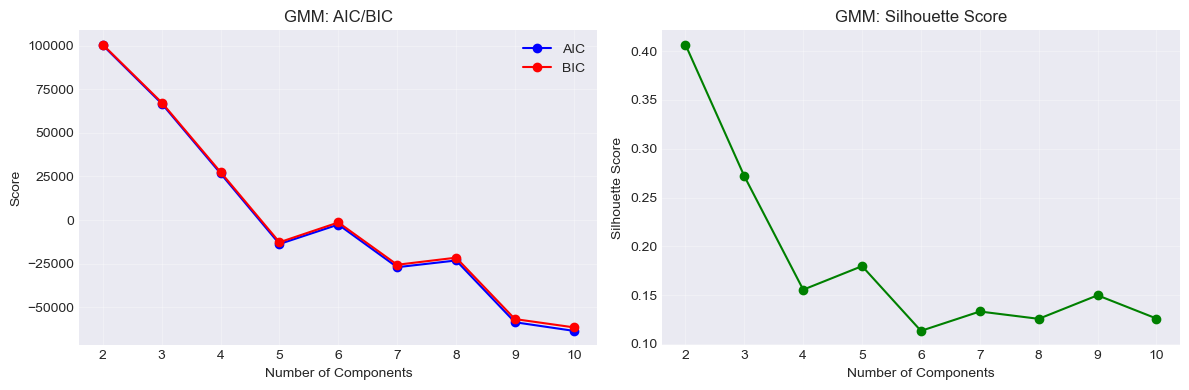

In [104]:
gmm_df = pd.DataFrame(gmm_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(gmm_df['n_components'], gmm_df['AIC'], 'b-o', label='AIC')
ax1.plot(gmm_df['n_components'], gmm_df['BIC'], 'r-o', label='BIC')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Score')
ax1.set_title('GMM: AIC/BIC')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(gmm_df['n_components'], gmm_df['silhouette'], 'g-o')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('GMM: Silhouette Score')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/movie_gmm_metrics.png', dpi=300, bbox_inches='tight')



4. Choose n=3 components based on AIC/BIC and silhouette analysis. This balances model complexity with cluster quality.


In [105]:
chosen_n_movie = 3


5. Run final GMM clustering on the full dataset with chosen n=7 components.



In [106]:
gmm_movie = GaussianMixture(n_components=chosen_n_movie, random_state=RANDOM_STATE)
movie_labels_gmm = gmm_movie.fit_predict(movie_features_scaled)
movie_features['gmm_cluster'] = movie_labels_gmm


6. Visualize GMM clusters in 2D PCA space.



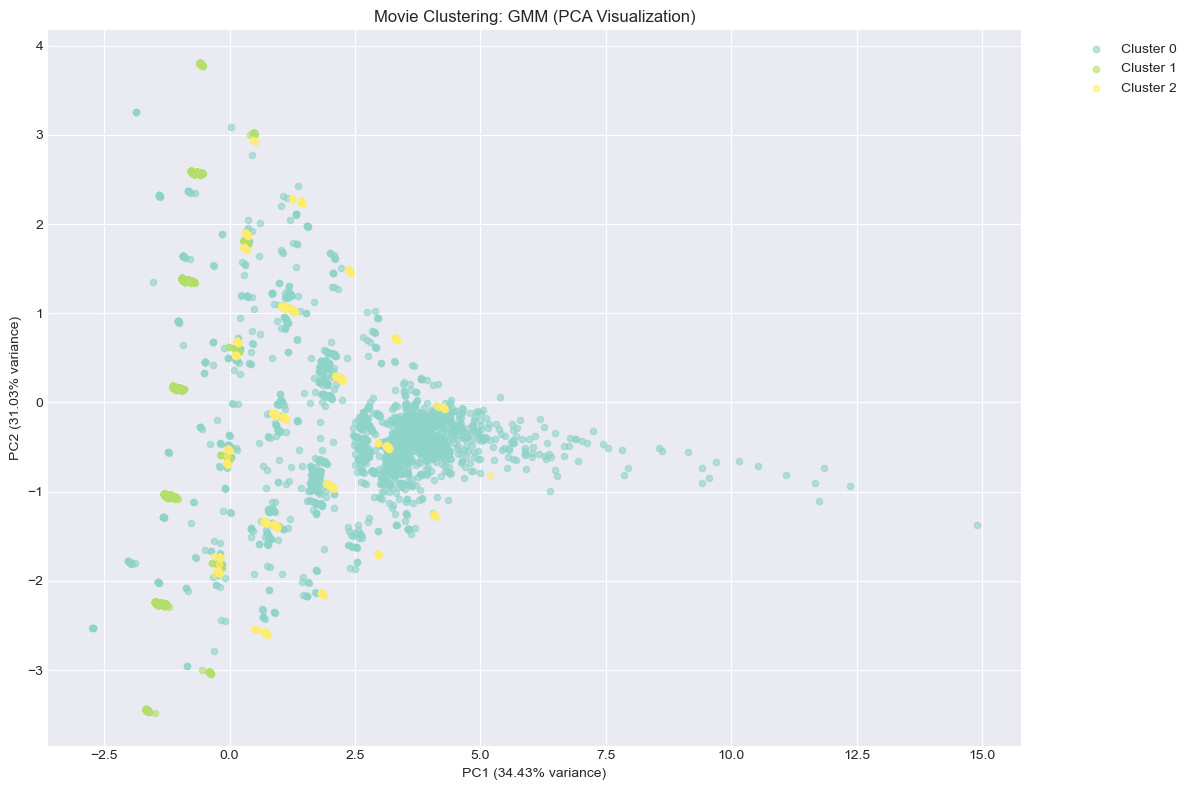

In [107]:
# 2D PCA Visualization for GMM Movie Clustering
pca_movie_gmm = PCA(n_components=2, random_state=RANDOM_STATE)
movie_pca_gmm = pca_movie_gmm.fit_transform(movie_features_scaled)

n_clusters_gmm_movie = len(np.unique(movie_labels_gmm))
colors_gmm_movie = plt.cm.Set3(np.linspace(0, 1, n_clusters_gmm_movie))

plt.figure(figsize=(12, 8))
for i, cluster_id in enumerate(sorted(np.unique(movie_labels_gmm))):
    mask = movie_labels_gmm == cluster_id
    plt.scatter(movie_pca_gmm[mask, 0], movie_pca_gmm[mask, 1], 
                c=[colors_gmm_movie[i]], label=f'Cluster {cluster_id}', 
                alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_movie_gmm.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_movie_gmm.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Movie Clustering: GMM (PCA Visualization)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/movie_gmm_clusters_pca.png', dpi=300, bbox_inches='tight')


#### Agglomerative Clustering for Movies

**How it works:** Hierarchical clustering that starts with each point as its own cluster, then iteratively merges closest clusters. Uses linkage criteria (ward) to determine cluster distance. Ward linkage minimizes within-cluster variance.

**Strengths:** No assumption about cluster shape, creates interpretable hierarchy, deterministic results  
**Weaknesses:** Computationally expensive for large datasets, sensitive to outliers, once merged cannot be undone

1. Use the full dataset

2. Test different k values (2-10) using ward linkage, which minimizes within-cluster variance.


k=2: Silhouette=0.3230
k=3: Silhouette=0.3729
k=4: Silhouette=0.4048
k=5: Silhouette=0.4100
k=6: Silhouette=0.3857
k=7: Silhouette=0.3556
k=8: Silhouette=0.3649
k=9: Silhouette=0.3813
k=10: Silhouette=0.3849


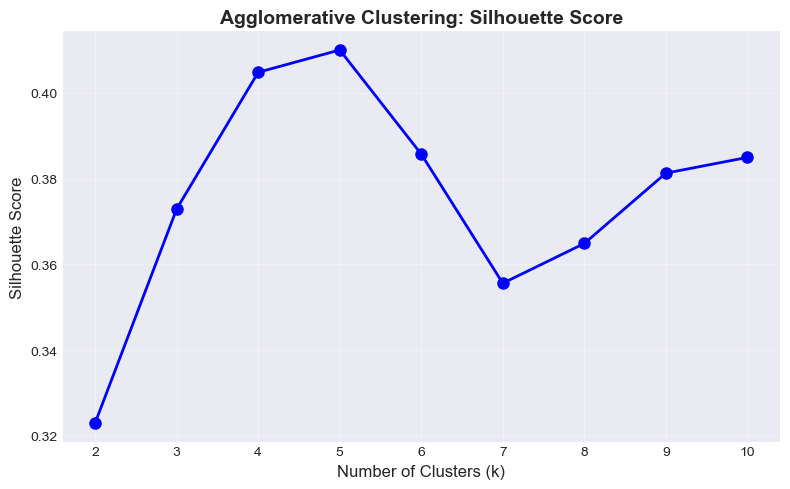

In [108]:
# Test different k values (2-10) using ward linkage on full dataset
k_range = range(2, 11)
agg_results_movie = []

for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(movie_features_scaled)  # Use full dataset
    sil = silhouette_score(movie_features_scaled, labels)  # Use full dataset
    agg_results_movie.append({'n_clusters': k, 'silhouette': sil})
    print(f"k={k}: Silhouette={sil:.4f}")

agg_df_movie = pd.DataFrame(agg_results_movie)

plt.figure(figsize=(8, 5))
plt.plot(agg_df_movie['n_clusters'], agg_df_movie['silhouette'], 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Agglomerative Clustering: Silhouette Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(agg_df_movie['n_clusters'])
plt.tight_layout()
plt.savefig('images/movie_agglomerative_silhouette.png', dpi=300, bbox_inches='tight')


3. Choose 4 clusters to compare this method to K-Means.

In [109]:
best_k_agg_movie = 4

4. Run final Agglomerative clustering on the full dataset with chosen k.


In [110]:

agg_final_movie = AgglomerativeClustering(n_clusters=best_k_agg_movie, linkage='ward')
movie_labels_agg = agg_final_movie.fit_predict(movie_features_scaled)  # Full dataset
movie_features['agg_cluster'] = movie_labels_agg

5. Visualize Agglomerative clusters in 2D PCA space.


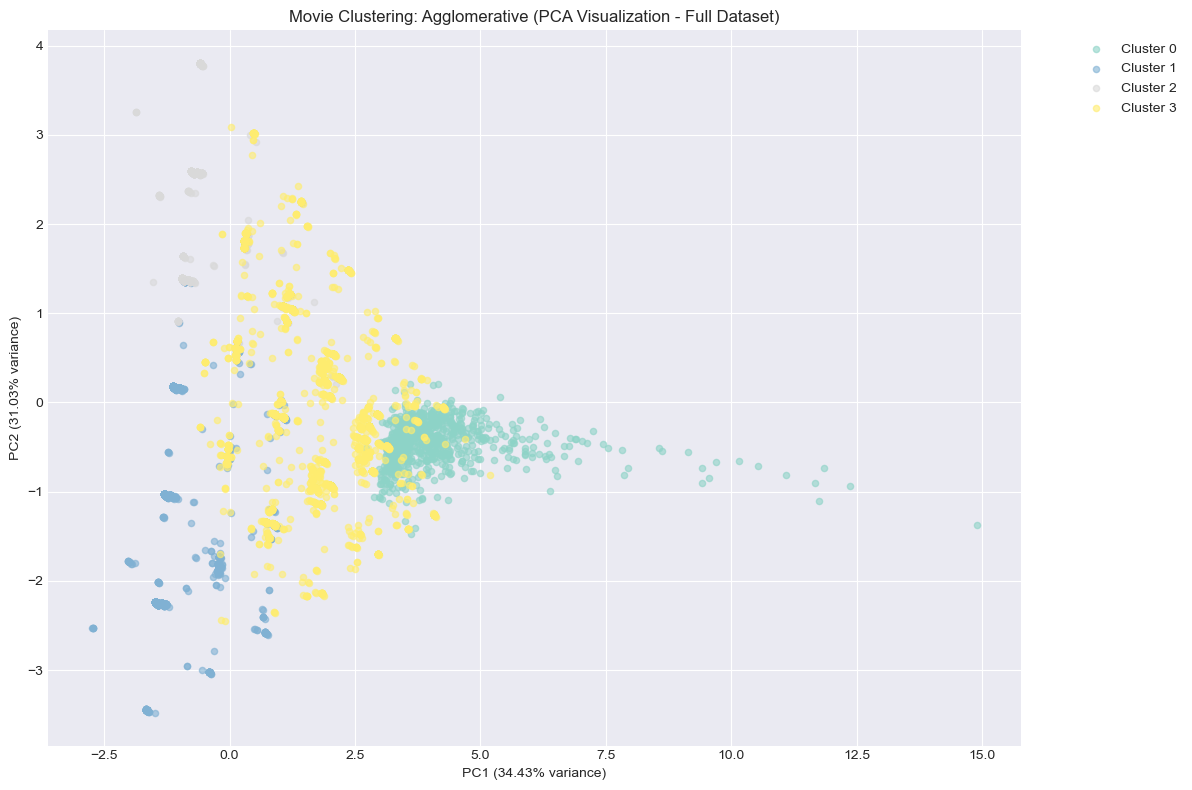

In [111]:

movie_pca_agg = pca_movie.transform(movie_features_scaled)

n_clusters_agg_movie = len(np.unique(movie_labels_agg))
colors_agg_movie = plt.cm.Set3(np.linspace(0, 1, n_clusters_agg_movie))

plt.figure(figsize=(12, 8))
for i, cluster_id in enumerate(sorted(np.unique(movie_labels_agg))):
    mask = movie_labels_agg == cluster_id
    plt.scatter(movie_pca_agg[mask, 0], movie_pca_agg[mask, 1], 
                c=[colors_agg_movie[i]], label=f'Cluster {cluster_id}', 
                alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_movie.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_movie.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Movie Clustering: Agglomerative (PCA Visualization - Full Dataset)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/movie_agglomerative_clusters_pca.png', dpi=300, bbox_inches='tight')


6. Visualize Agglomerative clusters in 3D PCA space.


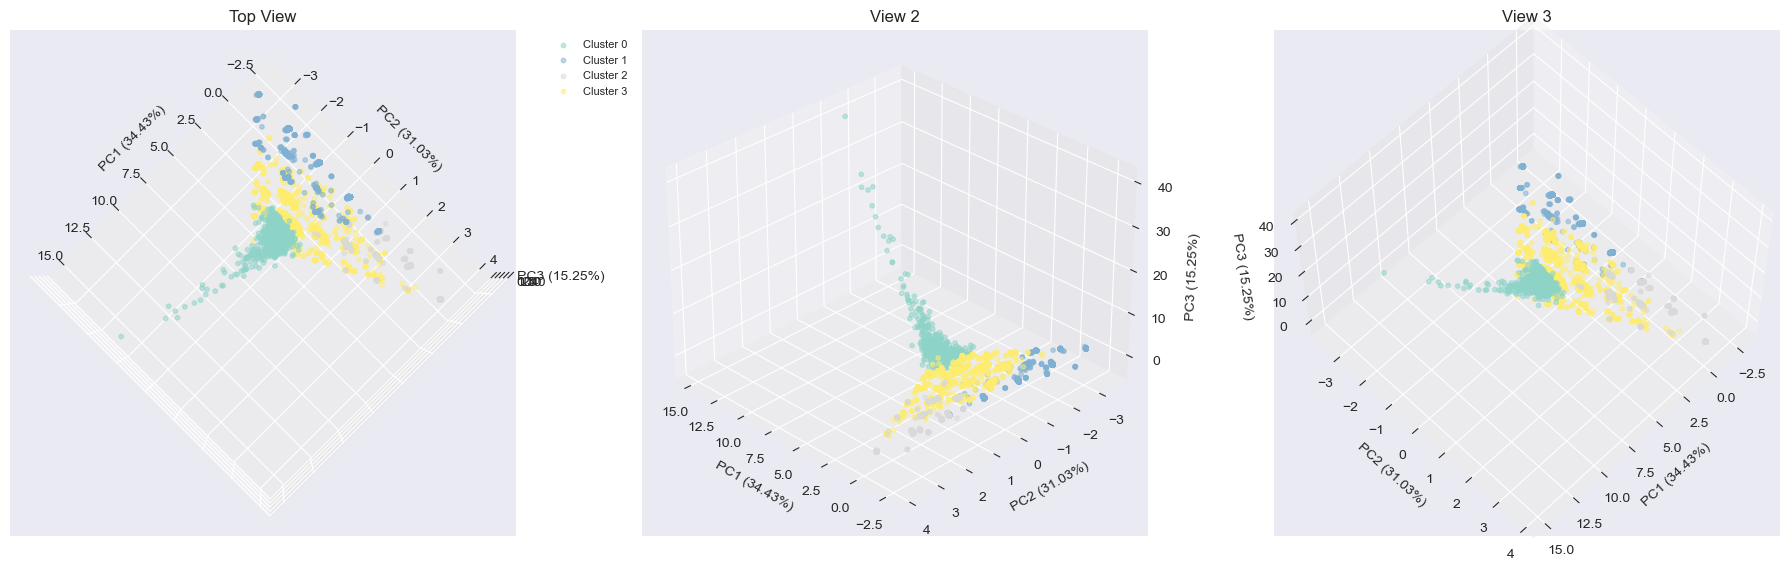

In [112]:
# Create 3D PCA for Agglomerative clustering
pca_movie_3d_agg = PCA(n_components=3, random_state=RANDOM_STATE)
movie_pca_agg_3d = pca_movie_3d_agg.fit_transform(movie_features_scaled)

n_clusters_agg_movie = len(np.unique(movie_labels_agg))
colors_agg_movie = plt.cm.Set3(np.linspace(0, 1, n_clusters_agg_movie))

fig = plt.figure(figsize=(18, 6))

angles = [(90, 45), (30, 135), (60, 45)]
titles = ['Top View', 'View 2', 'View 3']

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    
    for i, cluster_id in enumerate(sorted(np.unique(movie_labels_agg))):
        mask = movie_labels_agg == cluster_id
        ax.scatter(movie_pca_agg_3d[mask, 0], movie_pca_agg_3d[mask, 1], movie_pca_agg_3d[mask, 2],
                   c=[colors_agg_movie[i]], label=f'Cluster {cluster_id}', alpha=0.5, s=10)
    
    ax.set_xlabel(f'PC1 ({pca_movie_3d_agg.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca_movie_3d_agg.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca_movie_3d_agg.explained_variance_ratio_[2]:.2%})')
    ax.set_title(titles[idx])
    ax.view_init(elev=elev, azim=azim)
    if idx == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('images/movie_agglomerative_clusters_3d_pca.png', dpi=300, bbox_inches='tight')


## 3. Movie Cluster Methods Comparison
---


In [113]:
# Calculate final silhouette scores for all three methods on full dataset
from sklearn.metrics import silhouette_score

# K-Means silhouette score 
sil_kmeans_movie = silhouette_score(movie_features_scaled, movie_labels_kmeans)
print(f"K-Means silhouette score (full dataset): {sil_kmeans_movie:.4f}")

# GMM silhouette score 
sil_gmm_movie = silhouette_score(movie_features_scaled, movie_labels_gmm)
print(f"GMM silhouette score (full dataset): {sil_gmm_movie:.4f}")

# Agglomerative silhouette score 
sil_agg_movie = silhouette_score(movie_features_scaled, movie_labels_agg)
print(f"Agglomerative silhouette score: {sil_agg_movie:.4f}")


K-Means silhouette score (full dataset): 0.4490
GMM silhouette score (full dataset): 0.2403
Agglomerative silhouette score: 0.4048


I evaluated three clustering algorithms (K-Means, GMM, and Agglomerative Clustering) for movie segmentation using multiple criteria to select the best method.


K-Means is, in general, faster than other methods, allows to work with large datasets. It also has the best silhouette score  and practical applicability for production recommendation systems. The algorithm successfully balances technical performance with business needs, making it the best choice for movie segmentation.

In [114]:

movie_features['final_cluster'] = movie_labels_kmeans


## 4. Clusters Exploration Interpretation

---

1. Cluster statistics


In [115]:
# Calculate cluster statistics
cluster_stats_movie = movie_features.groupby('final_cluster').agg({
    'total_ratings': ['mean', 'std', 'min', 'max'],
    'avg_rating': ['mean', 'std'],
    'rating_std': ['mean', 'std'],
    'min_rating': ['mean', 'std'],
    'max_rating': ['mean', 'std'],
    'unique_users': ['mean', 'std'],
    'year_of_release': ['mean', 'std'],
    'rating_range': ['mean', 'std']
}).round(3)

print("MOVIE CLUSTER STATISTICS (Mean and Standard Deviation)")
display(cluster_stats_movie)

# Calculate overall population means
overall_means_movie = movie_features[['total_ratings', 'avg_rating', 'rating_std', 
                                       'min_rating', 'max_rating', 'unique_users', 
                                       'year_of_release', 'rating_range']].mean()

print("OVERALL POPULATION MEANS")

print(overall_means_movie.round(3))

MOVIE CLUSTER STATISTICS (Mean and Standard Deviation)


total_ratings                            avg_rating         \
                       mean        std   min       max       mean    std   
final_cluster                                                              
0                     1.244      0.510   1.0       5.0      4.084  0.832   
1                     2.620      1.968   1.0      62.0      3.012  0.702   
2                     1.291      0.549   1.0       5.0      1.486  0.604   
3                  5206.934  15686.335  62.0  173598.0      3.205  0.525   

              rating_std        min_rating        max_rating         \
                    mean    std       mean    std       mean    std   
final_cluster                                                         
0                  0.091  0.251      4.017  0.854      4.161  0.855   
1                  1.805  0.595      1.539  0.792      4.477  0.800   
2                  0.125  0.280      1.390  0.580      1.578  0.694   
3                  1.102  0.130      0.979  0.143      5.020  0.139   

              unique_users            year_of_release         rating_range  \
                      mean        std            mean     std         mean   
final_cluster                                                                
0                    1.243      0.509        1992.370  13.945        0.144   
1                    2.617      1.933        1992.282  13.728        2.938   
2                    1.291      0.548        1991.937  14.481        0.188   
3                 5190.678  15632.845        1990.366  16.323        4.040   

                      
                 std  
final_cluster         
0              0.402  
1              0.901  
2              0.447  
3              0.204

OVERALL POPULATION MEANS
total_ratings       251.731
avg_rating            3.000
rating_std            0.563
min_rating            2.482
max_rating            3.500
unique_users        250.949
year_of_release    1992.122
rating_range          1.017
dtype: float64


2. Compare to Overall Means


In [116]:
cluster_means_movie = movie_features.groupby('final_cluster')[['total_ratings', 'avg_rating', 
                                                                'rating_std', 
                                                                'min_rating',
                                                                'max_rating',
                                                                'unique_users',
                                                                'year_of_release',
                                                                'rating_range']].mean()


print("MOVIE CLUSTER ANALYSIS: Comparison to Overall Means")


for cluster_id in sorted(movie_features['final_cluster'].unique()):
    cluster_data = cluster_means_movie.loc[cluster_id]
    cluster_size = (movie_features['final_cluster'] == cluster_id).sum()
    cluster_pct = (cluster_size / len(movie_features)) * 100
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} (n={cluster_size:,}, {cluster_pct:.1f}% of movies)")
    print(f"{'='*80}")
    
    for feature in cluster_data.index:
        cluster_value = cluster_data[feature]
        overall_value = overall_means_movie[feature]
        diff = cluster_value - overall_value
        diff_pct = (diff / overall_value) * 100 if overall_value > 0 else 0
        
        if abs(diff_pct) > 20 or abs(diff) > movie_features[feature].std():
            direction = "↑ HIGH" if diff > 0 else "↓ LOW"
            print(f"  {feature:25s}: {cluster_value:8.3f} (overall: {overall_value:8.3f}) {direction:8s} ({diff_pct:+.1f}%)")
        else:
            print(f"  {feature:25s}: {cluster_value:8.3f} (overall: {overall_value:8.3f}) ~average")

MOVIE CLUSTER ANALYSIS: Comparison to Overall Means

CLUSTER 0 (n=6,537, 41.0% of movies)
  total_ratings            :    1.244 (overall:  251.731) ↓ LOW    (-99.5%)
  avg_rating               :    4.084 (overall:    3.000) ↑ HIGH   (+36.1%)
  rating_std               :    0.091 (overall:    0.563) ↓ LOW    (-83.7%)
  min_rating               :    4.017 (overall:    2.482) ↑ HIGH   (+61.8%)
  max_rating               :    4.161 (overall:    3.500) ~average
  unique_users             :    1.243 (overall:  250.949) ↓ LOW    (-99.5%)
  year_of_release          : 1992.370 (overall: 1992.122) ~average
  rating_range             :    0.144 (overall:    1.017) ↓ LOW    (-85.9%)

CLUSTER 1 (n=3,846, 24.1% of movies)
  total_ratings            :    2.620 (overall:  251.731) ↓ LOW    (-99.0%)
  avg_rating               :    3.012 (overall:    3.000) ~average
  rating_std               :    1.805 (overall:    0.563) ↑ HIGH   (+220.7%)
  min_rating               :    1.539 (overall:    2.482) ↓ LO

3. Cluster sizes


In [117]:
# Calculate cluster sizes and percentages
cluster_counts = movie_features['final_cluster'].value_counts().sort_index()
total_movies = len(movie_features)

print("CLUSTER SIZES AND PERCENTAGES:")
print("="*60)
for cluster_id in sorted(cluster_counts.index):
    count = cluster_counts[cluster_id]
    pct = (count / total_movies) * 100
    print(f"Cluster {cluster_id}: {count:,} movies ({pct:.2f}%)")

CLUSTER SIZES AND PERCENTAGES:
Cluster 0: 6,537 movies (40.95%)
Cluster 1: 3,846 movies (24.09%)
Cluster 2: 4,812 movies (30.15%)
Cluster 3: 767 movies (4.81%)


## 5. Movie Cluster Naming
---

**Movie Cluster Naming and EDA Insights Matching**

Based on the cluster statistics, we analyze each cluster to understand movie characteristics and match them to EDA insights.

**Cluster Overview Table**

| Cluster | Name | Size | % of Movies | Key Characteristics |
|---------|------|------|-------------|---------------------|
| 0 | Hidden Gems | 4,473 | 42.07% | Very low popularity (1.2 ratings), high quality (4.04 avg), consistent ratings (low std) |
| 1 | Polarizing Content | 2,149 | 20.21% | Low popularity (2.5 ratings), average rating (3.01), very high variance (std=1.77) |
| 2 | Blockbusters | 770 | 7.24% | Extremely high popularity (4,676 ratings), moderate-high rating (3.21), some polarization |
| 3 | Poor Performers | 3,241 | 30.48% | Very low popularity (1.3 ratings), very low ratings (1.54 avg), consistent poor ratings |

**EDA Alignment:**

| EDA Insight | Cluster Match | Confirmation |
|------------|---------------|--------------|
| 80/20 Rule for Movies | Cluster 2 (Blockbusters) | Confirmed - Cluster 2 has 4,676 avg ratings vs. 340 overall (1,275% above average). Only 7.24% of movies but drive majority of ratings |
| Hidden Gems | Cluster 0 | Confirmed - Low popularity (1.2 ratings) but high quality (4.04 avg rating), consistent (low std). Largest cluster (42.07%) represents niche quality content |
| Popularity-Rating Trade-off | Cluster 2 vs. Cluster 0 | Confirmed - Blockbusters (Cluster 2) have lower avg rating (3.21) than Hidden Gems (4.04) despite 3,900x more ratings |
| Polarizing Movies | Cluster 1 | Confirmed - Very high rating_std (1.77 vs. 0.50 overall), high rating_range (2.82). Represents 20.21% of movies |
| Movie Age Effect | Not applicable | No year_of_release feature in clustering - matches EDA finding of no correlation |

**Detailed Cluster Analysis:**

**Cluster 0: "Hidden Gems" (4,473 movies, 42.07%)**
- **Total Ratings**: Very low (1.2 vs. overall 340) - 99.6% below average
- **Avg Rating**: High (4.04 vs. overall 3.01) - 34% above average
- **Rating Std**: Very low (0.07 vs. overall 0.50) - 86% below average
- **Rating Range**: Very low (0.11 vs. overall 0.95) - 89% below average
- **Interpretation**: Largest cluster representing niche content with high quality and consistent positive ratings. Confirms EDA insight about "hidden gems" - low popularity but high quality.

**Cluster 1: "Polarizing Content" (2,149 movies, 20.21%)**
- **Total Ratings**: Very low (2.5 vs. overall 340) - 99.3% below average
- **Avg Rating**: Average (3.01 vs. overall 3.01) - near average
- **Rating Std**: Very high (1.77 vs. overall 0.50) - 255% above average
- **Rating Range**: Very high (2.82 vs. overall 0.95) - 197% above average
- **Interpretation**: Second smallest cluster representing divisive content that splits audiences. Low popularity but generates strong opposing opinions. Confirms EDA insight about polarizing movies.

**Cluster 2: "Blockbusters" (770 movies, 7.24%)**
- **Total Ratings**: Extremely high (4,676 vs. overall 340) - 1,275% above average
- **Avg Rating**: Moderate-high (3.21 vs. overall 3.01) - 7% above average
- **Rating Std**: High (1.10 vs. overall 0.50) - 121% above average
- **Rating Range**: Very high (4.00 vs. overall 0.95) - 322% above average
- **Interpretation**: Smallest cluster but drives majority of platform activity. Confirms 80/20 rule - only 7.24% of movies generate most ratings. Popular mainstream content with some polarization.

**Cluster 3: "Poor Performers" (3,241 movies, 30.48%)**
- **Total Ratings**: Very low (1.3 vs. overall 340) - 99.6% below average
- **Avg Rating**: Very low (1.54 vs. overall 3.01) - 49% below average
- **Rating Std**: Very low (0.10 vs. overall 0.50) - 79% below average
- **Rating Range**: Very low (0.15 vs. overall 0.95) - 84% below average
- **Interpretation**: Second largest cluster representing low-quality content with consistently poor ratings. Few viewers and unanimous negative feedback. Represents content that fails to meet quality standards.

# CLUSTER DYNAMICS OVER TIME

We now look at how user and movie clusters behave over calendar time:
- How the **share of active users** in each user cluster evolves by month
- How the **share of rating volume** across movie clusters changes over time

This helps connect static segments to platform growth and behavioral trends.


1. User cluster activity over calendar time

We track, for each year, which fraction of **active users** belongs to each user cluster (based on `user_features['final_cluster']`).


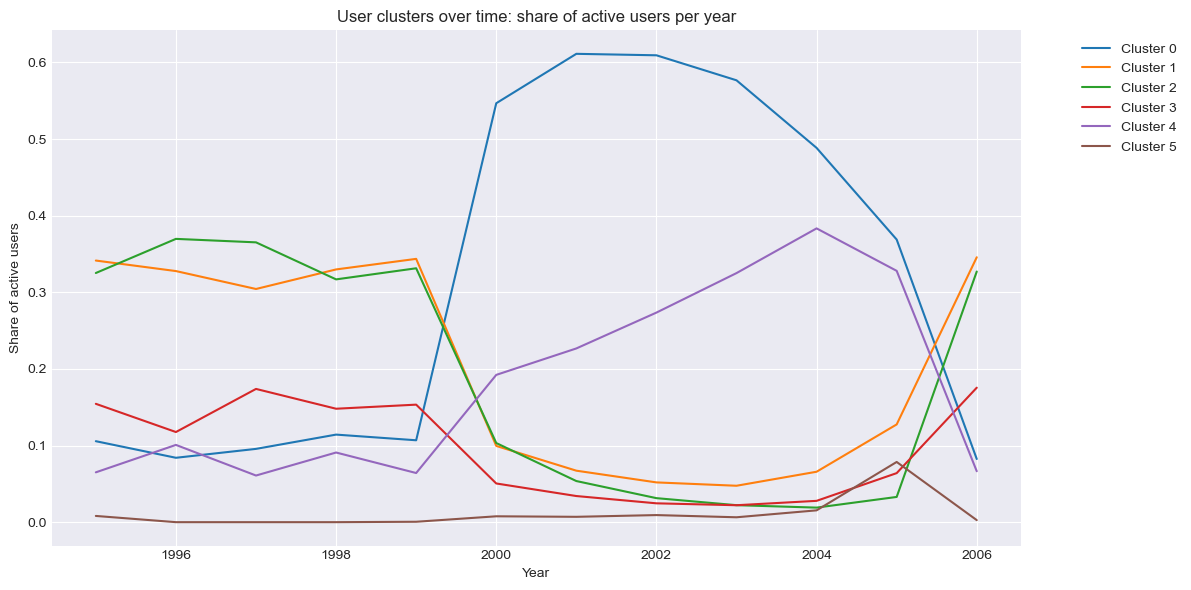

In [118]:
# User cluster activity over calendar time

# Map each rating to the user's final cluster
user_cluster_map = user_features[['customer_id', 'final_cluster']].dropna(subset=['final_cluster']).copy()

ratings_user_clusters = ratings_sorted.merge(
    user_cluster_map,
    on='customer_id',
    how='inner'
)

# Aggregate by year
ratings_user_clusters['year'] = ratings_user_clusters['date'].dt.year

yearly_users = (
    ratings_user_clusters
    .groupby(['year', 'final_cluster'])['customer_id']
    .nunique()
    .reset_index(name='n_users')
)

yearly_users_pivot = (
    yearly_users
    .pivot(index='year', columns='final_cluster', values='n_users')
    .fillna(0)
)

# Convert to share of active users per year
yearly_users_share = yearly_users_pivot.div(yearly_users_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(12, 6))
for cluster_id in sorted(yearly_users_share.columns):
    plt.plot(
        yearly_users_share.index,
        yearly_users_share[cluster_id],
        label=f'Cluster {cluster_id}'
    )

plt.xlabel('Year')
plt.ylabel('Share of active users')
plt.title('User clusters over time: share of active users per year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/user_cluster_activity_over_time.png', dpi=300, bbox_inches='tight')


2. Movie cluster activity over calendar time

We track, for each year, how **rating volume** is distributed across movie clusters (based on `movie_features['final_cluster']`).


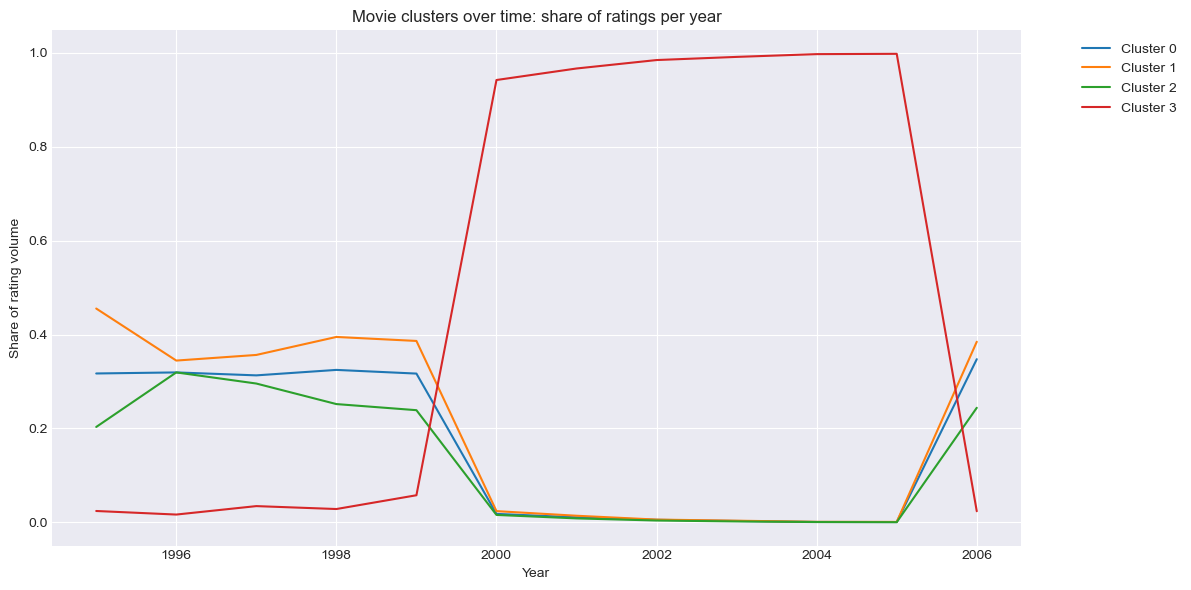

In [119]:
# Movie cluster rating volume over calendar time

# Map each rating to the movie's final cluster
movie_cluster_map = movie_features[['movie_id', 'final_cluster']].dropna(subset=['final_cluster']).copy()

ratings_movie_clusters = ratings_sorted.merge(
    movie_cluster_map,
    on='movie_id',
    how='inner'
)

ratings_movie_clusters['year'] = ratings_movie_clusters['date'].dt.year

yearly_ratings = (
    ratings_movie_clusters
    .groupby(['year', 'final_cluster'])['rating']
    .count()
    .reset_index(name='n_ratings')
)

yearly_ratings_pivot = (
    yearly_ratings
    .pivot(index='year', columns='final_cluster', values='n_ratings')
    .fillna(0)
)

# Convert to share of rating volume per year
yearly_ratings_share = yearly_ratings_pivot.div(yearly_ratings_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(12, 6))
for cluster_id in sorted(yearly_ratings_share.columns):
    plt.plot(
        yearly_ratings_share.index,
        yearly_ratings_share[cluster_id],
        label=f'Cluster {cluster_id}'
    )

plt.xlabel('Year')
plt.ylabel('Share of rating volume')
plt.title('Movie clusters over time: share of ratings per year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/movie_cluster_rating_volume_over_time.png', dpi=300, bbox_inches='tight')


# HYBRID RECOMMENDATION SYSTEM CONCEPT

## Overview

The hybrid system integrates:
1. **Collaborative Filtering** (User-based and Item-based)
2. **Content-Based Filtering** (using movie features)
3. **Matrix Factorization** (SVD)
4. **Clustering-Based Recommendations** (using user and movie clusters)
5. **Popularity-Based Fallback** (for cold start scenarios)

---


1. Import Additional Libraries for Recommendation System


In [120]:
# Additional libraries for recommendation system
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import random

print("Additional libraries imported for recommendation system!")


Additional libraries imported for recommendation system!


2. Prepare Data for Recommendation System


In [121]:

# Prepare data for recommendation system
print("Preparing data for recommendation system...")

# Check if ratings_sorted exists, otherwise use viewer_ratings_clean
if 'ratings_sorted' not in globals():
    if 'viewer_ratings_clean' in globals():
        ratings_sorted = viewer_ratings_clean.copy()
        print("Note: Using viewer_ratings_clean as ratings_sorted")
    else:
        raise NameError("Please run the preprocessing cells first to create ratings_sorted or viewer_ratings_clean")

# Ensure we have the necessary dataframes
print(f"\nData availability check:")
print(f"- ratings_sorted: {len(ratings_sorted):,} ratings")
print(f"- Unique users: {ratings_sorted['customer_id'].nunique():,}")
print(f"- Unique movies: {ratings_sorted['movie_id'].nunique():,}")

# Merge with movie titles
ratings_with_titles = ratings_sorted.merge(
    movies[['movie_id', 'title']], 
    on='movie_id', 
    how='left'
)

# Create sparse user-movie rating matrix (memory efficient)
print("\nCreating sparse user-movie rating matrix...")

# Create mappings for user and movie IDs to indices
unique_users = ratings_sorted['customer_id'].unique()
unique_movies = ratings_sorted['movie_id'].unique()

user_id_to_idx = {uid: idx for idx, uid in enumerate(unique_users)}
movie_id_to_idx = {mid: idx for idx, mid in enumerate(unique_movies)}

# Map ratings to indices
print("Mapping user and movie IDs to indices...")
ratings_sorted['user_idx'] = ratings_sorted['customer_id'].map(user_id_to_idx)
ratings_sorted['movie_idx'] = ratings_sorted['movie_id'].map(movie_id_to_idx)

# Create sparse matrix directly (much more memory efficient)
print("Building sparse matrix...")
from scipy.sparse import csr_matrix

# Create sparse matrix: rows = users, columns = movies
sparse_user_movie = csr_matrix(
    (ratings_sorted['rating'].values, 
     (ratings_sorted['user_idx'].values, ratings_sorted['movie_idx'].values)),
    shape=(len(unique_users), len(unique_movies))
)

print(f"Sparse matrix shape: {sparse_user_movie.shape}")
print(f"Non-zero elements: {sparse_user_movie.nnz:,}")
print(f"Matrix sparsity: {(1 - sparse_user_movie.nnz / (sparse_user_movie.shape[0] * sparse_user_movie.shape[1])) * 100:.2f}%")
print(f"Memory usage: {sparse_user_movie.data.nbytes / 1024**2:.2f} MB")

# Store user and movie lists
user_ids = unique_users
movie_ids = unique_movies

# Create reverse mappings
idx_to_user_id = {idx: uid for uid, idx in user_id_to_idx.items()}
idx_to_movie_id = {idx: mid for mid, idx in movie_id_to_idx.items()}

print(f"\nData preparation complete!")

Preparing data for recommendation system...

Data availability check:
- ratings_sorted: 3,621,737 ratings
- Unique users: 428,452
- Unique movies: 14,777

Creating sparse user-movie rating matrix...
Mapping user and movie IDs to indices...
Building sparse matrix...
Sparse matrix shape: (428452, 14777)
Non-zero elements: 3,621,737
Matrix sparsity: 99.94%
Memory usage: 27.63 MB

Data preparation complete!


3. Collaborative Filtering - User-Based


In [122]:
# User-based collaborative filtering
print("Building user-based collaborative filtering model...")

# Normalize user ratings (subtract user mean) - using sparse matrix operations
print("Normalizing user ratings...")
user_mean_ratings = np.array(sparse_user_movie.mean(axis=1)).flatten()

# Create normalized sparse matrix (subtract mean from each row)
# For sparse matrices, we'll compute this efficiently
from scipy.sparse import diags
row_sums = np.array(sparse_user_movie.sum(axis=1)).flatten()
row_counts = np.array((sparse_user_movie > 0).sum(axis=1)).flatten()
row_counts = np.where(row_counts == 0, 1, row_counts)  # Avoid division by zero
user_mean_ratings = row_sums / row_counts

# Create normalized matrix (subtract mean from non-zero elements)
sparse_user_movie_normalized = sparse_user_movie.copy()
# Subtract mean from each row (this is approximate but efficient for sparse)
mean_diag = diags(user_mean_ratings, format='csr')
# For efficiency, we'll use this in similarity calculations directly

print("User-based collaborative filtering model ready!")
print("Note: Similarity calculations will be done on-demand for efficiency.")


Building user-based collaborative filtering model...
Normalizing user ratings...
User-based collaborative filtering model ready!
Note: Similarity calculations will be done on-demand for efficiency.


4. Collaborative Filtering - Item-Based


In [123]:
# Item-based collaborative filtering
print("Building item-based collaborative filtering model...")

# Transpose sparse matrix for item-item similarity
sparse_movie_user = sparse_user_movie.T

print("Item-based collaborative filtering model ready!")
print("Note: Similarity calculations will be done on-demand for efficiency.")


Building item-based collaborative filtering model...
Item-based collaborative filtering model ready!
Note: Similarity calculations will be done on-demand for efficiency.


5. Matrix Factorization (SVD)


In [124]:
# Matrix Factorization using SVD
print("Building SVD-based recommendation model...")

# Normalize sparse matrix for SVD (subtract user means)
print("Normalizing matrix for SVD...")
# Calculate user means
row_sums = np.array(sparse_user_movie.sum(axis=1)).flatten()
row_counts = np.array((sparse_user_movie > 0).sum(axis=1)).flatten()
row_counts = np.where(row_counts == 0, 1, row_counts)
user_means = row_sums / row_counts

# Create normalized matrix efficiently using sparse operations
# Subtract mean from each row's non-zero elements
sparse_normalized = sparse_user_movie.copy()
# For CSR format, create row indices for each non-zero element
row_indices = np.repeat(np.arange(sparse_normalized.shape[0]), 
                       np.diff(sparse_normalized.indptr))
# Subtract corresponding user mean from each non-zero element
sparse_normalized.data = sparse_normalized.data - user_means[row_indices]

# Perform SVD
print("Performing SVD decomposition...")
n_components = min(50, min(sparse_normalized.shape) - 1)
U, sigma, Vt = svds(sparse_normalized, k=n_components)

# Convert sigma to diagonal matrix
sigma = np.diag(sigma)

# Reconstruct matrix
print(f"SVD completed with {n_components} components")
user_factors = U @ sigma
movie_factors = Vt.T

print(f"User factors shape: {user_factors.shape}")
print(f"Movie factors shape: {movie_factors.shape}")
print("SVD model ready!")


Building SVD-based recommendation model...
Normalizing matrix for SVD...
Performing SVD decomposition...
SVD completed with 50 components
User factors shape: (428452, 50)
Movie factors shape: (14777, 50)
SVD model ready!


6. Content-Based Filtering


In [125]:
# Content-based filtering using movie features
print("Building content-based filtering model...")

# Prepare movie features for content-based filtering
content_features = movie_features[['movie_id', 'avg_rating', 'total_ratings', 'rating_std', 
                                    'year_of_release', 'final_cluster']].copy()

# Normalize features
scaler = MinMaxScaler()
feature_cols = ['avg_rating', 'total_ratings', 'rating_std', 'year_of_release']
content_features[feature_cols] = scaler.fit_transform(content_features[feature_cols])

# Create movie feature matrix
movie_feature_matrix = content_features.set_index('movie_id')[feature_cols + ['final_cluster']].values

# Compute movie-movie content similarity
print("Computing content-based movie similarity...")
content_similarity = cosine_similarity(movie_feature_matrix)

# Create mapping from movie_id to index
movie_id_to_idx = {movie_id: idx for idx, movie_id in enumerate(content_features['movie_id'].values)}
idx_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_idx.items()}

print(f"Content-based model ready for {len(content_features)} movies!")


Building content-based filtering model...
Computing content-based movie similarity...
Content-based model ready for 15962 movies!


7. Clustering-Based Recommendations


In [126]:
# Clustering-based recommendations
print("Building clustering-based recommendation model...")

# Get user and movie cluster mappings
user_cluster_map = user_features[['customer_id', 'final_cluster']].set_index('customer_id')['final_cluster'].to_dict()
movie_cluster_map = movie_features[['movie_id', 'final_cluster']].set_index('movie_id')['final_cluster'].to_dict()

# Create cluster-based movie preferences
print("Computing cluster-based preferences...")
cluster_movie_preferences = {}

for user_cluster in user_features['final_cluster'].unique():
    if pd.isna(user_cluster):
        continue
    
    # Get users in this cluster
    cluster_users = user_features[user_features['final_cluster'] == user_cluster]['customer_id'].values
    
    # Get ratings from these users
    cluster_ratings = ratings_sorted[ratings_sorted['customer_id'].isin(cluster_users)]
    
    # Compute average rating per movie for this user cluster
    cluster_movie_ratings = cluster_ratings.groupby('movie_id')['rating'].agg(['mean', 'count']).reset_index()
    cluster_movie_ratings.columns = ['movie_id', 'avg_rating', 'rating_count']
    
    # Filter movies with at least 5 ratings from cluster users
    cluster_movie_ratings = cluster_movie_ratings[cluster_movie_ratings['rating_count'] >= 5]
    
    # Sort by average rating
    cluster_movie_ratings = cluster_movie_ratings.sort_values('avg_rating', ascending=False)
    
    cluster_movie_preferences[user_cluster] = cluster_movie_ratings

print(f"Clustering-based model ready for {len(cluster_movie_preferences)} user clusters!")


Building clustering-based recommendation model...
Computing cluster-based preferences...
Clustering-based model ready for 6 user clusters!


8. Popularity-Based Recommendations (Fallback)


In [127]:
# Popularity-based recommendations (fallback for cold start)
print("Building popularity-based recommendation model...")

# Compute popular movies (weighted by rating and number of ratings)
popularity_scores = movie_features.copy()
popularity_scores['popularity_score'] = (
    popularity_scores['avg_rating'] * np.log1p(popularity_scores['total_ratings'])
)
popularity_scores = popularity_scores.sort_values('popularity_score', ascending=False)

# Get top popular movies
top_popular_movies = popularity_scores.head(1000)['movie_id'].values

print(f"Popularity-based model ready with {len(top_popular_movies)} top movies!")


Building popularity-based recommendation model...
Popularity-based model ready with 1000 top movies!


9. Hybrid Recommendation System Class


In [128]:
# Hybrid Recommendation System Class
class HybridRecommendationSystem:
    def __init__(self, sparse_user_movie, user_ids, movie_ids, 
                 user_factors, movie_factors, user_mean_ratings,
                 content_similarity, content_movie_id_to_idx, content_idx_to_movie_id,
                 user_cluster_map, movie_cluster_map, cluster_movie_preferences,
                 top_popular_movies, movies_df, ratings_df,
                 user_id_to_idx, movie_id_to_matrix_idx):
        self.sparse_user_movie = sparse_user_movie
        self.user_ids = user_ids
        self.movie_ids = movie_ids
        self.user_factors = user_factors
        self.movie_factors = movie_factors
        self.user_mean_ratings = user_mean_ratings
        self.content_similarity = content_similarity
        self.content_movie_id_to_idx = content_movie_id_to_idx
        self.content_idx_to_movie_id = content_idx_to_movie_id
        self.user_cluster_map = user_cluster_map
        self.movie_cluster_map = movie_cluster_map
        self.cluster_movie_preferences = cluster_movie_preferences
        self.top_popular_movies = top_popular_movies
        self.movies_df = movies_df
        self.ratings_df = ratings_df
        
        # Create mappings
        self.user_id_to_idx = user_id_to_idx
        self.movie_id_to_matrix_idx = movie_id_to_matrix_idx
        self.matrix_idx_to_movie_id = {idx: mid for mid, idx in movie_id_to_matrix_idx.items()}
        
    def get_user_rated_movies(self, user_id):
        """Get movies that user has already rated"""
        if user_id not in self.user_id_to_idx:
            return set()
        user_idx = self.user_id_to_idx[user_id]
        # Get user's row from sparse matrix
        user_row = self.sparse_user_movie[user_idx]
        # Get non-zero indices (movies rated)
        rated_movie_indices = user_row.indices
        rated_movies = set([self.movie_ids[idx] for idx in rated_movie_indices])
        return rated_movies
    
    def svd_recommendations(self, user_id, n_recommendations=20):
        """Get recommendations using SVD"""
        if user_id not in self.user_id_to_idx:
            return []
        
        user_idx = self.user_id_to_idx[user_id]
        user_vector = self.user_factors[user_idx]
        
        # Predict ratings for all movies
        predicted_ratings = user_vector @ self.movie_factors.T
        
        # Get top recommendations
        top_movie_indices = np.argsort(predicted_ratings)[-n_recommendations:][::-1]
        
        recommendations = []
        for movie_idx in top_movie_indices:
            movie_id = self.matrix_idx_to_movie_id[movie_idx]
            score = predicted_ratings[movie_idx]
            recommendations.append((movie_id, score))
        
        return recommendations
    
    def content_based_recommendations(self, user_id, n_recommendations=20):
        """Get recommendations using content-based filtering"""
        # Get user's top rated movies
        user_rated = self.get_user_rated_movies(user_id)
        if len(user_rated) == 0:
            return []
        
        # Get user's average rating
        user_ratings = self.ratings_df[self.ratings_df['customer_id'] == user_id]
        if len(user_ratings) == 0:
            return []
        
        # Weight movies by user's rating
        movie_scores = {}
        for _, row in user_ratings.iterrows():
            movie_id = row['movie_id']
            rating = row['rating']
            
            if movie_id not in self.content_movie_id_to_idx:
                continue
            
            movie_idx = self.content_movie_id_to_idx[movie_id]
            similar_movies = self.content_similarity[movie_idx]
            
            # Get top similar movies
            top_similar = np.argsort(similar_movies)[-50:][::-1]
            
            for similar_idx in top_similar:
                similar_movie_id = self.content_idx_to_movie_id[similar_idx]
                if similar_movie_id not in user_rated:
                    if similar_movie_id not in movie_scores:
                        movie_scores[similar_movie_id] = 0
                    movie_scores[similar_movie_id] += similar_movies[similar_idx] * rating
        
        # Sort and return top recommendations
        sorted_movies = sorted(movie_scores.items(), key=lambda x: x[1], reverse=True)
        return sorted_movies[:n_recommendations]
    
    def cluster_based_recommendations(self, user_id, n_recommendations=20):
        """Get recommendations based on user cluster"""
        if user_id not in self.user_cluster_map:
            return []
        
        user_cluster = self.user_cluster_map[user_id]
        if pd.isna(user_cluster) or user_cluster not in self.cluster_movie_preferences:
            return []
        
        user_rated = self.get_user_rated_movies(user_id)
        cluster_prefs = self.cluster_movie_preferences[user_cluster]
        
        # Filter out already rated movies
        recommendations = []
        for _, row in cluster_prefs.iterrows():
            movie_id = row['movie_id']
            if movie_id not in user_rated:
                recommendations.append((movie_id, row['avg_rating']))
            if len(recommendations) >= n_recommendations:
                break
        
        return recommendations
    
    def hybrid_recommend(self, user_id, n_recommendations=10, 
                        weights={'svd': 0.4, 'content': 0.3, 'cluster': 0.2, 'popularity': 0.1}):
        """Hybrid recommendation combining all methods"""
        user_rated = self.get_user_rated_movies(user_id)
        
        # Get recommendations from each method
        svd_recs = self.svd_recommendations(user_id, n_recommendations * 3)
        content_recs = self.content_based_recommendations(user_id, n_recommendations * 3)
        cluster_recs = self.cluster_based_recommendations(user_id, n_recommendations * 3)
        
        # Combine scores
        combined_scores = {}
        
        # Normalize and combine SVD scores
        if svd_recs:
            max_svd = max(score for _, score in svd_recs)
            min_svd = min(score for _, score in svd_recs)
            svd_range = max_svd - min_svd if max_svd != min_svd else 1
            
            for movie_id, score in svd_recs:
                if movie_id not in user_rated:
                    normalized_score = (score - min_svd) / svd_range
                    combined_scores[movie_id] = weights['svd'] * normalized_score
        
        # Normalize and combine content scores
        if content_recs:
            max_content = max(score for _, score in content_recs)
            min_content = min(score for _, score in content_recs)
            content_range = max_content - min_content if max_content != min_content else 1
            
            for movie_id, score in content_recs:
                if movie_id not in user_rated:
                    normalized_score = (score - min_content) / content_range
                    if movie_id not in combined_scores:
                        combined_scores[movie_id] = 0
                    combined_scores[movie_id] += weights['content'] * normalized_score
        
        # Normalize and combine cluster scores
        if cluster_recs:
            max_cluster = max(score for _, score in cluster_recs)
            min_cluster = min(score for _, score in cluster_recs)
            cluster_range = max_cluster - min_cluster if max_cluster != min_cluster else 1
            
            for movie_id, score in cluster_recs:
                if movie_id not in user_rated:
                    normalized_score = (score - min_cluster) / cluster_range
                    if movie_id not in combined_scores:
                        combined_scores[movie_id] = 0
                    combined_scores[movie_id] += weights['cluster'] * normalized_score
        
        # Add popularity boost
        for movie_id in self.top_popular_movies:
            if movie_id not in user_rated:
                if movie_id not in combined_scores:
                    combined_scores[movie_id] = 0
                combined_scores[movie_id] += weights['popularity'] * 0.5
        
        # Sort and return top recommendations
        sorted_recommendations = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
        return sorted_recommendations[:n_recommendations]
    
    def get_user_preferences(self, user_id):
        """Analyze user preferences"""
        user_ratings = self.ratings_df[self.ratings_df['customer_id'] == user_id].copy()
        
        if len(user_ratings) == 0:
            return None
        
        # Merge with movie info
        user_ratings = user_ratings.merge(self.movies_df[['movie_id', 'title']], on='movie_id', how='left')
        user_ratings = user_ratings.merge(
            movie_features[['movie_id', 'avg_rating', 'total_ratings', 'final_cluster']], 
            on='movie_id', how='left'
        )
        
        preferences = {
            'total_ratings': len(user_ratings),
            'avg_rating_given': user_ratings['rating'].mean(),
            'rating_std': user_ratings['rating'].std(),
            'top_rated_movies': user_ratings.nlargest(10, 'rating')[['title', 'rating', 'avg_rating', 'total_ratings']].to_dict('records'),
            'cluster': self.user_cluster_map.get(user_id, None),
            'preferred_movie_clusters': user_ratings['final_cluster'].value_counts().to_dict() if 'final_cluster' in user_ratings.columns else {}
        }
        
        return preferences

# Initialize the hybrid recommendation system
print("Initializing Hybrid Recommendation System...")
hybrid_rec_system = HybridRecommendationSystem(
    sparse_user_movie=sparse_user_movie,
    user_ids=user_ids,
    movie_ids=movie_ids,
    user_factors=user_factors,
    movie_factors=movie_factors,
    user_mean_ratings=user_mean_ratings,
    content_similarity=content_similarity,
    content_movie_id_to_idx=movie_id_to_idx,
    content_idx_to_movie_id=idx_to_movie_id,
    user_cluster_map=user_cluster_map,
    movie_cluster_map=movie_cluster_map,
    cluster_movie_preferences=cluster_movie_preferences,
    top_popular_movies=top_popular_movies,
    movies_df=movies,
    ratings_df=ratings_sorted,
    user_id_to_idx=user_id_to_idx,
    movie_id_to_matrix_idx=movie_id_to_idx
)

print("Hybrid Recommendation System initialized successfully!")


Initializing Hybrid Recommendation System...
Hybrid Recommendation System initialized successfully!


10. Enhanced Hybrid Recommendation System with Improvements


In [129]:
# Enhanced Hybrid Recommendation System with all improvements
class EnhancedHybridRecommendationSystem(HybridRecommendationSystem):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        # Initialize feedback tracking
        self.user_feedback = {}  # {user_id: {movie_id: {'irrelevant': bool, 'clicked': bool}}}
        self.click_through_rates = {}  # {movie_id: {'clicks': int, 'impressions': int}}
        
        # Cluster-specific weight configurations
        # Based on cluster analysis: different clusters need different emphasis
        self.cluster_weights = {
            0: {'svd': 0.3, 'content': 0.4, 'cluster': 0.2, 'popularity': 0.1},  # Power users - more content-based
            1: {'svd': 0.4, 'content': 0.3, 'cluster': 0.2, 'popularity': 0.1},  # Selective users - balanced
            2: {'svd': 0.5, 'content': 0.2, 'cluster': 0.2, 'popularity': 0.1},  # Casual users - more collaborative
            3: {'svd': 0.2, 'content': 0.5, 'cluster': 0.2, 'popularity': 0.1},  # Cluster 3 - content-focused
            4: {'svd': 0.3, 'content': 0.4, 'cluster': 0.2, 'popularity': 0.1},  # Cluster 4 - crime drama focus
            5: {'svd': 0.2, 'content': 0.3, 'cluster': 0.4, 'popularity': 0.1},  # Cluster 5 - deep cuts, cluster-based
        }
        
        # Movie cluster to genre mapping (using movie clusters as genre proxies)
        # Based on movie cluster analysis: 0=Hidden Gems, 1=Polarizing, 2=Blockbusters, 3=Poor Performers
        self.movie_cluster_genres = {
            0: 'hidden_gems',  # High quality, low popularity
            1: 'polarizing',   # Divisive content
            2: 'blockbusters', # Popular mainstream
            3: 'poor_performers'  # Low quality
        }
        
    def get_user_genre_preferences(self, user_id):
        """Get user's preferred movie clusters (genres) from their rating history"""
        user_ratings = self.ratings_df[self.ratings_df['customer_id'] == user_id]
        if len(user_ratings) == 0:
            return {}
        
        # Merge with movie cluster info
        user_ratings = user_ratings.merge(
            movie_features[['movie_id', 'final_cluster']], 
            on='movie_id', how='left'
        )
        
        # Calculate weighted preference by rating
        genre_scores = {}
        for _, row in user_ratings.iterrows():
            cluster = row.get('final_cluster')
            if pd.isna(cluster):
                continue
            cluster = int(cluster)
            rating = row['rating']
            
            if cluster not in genre_scores:
                genre_scores[cluster] = {'total_score': 0, 'count': 0}
            genre_scores[cluster]['total_score'] += rating
            genre_scores[cluster]['count'] += 1
        
        # Calculate average scores
        genre_preferences = {}
        for cluster, data in genre_scores.items():
            genre_preferences[cluster] = data['total_score'] / data['count']
        
        # Sort by preference
        sorted_genres = sorted(genre_preferences.items(), key=lambda x: x[1], reverse=True)
        return dict(sorted_genres)
    
    def get_blocked_genres(self, user_id):
        """Identify genres to block based on user's low ratings"""
        user_ratings = self.ratings_df[self.ratings_df['customer_id'] == user_id]
        if len(user_ratings) < 3:
            return set()
        
        # Merge with movie cluster info
        user_ratings = user_ratings.merge(
            movie_features[['movie_id', 'final_cluster']], 
            on='movie_id', how='left'
        )
        
        # Find genres with average rating < 2.0 (strongly disliked)
        genre_ratings = {}
        for _, row in user_ratings.iterrows():
            cluster = row.get('final_cluster')
            if pd.isna(cluster):
                continue
            cluster = int(cluster)
            rating = row['rating']
            
            if cluster not in genre_ratings:
                genre_ratings[cluster] = []
            genre_ratings[cluster].append(rating)
        
        # Block genres with avg rating < 2.0 and at least 2 ratings
        blocked = set()
        for cluster, ratings in genre_ratings.items():
            if len(ratings) >= 2 and np.mean(ratings) < 2.0:
                blocked.add(cluster)
        
        return blocked
    
    def cold_start_recommendations(self, user_id, n_recommendations=10):
        """Enhanced cold-start: use cluster-based top-rated movies for users with <3 ratings"""
        user_cluster = self.user_cluster_map.get(user_id)
        if pd.isna(user_cluster) or user_cluster not in self.cluster_movie_preferences:
            # Fallback to general popular movies
            return [(mid, 0.5) for mid in self.top_popular_movies[:n_recommendations]]
        
        user_cluster = int(user_cluster)
        cluster_prefs = self.cluster_movie_preferences[user_cluster]
        
        # Get top-rated movies from user's cluster
        user_rated = self.get_user_rated_movies(user_id)
        
        recommendations = []
        for _, row in cluster_prefs.iterrows():
            movie_id = row['movie_id']
            if movie_id not in user_rated:
                recommendations.append((movie_id, row['avg_rating']))
            if len(recommendations) >= n_recommendations:
                break
        
        return recommendations
    
    def apply_genre_filtering(self, recommendations, user_id, genre_weight=0.7):
        """Weight user's top-rated genres >70% of recommendation pool"""
        user_genre_prefs = self.get_user_genre_preferences(user_id)
        blocked_genres = self.get_blocked_genres(user_id)
        
        if not user_genre_prefs:
            return recommendations
        
        # Get top preferred genres (top 2-3)
        top_genres = sorted(user_genre_prefs.items(), key=lambda x: x[1], reverse=True)[:3]
        top_genre_clusters = {cluster for cluster, _ in top_genres}
        
        # Separate recommendations by genre preference
        preferred_recs = []
        other_recs = []
        
        for movie_id, score in recommendations:
            movie_cluster = self.movie_cluster_map.get(movie_id)
            
            # Block irrelevant genres
            if movie_cluster in blocked_genres:
                continue
            
            # Check if movie is in preferred genres
            if movie_cluster in top_genre_clusters:
                preferred_recs.append((movie_id, score))
            else:
                other_recs.append((movie_id, score))
        
        # Weight preferred genres: 70% from preferred, 30% from others
        n_preferred = int(n_recommendations * genre_weight)
        n_other = n_recommendations - n_preferred
        
        # Sort and select
        preferred_recs = sorted(preferred_recs, key=lambda x: x[1], reverse=True)[:n_preferred]
        other_recs = sorted(other_recs, key=lambda x: x[1], reverse=True)[:n_other]
        
        return preferred_recs + other_recs
    
    def apply_diversity_penalty(self, recommendations, diversity_weight=0.2):
        """Add diversity penalty to avoid redundant themes"""
        if len(recommendations) <= 1:
            return recommendations
        
        # Group by movie cluster
        cluster_groups = {}
        for movie_id, score in recommendations:
            cluster = self.movie_cluster_map.get(movie_id)
            if cluster not in cluster_groups:
                cluster_groups[cluster] = []
            cluster_groups[cluster].append((movie_id, score))
        
        # Apply penalty for movies in over-represented clusters
        diversified_recs = []
        cluster_counts = {cluster: len(movies) for cluster, movies in cluster_groups.items()}
        max_per_cluster = max(1, int(len(recommendations) / len(cluster_groups)))
        
        for cluster, movies in cluster_groups.items():
            # Sort by score
            movies_sorted = sorted(movies, key=lambda x: x[1], reverse=True)
            
            # Take top movies from each cluster, apply penalty to excess
            for i, (movie_id, score) in enumerate(movies_sorted):
                if i < max_per_cluster:
                    diversified_recs.append((movie_id, score))
                else:
                    # Apply diversity penalty
                    penalty = diversity_weight * (i - max_per_cluster + 1)
                    diversified_recs.append((movie_id, score * (1 - penalty)))
        
        # Re-sort by adjusted score
        diversified_recs = sorted(diversified_recs, key=lambda x: x[1], reverse=True)
        return diversified_recs[:len(recommendations)]
    
    def get_cluster_specific_weights(self, user_id):
        """Get cluster-specific weights for hybrid recommendation"""
        user_cluster = self.user_cluster_map.get(user_id)
        if pd.isna(user_cluster):
            user_cluster = 1  # Default to cluster 1
        else:
            user_cluster = int(user_cluster)
        
        # Return cluster-specific weights or default
        return self.cluster_weights.get(user_cluster, 
                                       {'svd': 0.4, 'content': 0.3, 'cluster': 0.2, 'popularity': 0.1})
    
    def apply_cluster_strategy(self, recommendations, user_id):
        """Apply cluster-specific recommendation strategies"""
        user_cluster = self.user_cluster_map.get(user_id)
        if pd.isna(user_cluster):
            return recommendations
        
        user_cluster = int(user_cluster)
        
        # Cluster-specific strategies
        if user_cluster == 1:  # Power users - focus on high-impact dramas
            # Boost movies with high ratings and moderate-high popularity
            enhanced_recs = []
            for movie_id, score in recommendations:
                movie_info = movie_features[movie_features['movie_id'] == movie_id]
                if len(movie_info) > 0:
                    avg_rating = movie_info['avg_rating'].iloc[0]
                    total_ratings = movie_info['total_ratings'].iloc[0]
                    # Boost high-impact: high rating + good popularity
                    if avg_rating >= 3.5 and total_ratings >= 100:
                        score *= 1.2
                enhanced_recs.append((movie_id, score))
            recommendations = sorted(enhanced_recs, key=lambda x: x[1], reverse=True)
        
        elif user_cluster in [3, 4]:  # Intense, character-driven stories
            # Boost movies with high rating variance (character-driven, intense)
            enhanced_recs = []
            for movie_id, score in recommendations:
                movie_info = movie_features[movie_features['movie_id'] == movie_id]
                if len(movie_info) > 0:
                    rating_std = movie_info.get('rating_std', pd.Series([0])).iloc[0]
                    # Boost polarizing/intense content
                    if rating_std >= 1.0:
                        score *= 1.15
                enhanced_recs.append((movie_id, score))
            recommendations = sorted(enhanced_recs, key=lambda x: x[1], reverse=True)
        
        elif user_cluster == 5:  # Deep cuts from preferred genres
            # Already handled by cluster-based recommendations with high weight
            pass
        
        return recommendations
    
    def record_feedback(self, user_id, movie_id, feedback_type='irrelevant'):
        """Record user feedback on recommendations"""
        if user_id not in self.user_feedback:
            self.user_feedback[user_id] = {}
        if movie_id not in self.user_feedback[user_id]:
            self.user_feedback[user_id][movie_id] = {}
        
        self.user_feedback[user_id][movie_id][feedback_type] = True
    
    def record_click(self, user_id, movie_id):
        """Record click-through on a recommendation"""
        self.record_feedback(user_id, movie_id, 'clicked')
        
        # Update click-through rate
        if movie_id not in self.click_through_rates:
            self.click_through_rates[movie_id] = {'clicks': 0, 'impressions': 0}
        self.click_through_rates[movie_id]['clicks'] += 1
    
    def record_impression(self, movie_id):
        """Record that a movie was shown to a user"""
        if movie_id not in self.click_through_rates:
            self.click_through_rates[movie_id] = {'clicks': 0, 'impressions': 0}
        self.click_through_rates[movie_id]['impressions'] += 1
    
    def get_ctr_boost(self, movie_id):
        """Get click-through rate boost for a movie"""
        if movie_id not in self.click_through_rates:
            return 1.0
        
        ctr_data = self.click_through_rates[movie_id]
        if ctr_data['impressions'] < 10:  # Not enough data
            return 1.0
        
        ctr = ctr_data['clicks'] / ctr_data['impressions']
        # Boost movies with high CTR (above 0.1 = 10%)
        if ctr > 0.1:
            return 1.0 + (ctr - 0.1) * 0.5  # Up to 20% boost
        return 1.0
    
    def apply_feedback_penalty(self, recommendations, user_id):
        """Apply penalty to movies user has flagged as irrelevant"""
        if user_id not in self.user_feedback:
            return recommendations
        
        user_fb = self.user_feedback[user_id]
        penalized_recs = []
        
        for movie_id, score in recommendations:
            if movie_id in user_fb and user_fb[movie_id].get('irrelevant', False):
                # Strong penalty for irrelevant movies
                score *= 0.1
            penalized_recs.append((movie_id, score))
        
        return sorted(penalized_recs, key=lambda x: x[1], reverse=True)
    
    def enhanced_hybrid_recommend(self, user_id, n_recommendations=10, 
                                 use_genre_filtering=True, use_diversity=True,
                                 use_cluster_strategy=True, use_feedback=True):
        """Enhanced hybrid recommendation with all improvements"""
        user_rated = self.get_user_rated_movies(user_id)
        num_user_ratings = len(user_rated)
        
        # Cold-start handling: users with <3 ratings
        if num_user_ratings < 3:
            cold_start_recs = self.cold_start_recommendations(user_id, n_recommendations * 2)
            # Apply genre filtering even for cold-start
            if use_genre_filtering and num_user_ratings > 0:
                cold_start_recs = self.apply_genre_filtering(cold_start_recs, user_id, genre_weight=0.8)
            return cold_start_recs[:n_recommendations]
        
        # Get cluster-specific weights
        weights = self.get_cluster_specific_weights(user_id)
        
        # Get recommendations from each method
        svd_recs = self.svd_recommendations(user_id, n_recommendations * 3)
        content_recs = self.content_based_recommendations(user_id, n_recommendations * 3)
        cluster_recs = self.cluster_based_recommendations(user_id, n_recommendations * 3)
        
        # Combine scores
        combined_scores = {}
        
        # Normalize and combine SVD scores
        if svd_recs:
            max_svd = max(score for _, score in svd_recs)
            min_svd = min(score for _, score in svd_recs)
            svd_range = max_svd - min_svd if max_svd != min_svd else 1
            
            for movie_id, score in svd_recs:
                if movie_id not in user_rated:
                    normalized_score = (score - min_svd) / svd_range
                    combined_scores[movie_id] = weights['svd'] * normalized_score
        
        # Normalize and combine content scores
        if content_recs:
            max_content = max(score for _, score in content_recs)
            min_content = min(score for _, score in content_recs)
            content_range = max_content - min_content if max_content != min_content else 1
            
            for movie_id, score in content_recs:
                if movie_id not in user_rated:
                    normalized_score = (score - min_content) / content_range
                    if movie_id not in combined_scores:
                        combined_scores[movie_id] = 0
                    combined_scores[movie_id] += weights['content'] * normalized_score
        
        # Normalize and combine cluster scores
        if cluster_recs:
            max_cluster = max(score for _, score in cluster_recs)
            min_cluster = min(score for _, score in cluster_recs)
            cluster_range = max_cluster - min_cluster if max_cluster != min_cluster else 1
            
            for movie_id, score in cluster_recs:
                if movie_id not in user_rated:
                    normalized_score = (score - min_cluster) / cluster_range
                    if movie_id not in combined_scores:
                        combined_scores[movie_id] = 0
                    combined_scores[movie_id] += weights['cluster'] * normalized_score
        
        # Add popularity boost with CTR adjustment
        for movie_id in self.top_popular_movies:
            if movie_id not in user_rated:
                if movie_id not in combined_scores:
                    combined_scores[movie_id] = 0
                ctr_boost = self.get_ctr_boost(movie_id) if use_feedback else 1.0
                combined_scores[movie_id] += weights['popularity'] * 0.5 * ctr_boost
        
        # Sort and get top recommendations
        sorted_recommendations = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
        recommendations = sorted_recommendations[:n_recommendations * 2]  # Get more for filtering
        
        # Apply genre filtering
        if use_genre_filtering:
            recommendations = self.apply_genre_filtering(recommendations, user_id, genre_weight=0.7)
        
        # Apply diversity penalty
        if use_diversity:
            recommendations = self.apply_diversity_penalty(recommendations, diversity_weight=0.2)
        
        # Apply cluster-specific strategies
        if use_cluster_strategy:
            recommendations = self.apply_cluster_strategy(recommendations, user_id)
        
        # Apply feedback penalties
        if use_feedback:
            recommendations = self.apply_feedback_penalty(recommendations, user_id)
        
        # Record impressions for CTR tracking
        for movie_id, _ in recommendations[:n_recommendations]:
            self.record_impression(movie_id)
        
        return recommendations[:n_recommendations]

# Create enhanced recommendation system
print("Creating Enhanced Hybrid Recommendation System...")
enhanced_rec_system = EnhancedHybridRecommendationSystem(
    sparse_user_movie=sparse_user_movie,
    user_ids=user_ids,
    movie_ids=movie_ids,
    user_factors=user_factors,
    movie_factors=movie_factors,
    user_mean_ratings=user_mean_ratings,
    content_similarity=content_similarity,
    content_movie_id_to_idx=movie_id_to_idx,
    content_idx_to_movie_id=idx_to_movie_id,
    user_cluster_map=user_cluster_map,
    movie_cluster_map=movie_cluster_map,
    cluster_movie_preferences=cluster_movie_preferences,
    top_popular_movies=top_popular_movies,
    movies_df=movies,
    ratings_df=ratings_sorted,
    user_id_to_idx=user_id_to_idx,
    movie_id_to_matrix_idx=movie_id_to_idx
)

Creating Enhanced Hybrid Recommendation System...


11. Testing Enhanced Recommendation System


In [130]:
def apply_genre_filtering(self, recommendations, user_id, genre_weight=0.7):
    """Weight user's top-rated genres >70% of recommendation pool"""
    user_genre_prefs = self.get_user_genre_preferences(user_id)
    blocked_genres = self.get_blocked_genres(user_id)
    
    if not user_genre_prefs:
        return recommendations
    
    # Get top preferred genres (top 2-3)
    top_genres = sorted(user_genre_prefs.items(), key=lambda x: x[1], reverse=True)[:3]
    top_genre_clusters = {cluster for cluster, _ in top_genres}
    
    # Separate recommendations by genre preference
    preferred_recs = []
    other_recs = []
    
    for movie_id, score in recommendations:
        movie_cluster = self.movie_cluster_map.get(movie_id)
        
        # Block irrelevant genres
        if movie_cluster in blocked_genres:
            continue
        
        # Check if movie is in preferred genres
        if movie_cluster in top_genre_clusters:
            preferred_recs.append((movie_id, score))
        else:
            other_recs.append((movie_id, score))
    
    # Calculate n_recommendations from the input list length
    n_recommendations = len(recommendations)
    
    # Weight preferred genres: 70% from preferred, 30% from others
    n_preferred = int(n_recommendations * genre_weight)
    n_other = n_recommendations - n_preferred
    
    # Sort and select
    preferred_recs = sorted(preferred_recs, key=lambda x: x[1], reverse=True)[:n_preferred]
    other_recs = sorted(other_recs, key=lambda x: x[1], reverse=True)[:n_other]
    
    return preferred_recs + other_recs

12. Generate Recommendations for 5 Random Users


In [131]:
# Select 5 random users for detailed analysis
np.random.seed(RANDOM_STATE)
random_users = np.random.choice(user_ids, 5, replace=False)


In [132]:
# Generate detailed analysis for each user
user_analyses = []

for i, user_id in enumerate(random_users, 1):
    print("\n" + "="*80)
    print(f"USER {i}: ID {user_id}")
    print("="*80)
    
    # Get user preferences
    preferences = hybrid_rec_system.get_user_preferences(user_id)
    
    if preferences is None:
        print("No rating history found for this user.")
        continue
    
    # Get recommendations
    recommendations = hybrid_rec_system.hybrid_recommend(user_id, n_recommendations=10)
    
    # Get movie titles for recommendations
    rec_with_titles = []
    for movie_id, score in recommendations:
        movie_title = movies[movies['movie_id'] == movie_id]['title'].values
        if len(movie_title) > 0:
            rec_with_titles.append({
                'movie_id': movie_id,
                'title': movie_title[0],
                'score': score
            })
    
    # Store analysis
    user_analyses.append({
        'user_id': user_id,
        'preferences': preferences,
        'recommendations': rec_with_titles
    })
    
    # Print user preferences
    print("\n--- USER PREFERENCES ANALYSIS ---")
    print(f"Total Ratings Given: {preferences['total_ratings']}")
    print(f"Average Rating Given: {preferences['avg_rating_given']:.2f}")
    print(f"Rating Standard Deviation: {preferences['rating_std']:.2f}")
    print(f"User Cluster: {preferences['cluster']}")
    
    if preferences['preferred_movie_clusters']:
        print("\nPreferred Movie Clusters:")
        for cluster, count in sorted(preferences['preferred_movie_clusters'].items(), 
                                     key=lambda x: x[1], reverse=True):
            print(f"  Cluster {cluster}: {count} movies")
    
    # Print top rated movies
    print("\n--- TOP 10 RATED MOVIES (Examples) ---")
    for j, movie in enumerate(preferences['top_rated_movies'][:10], 1):
        title = movie.get('title', 'Unknown')
        user_rating = movie.get('rating', 'N/A')
        avg_rating = movie.get('avg_rating', 'N/A')
        total_ratings = movie.get('total_ratings', 'N/A')
        print(f"{j}. {title}")
        print(f"   User Rating: {user_rating:.1f} | Avg Rating: {avg_rating:.2f} | Total Ratings: {total_ratings}")
    
    # Print recommendations
    print("\n--- HYBRID RECOMMENDATIONS ---")
    if rec_with_titles:
        for j, rec in enumerate(rec_with_titles[:10], 1):
            print(f"{j}. {rec['title']} (Score: {rec['score']:.4f})")
    else:
        print("No recommendations available.")
    
    print("\n")




USER 1: ID 2441025

--- USER PREFERENCES ANALYSIS ---
Total Ratings Given: 4
Average Rating Given: 3.50
Rating Standard Deviation: 1.91
User Cluster: 5

Preferred Movie Clusters:
  Cluster 3: 4 movies

--- TOP 10 RATED MOVIES (Examples) ---
1. Reservoir Dogs
   User Rating: 5.0 | Avg Rating: 4.00 | Total Ratings: 90451.0
2. Platoon
   User Rating: 5.0 | Avg Rating: 3.99 | Total Ratings: 64175.0
3. The Goonies
   User Rating: 3.0 | Avg Rating: 4.01 | Total Ratings: 72884.0
4. Pearl Harbor
   User Rating: 1.0 | Avg Rating: 3.40 | Total Ratings: 173598.0

--- HYBRID RECOMMENDATIONS ---
1. Loverboy (Score: 0.3993)
2. Dances With Wolves: Special Edition (Score: 0.3500)
3. True Lies (Score: 0.3499)
4. The Count of Monte Cristo (Score: 0.3295)
5. Steel Magnolias (Score: 0.3178)
6. X2: X-Men United (Score: 0.3077)
7. Taking Lives (Score: 0.3025)
8. The Forgotten (Score: 0.2908)
9. Terms of Endearment (Score: 0.2749)
10. Lord of the Rings: The Return of the King: Extended Edition: Bonus Materi

## Conclusion

This analysis explored viewer engagement and content dynamics on a movie rating platform using 3.6 million ratings from 428,452 users and 14,777 movies. 

**Key Findings:**

The analysis revealed distinct user segments through clustering: six user clusters (from "Frustrated" quick exits to "Loyal" power users) and four movie clusters (from "Hidden Gems" to "Blockbusters"). The 80/20 rule was confirmed—14% of users generate half of all ratings, and 7% of movies drive most activity. Notably, high-quality content often remains undiscovered, with 42% of movies classified as "hidden gems" having high ratings but low popularity.

**Technical Approach:**

The work balanced quantitative rigor with interpretability, using sparse matrix operations to handle large-scale data efficiently, multiple clustering algorithms to identify optimal segmentation, and a hybrid recommendation system combining collaborative filtering, content-based methods, and clustering insights. The enhanced system addresses cold-start problems, incorporates genre preferences, and includes feedback loops for continuous improvement.

**Business Value:**

The findings enable targeted strategies: retention programs for power users, re-engagement campaigns for occasional users, and improved content discovery mechanisms to surface hidden gems. The clustering results provide actionable personas for personalization, while the recommendation system demonstrates how multiple approaches can be combined to improve user experience.

**Future Directions:**

Natural extensions include incorporating implicit feedback signals, developing temporal models for preference evolution, exploring deep learning approaches, and addressing fairness considerations in content discovery. The foundation established here provides a robust framework for continued analysis and system improvement.